# Network Traffic Peak Forecasting for ISP Capacity Planning

table of content

- [0) Project summary](#0-project-summary)
- [1) Data loading & provenance](#1-data-loading-provenance)
- [2) Make the series analysis-ready](#2-make-the-series-analysis-ready)
- [3) Exploratory analysis](#3-exploratory-analysis)
- [4) Stationarity & differencing diagnostics](#4-stationarity-differencing-diagnostics)
- [5) Forecast horizon and baselines](#5-forecast-horizon-and-baselines)
- [6) ARIMA / SARIMA modeling](#6-arima-sarima-modeling)
- [7) Prophet forecast](#7-prophet-forecast)
- [8) Machine Learning pipeline - Ridge / Random Forest](#8-machine-learning-pipeline-ridge-random-forest)
- [9) Final model selection](#9-final-model-selection)
- [10) Interpretation & decision](#10-interpretation-decision)

## <a id="0-project-summary"></a>0) Project summary 

**Dataset title/source:**  
Internal cloud provider uplink traffic monitoring dataset exported from **Zabbix**

**Target to forecast (variable & unit):**  
Daily 95th percentile of hourly `target_max_io_bps`, measured in **bits per second (bps)**

**Cadence and date range:**  
The raw monitoring data has **hourly** cadence and covers **2025-08-19 to 2026-04-05 (UTC)**.  
The final modeling series is converted to **daily** cadence and, after removing incomplete edge days, covers **2025-08-20 to 2026-04-04**.

**Forecast horizon H:**  
**Next 14 days**, chosen to cover two full weekly cycles while still supporting short-term planning.

**Why this matters (impact/context):**  
This target captures **upper-tail network pressure** rather than average traffic, making it more relevant for short-term capacity planning than a simple hourly mean series. Forecasting a daily 95th percentile signal helps summarize operational stress while reducing some of the noise and burstiness present in raw hourly traffic data.

**Stakeholder decisions enabled by this forecast:**  
This forecast can support short-term infrastructure planning by helping assess whether network load is likely to remain within a comfortable operating range over the next two weeks and whether current bandwidth capacity appears sufficient or may require closer operational attention.

In [86]:
# --- Imports & defaults ---
#  Core
import numpy as np
import pandas as pd
from pandas.tseries.frequencies import to_offset

# Visualization
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Statistical tests & diagnostics
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

# Time series models
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# ML models & pipelines
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

## <a id="1-data-loading-provenance"></a>1) Data loading & provenance

**Goal:** load your dataset, identify the date/time column and the target variable, and create a clean `Series` (or single-column `DataFrame`) indexed by time.

In this project I start from an hourly infrastructure monitoring dataset exported from Zabbix and previously merged into a clean master table.  
The full hourly dataset contains traffic, CPU load, memory usage, and host availability signals, but for the classical time-series workflow I first isolate a **single target series**.

The modeling target is:

**Daily 95th percentile of hourly `target_max_io_bps`**

where `target_max_io_bps` is the hourly system-level traffic pressure proxy constructed as the maximum of total inbound and total outbound peak traffic across the two active uplinks.

This target is chosen because it preserves the upper-tail behavior of network load, which is more relevant for short-term capacity planning than a simple hourly mean/max series.

In [2]:
path = '/Users/avr/Jupiter/Time Series Capstone/Hexcore Uplinks Workload/cloud_uplinks_hourly.csv'

df = pd.read_csv(path, parse_dates=["timestamp_utc"])

# set time index
df = df.set_index("timestamp_utc").sort_index()

In [3]:
# quick checks
print("Shape:", df.shape)
print("Range:", df.index.min(), "->", df.index.max())
print("Timezone-aware index:", df.index.tz is not None)
print("Duplicate timestamps:", df.index.has_duplicates)

Shape: (5453, 32)
Range: 2025-08-19 12:00:00+00:00 -> 2026-04-05 08:00:00+00:00
Timezone-aware index: True
Duplicate timestamps: False


## <a id="2-make-the-series-analysis-ready"></a>2) Make the series analysis-ready


In [4]:
# keep only the hourly target I want to aggregate
hourly_target = df[["target_max_io_bps"]].copy()

# force hourly frequency so gaps are visible
hourly_target = hourly_target.asfreq("h")

print("\nMissing hourly target values:", hourly_target["target_max_io_bps"].isna().sum())
hourly_target.head()


Missing hourly target values: 40


,target_max_io_bps
timestamp_utc,
2025-08-19 12:00:00+00:00,1.389460e+09
2025-08-19 13:00:00+00:00,1.241806e+09
2025-08-19 14:00:00+00:00,1.289182e+09
2025-08-19 15:00:00+00:00,1.374629e+09
2025-08-19 16:00:00+00:00,1.302148e+09


In [5]:
# let's inspect where are the gaps
missing_mask = hourly_target["target_max_io_bps"].isna()
missing_hours = hourly_target[missing_mask].index

print("\nMissing runs (consecutive gaps):")

gap_groups = (missing_mask != missing_mask.shift()).cumsum()[missing_mask]
for gid, group in hourly_target[missing_mask].groupby(gap_groups):
    print(f"  {group.index[0]} → {group.index[-1]}  ({len(group)} h)")


Missing runs (consecutive gaps):
  2025-09-19 11:00:00+00:00 → 2025-09-20 19:00:00+00:00  (33 h)
  2025-12-10 04:00:00+00:00 → 2025-12-10 05:00:00+00:00  (2 h)
  2026-04-04 02:00:00+00:00 → 2026-04-04 06:00:00+00:00  (5 h)


In [6]:
hourly_count = hourly_target["target_max_io_bps"].resample("D").count()
print(hourly_count[hourly_count < 24].sort_index())

timestamp_utc
2025-08-19 00:00:00+00:00    12
2025-09-19 00:00:00+00:00    11
2025-09-20 00:00:00+00:00     4
2025-12-10 00:00:00+00:00    22
2026-04-04 00:00:00+00:00    19
2026-04-05 00:00:00+00:00     9
Name: target_max_io_bps, dtype: int64


Before converting the hourly signal into a daily forecasting target, I first inspect the **original hourly time series** and its missing-data pattern.

This step is important because the final modeling target will be defined as the **daily 95th percentile of hourly traffic pressure**. Since this is an upper-tail metric, the treatment of missing hourly values can materially affect the resulting daily series. In other words, I do not want to choose interpolation or omission mechanically without first understanding the temporal structure of the data.

Note: observed gaps in the hourly series are **not random recording mistakes**. They correspond to known periods of infrastructure downtime or operational interruptions, including:
- an incident-related outage,
- and planned service / maintenance windows.

Because of this, the missing data should be treated as part of the operational reality of the system rather than as simple noise to be filled automatically.

## <a id="3-exploratory-analysis"></a>3) Exploratory analysis


### Stage 1: hourly series (pre-resampling)
First, I analyze the **original hourly target series** before resampling.  
The purpose of this stage is not yet model selection, but rather:

- to inspect trend, volatility, and repeating patterns in the raw signal,
- to understand intraday and weekly seasonality,
- to assess autocorrelation and persistence,
- and to make an informed decision about missing-data handling before aggregation.

This step is especially important because the final target is based on a daily upper-tail statistic (95th percentile), which can be sensitive to how missing hourly values are treated.

The goal of this first EDA step is therefore to answer two questions:

1. **How structured is the hourly series?**  
   I want to assess whether it shows strong intraday or weekly seasonality, inertia, and repeatable patterns.

2. **How risky would interpolation be?**  
   If the series is highly regular (for example, Mondays look similar to other Mondays, and hours of day are stable), then limited interpolation may be defensible for short gaps. If the series is highly bursty and irregular, interpolation could distort the upper-tail behavior and make the later daily 95th percentile target less trustworthy.

Only after this inspection will I decide how to handle gaps and whether incomplete days should be retained, partially repaired, or excluded before constructing the daily modeling series.

### Stage 2: daily modeling series
After deciding how to handle missingness, I resample the hourly signal into the final modeling target:

**Daily 95th percentile of hourly `target_max_io_bps`**

I then perform a second EDA on this daily series.  
This second stage is the one used to support the later forecasting workflow, including:

- trend and volatility assessment,
- seasonality inspection,
- stationarity checks,
- ACF/PACF interpretation,
- and ARIMA/SARIMA model choice.

This two-step structure keeps the analysis transparent:  
first I justify how the target series is constructed, and only then do I model it.

### EDA Stage 1

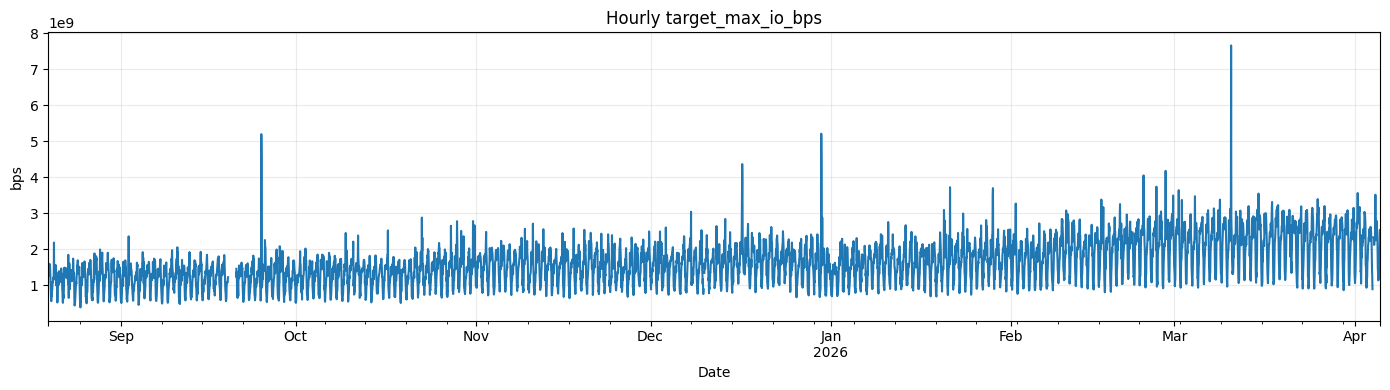

In [7]:
# helper time columns

hourly_target["hour"] = hourly_target.index.hour
hourly_target["dow"] = hourly_target.index.dayofweek   # Monday=0
hourly_target["date"] = hourly_target.index.date

# full hourly line plot

fig, ax = plt.subplots(figsize=(14, 4))
hourly_target["target_max_io_bps"].plot(ax=ax)
ax.set_title("Hourly target_max_io_bps")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The hourly traffic target shows a clear repeating within-day pattern, with visible daily cycles throughout the entire observation period. At the same time, the overall level gradually increases from late summer into March, suggesting a rising baseline load over time. The series also contains occasional sharp spikes, which indicates that peak behavior is not fully explained by smooth seasonality alone.

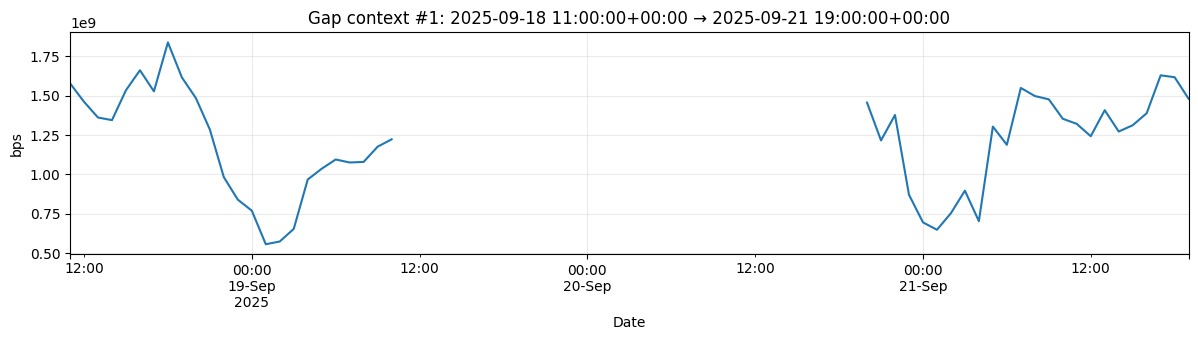

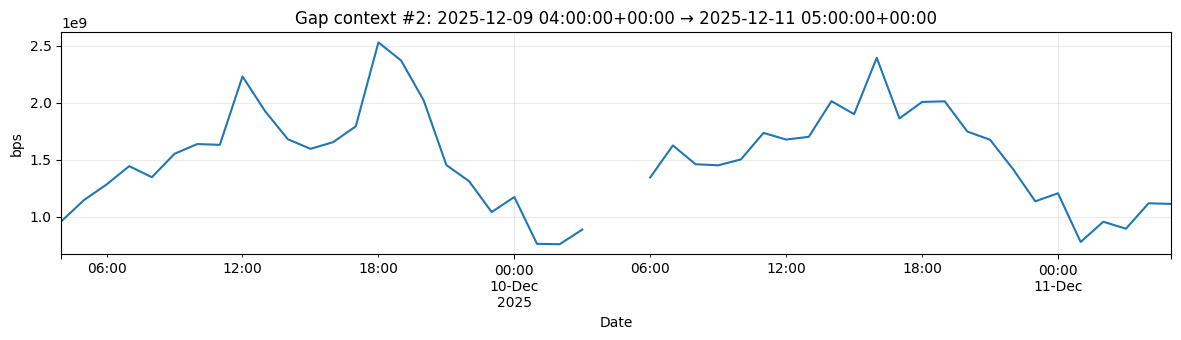

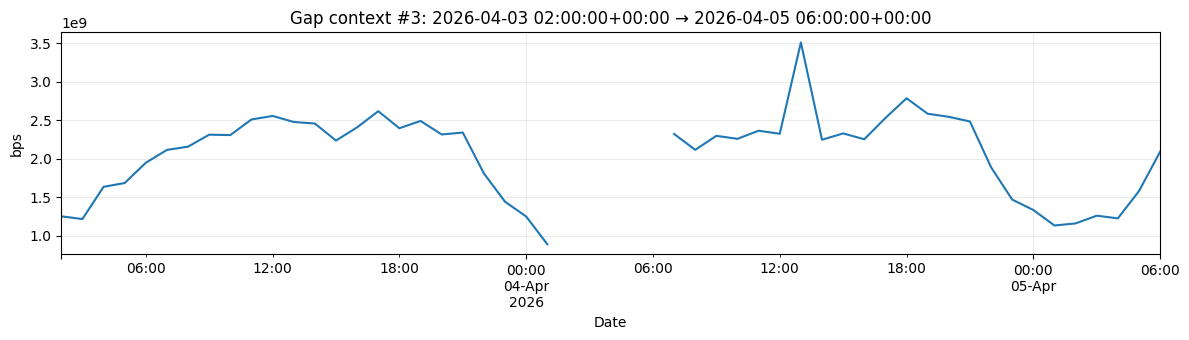

In [8]:
# zoom around missing periods

missing_mask = hourly_target["target_max_io_bps"].isna()
gap_groups = (missing_mask != missing_mask.shift()).cumsum()[missing_mask]

gap_windows = []
for gid, group in hourly_target[missing_mask].groupby(gap_groups):
    start = group.index[0] - pd.Timedelta(hours=24)
    end = group.index[-1] + pd.Timedelta(hours=24)
    gap_windows.append((start, end))

for i, (start, end) in enumerate(gap_windows, 1):
    fig, ax = plt.subplots(figsize=(12, 3.5))
    hourly_target.loc[start:end, "target_max_io_bps"].plot(ax=ax)
    ax.set_title(f"Gap context #{i}: {start} → {end}")
    ax.set_xlabel("Date")
    ax.set_ylabel("bps")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

The missing periods occur within a series that otherwise shows strong recurring hourly structure. However, the largest gap spans 33 consecutive hours, crossing parts of two different daily cycles. While the surrounding values still follow the general daily pattern, this gap is long enough that filling it mechanically could distort any later upper-tail daily aggregate. By contrast, the shorter gaps appear much less problematic and may be safer candidates for limited interpolation if needed.

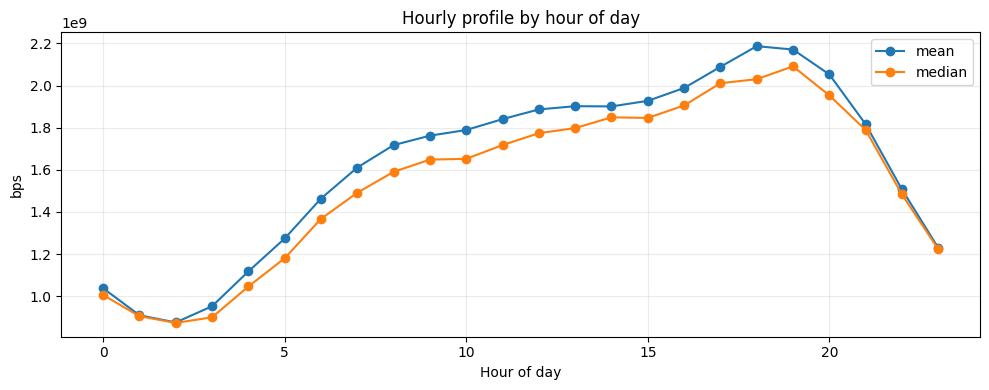

In [9]:
# intraday pattern: median and mean by hour

hour_profile = hourly_target.groupby("hour")["target_max_io_bps"].agg(["mean", "median"])

fig, ax = plt.subplots(figsize=(10, 4))
hour_profile["mean"].plot(ax=ax, marker="o", label="mean")
hour_profile["median"].plot(ax=ax, marker="o", label="median")
ax.set_title("Hourly profile by hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

The hourly profile shows a strong and stable within-day pattern. Traffic is lowest during the night and early morning, then rises steadily through the day and reaches its highest levels in the late afternoon and evening. This suggests strong daily seasonality and makes same-hour comparisons potentially meaningful when reasoning about short gaps.

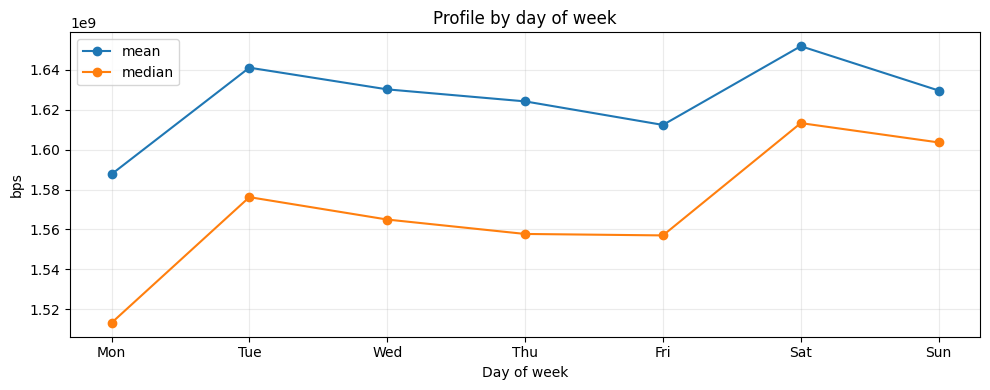

In [10]:
# weekday pattern: median and mean by day of week

dow_profile = hourly_target.groupby("dow")["target_max_io_bps"].agg(["mean", "median"])
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dow_labels, dow_profile["mean"], marker="o", label="mean")
ax.plot(dow_labels, dow_profile["median"], marker="o", label="median")
ax.set_title("Profile by day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

The day-of-week profile suggests that weekday effects exist, but they are weaker than the intraday cycle. The average level is slightly higher on some days than others, with weekends not dramatically lower than weekdays. This means weekly seasonality is present, but hour-of-day effects appear to be the dominant repeating structure.

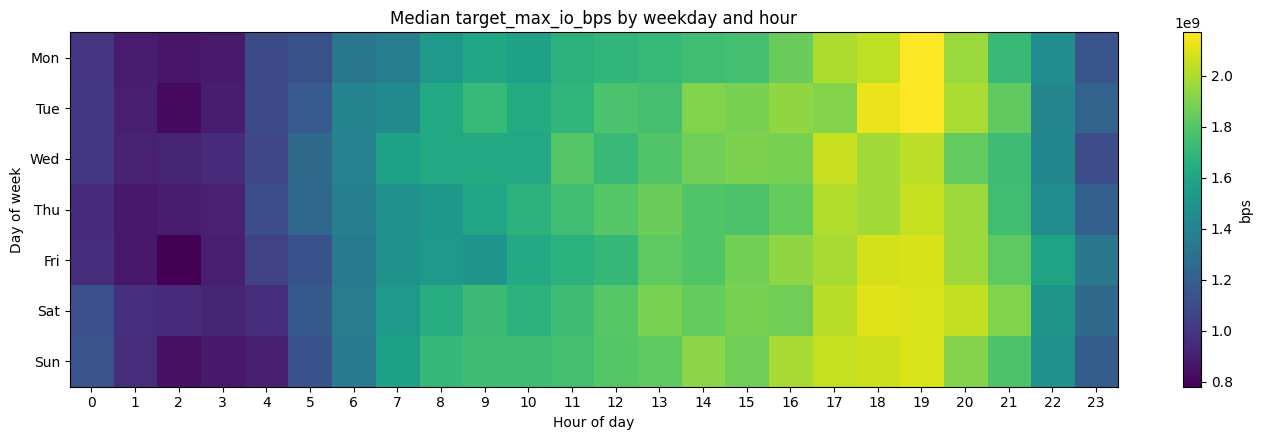

In [11]:
# weekday x hour heatmap

heat = hourly_target.pivot_table(
    index="dow",
    columns="hour",
    values="target_max_io_bps",
    aggfunc="median"
)

fig, ax = plt.subplots(figsize=(14, 4.5))
im = ax.imshow(heat.values, aspect="auto")
ax.set_title("Median target_max_io_bps by weekday and hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_yticks(range(7))
ax.set_yticklabels(dow_labels)
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("bps")
plt.tight_layout()
plt.show()

 The heatmap confirms that the series has a strong hour-of-day structure that repeats across the week. The lowest values are concentrated in the early-night / early-morning hours, while the highest values are concentrated in late afternoon and evening. This supports the idea that the hourly series is structured enough for cautious seasonality-aware reasoning, especially for short missing intervals.

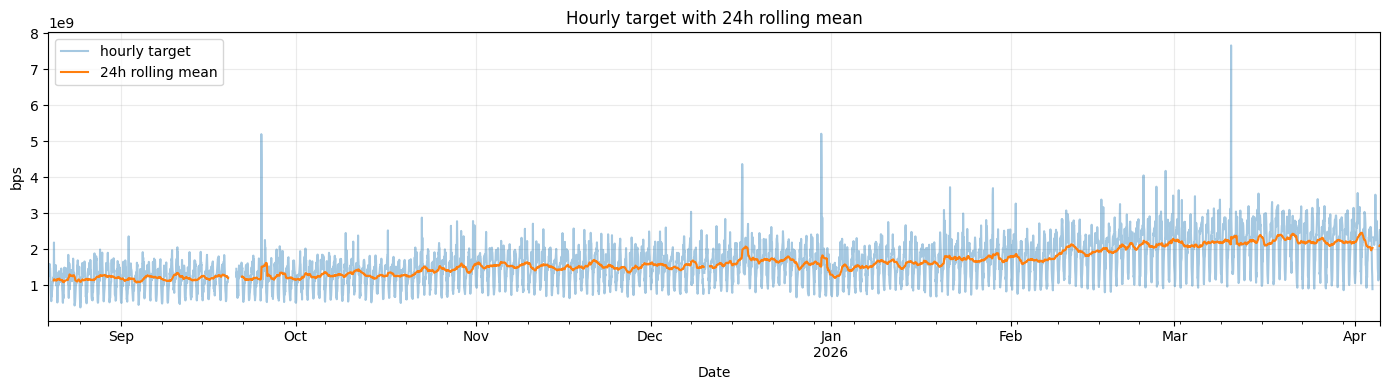

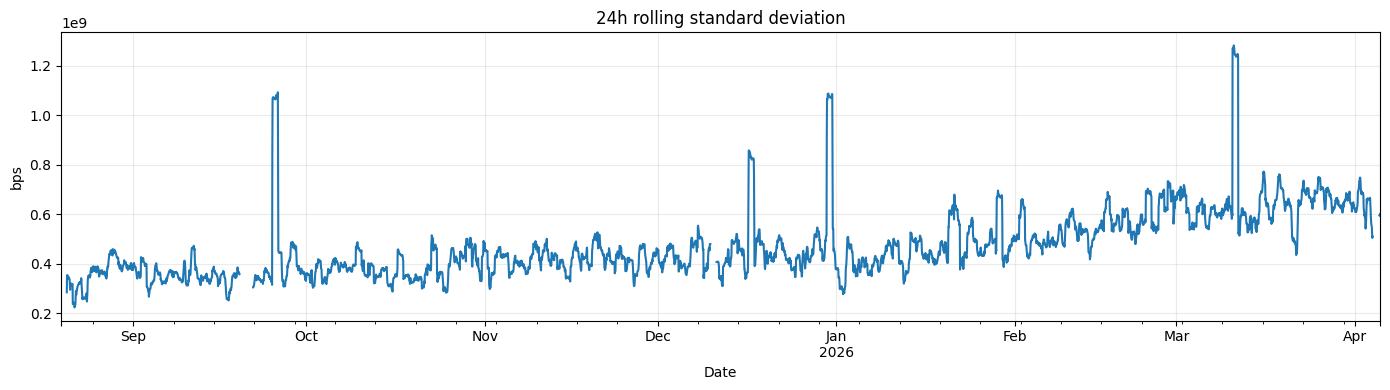

In [12]:
# rolling mean and rolling std

rolling_24h_mean = hourly_target["target_max_io_bps"].rolling(24).mean()
rolling_24h_std = hourly_target["target_max_io_bps"].rolling(24).std()

fig, ax = plt.subplots(figsize=(14, 4))
hourly_target["target_max_io_bps"].plot(ax=ax, alpha=0.4, label="hourly target")
rolling_24h_mean.plot(ax=ax, label="24h rolling mean")
ax.set_title("Hourly target with 24h rolling mean")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
rolling_24h_std.plot(ax=ax)
ax.set_title("24h rolling standard deviation")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The 24-hour rolling mean shows a gradual increase in baseline traffic over time, while the rolling standard deviation also rises, especially in later months. This suggests that the series is not fully stable in level or volatility, and that both average load and dispersion increase as the system grows.

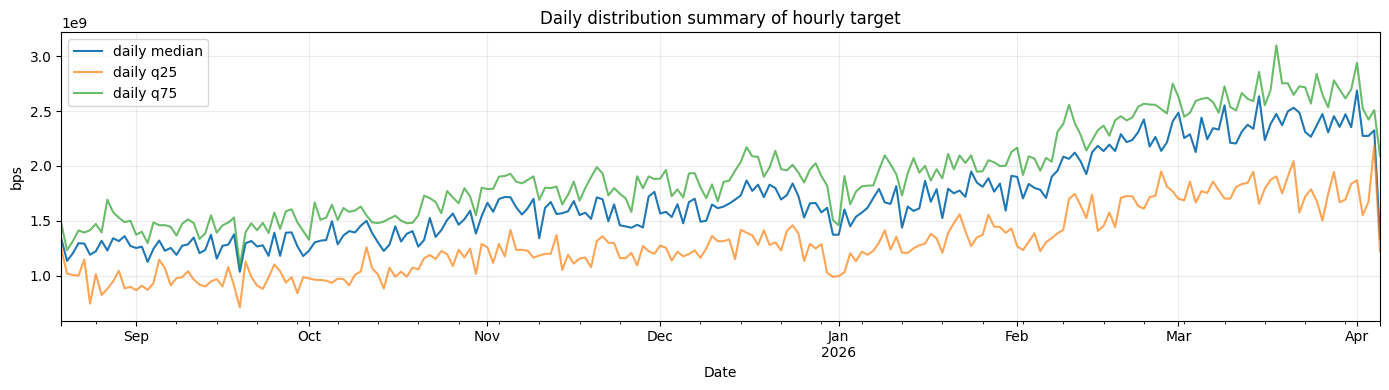

In [13]:
# daily summary via quantiles

daily_quantiles = hourly_target["target_max_io_bps"].resample("D").quantile([0.25, 0.5, 0.75]).unstack()

fig, ax = plt.subplots(figsize=(14, 4))
daily_quantiles[0.5].plot(ax=ax, label="daily median")
daily_quantiles[0.25].plot(ax=ax, label="daily q25", alpha=0.7)
daily_quantiles[0.75].plot(ax=ax, label="daily q75", alpha=0.7)
ax.set_title("Daily distribution summary of hourly target")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

The daily median and interquartile range both trend upward over time, which suggests that the increase in traffic is not driven only by isolated spikes. Instead, both the central level and the upper part of the daily distribution gradually rise, especially toward the end of the observation period.

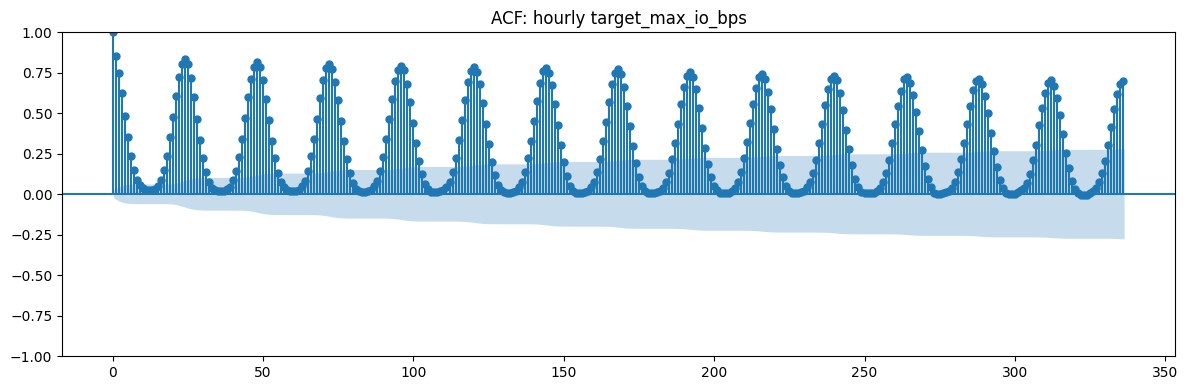

In [14]:
# ACF on hourly target

series_acf = hourly_target["target_max_io_bps"].dropna() # drop missing values for plotting

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(series_acf, lags=24*14, ax=ax)   # 14 days of hourly lags
ax.set_title("ACF: hourly target_max_io_bps")
plt.tight_layout()
plt.show()

The ACF shows very strong short-lag dependence together with clear repeating peaks at approximately 24-hour intervals. This is strong evidence of both persistence and daily seasonality. The repeated wave-like structure over many lags suggests that the hourly series is highly structured rather than noise-like.

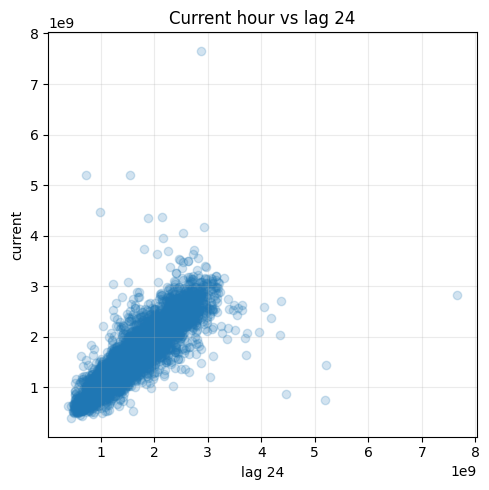

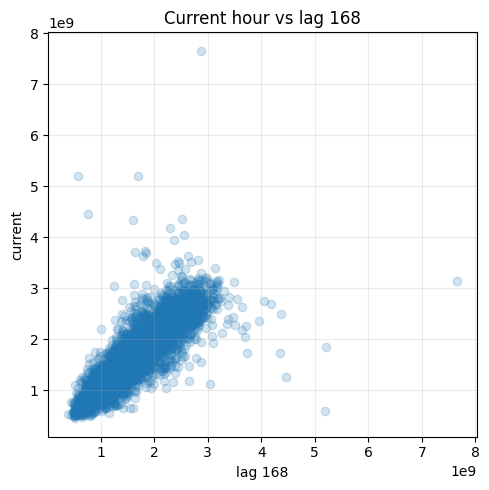

In [15]:
# Lag-24 and lag-168 scatter
tmp = hourly_target[["target_max_io_bps"]].copy()

tmp["lag_24"] = tmp["target_max_io_bps"].shift(24)
tmp["lag_168"] = tmp["target_max_io_bps"].shift(168)

tmp24 = tmp.dropna(subset=["target_max_io_bps", "lag_24"])
tmp168 = tmp.dropna(subset=["target_max_io_bps", "lag_168"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(tmp24["lag_24"], tmp24["target_max_io_bps"], alpha=0.2)
ax.set_title("Current hour vs lag 24")
ax.set_xlabel("lag 24")
ax.set_ylabel("current")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(tmp168["lag_168"], tmp168["target_max_io_bps"], alpha=0.2)
ax.set_title("Current hour vs lag 168")
ax.set_xlabel("lag 168")
ax.set_ylabel("current")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

 The scatter plots for lag 24 and lag 168 show clear positive relationships, meaning the current hour tends to resemble both the same hour on the previous day and the same hour one week earlier. This supports the presence of both daily and weekly repetition, although a number of outliers indicate that extreme spikes are not perfectly seasonal.

### Summary: hourly series structure

The hourly `target_max_io_bps` series shows clear and stable seasonal patterns:

- **Intraday cycle (m = 24):** traffic is consistently low at night (00:00–08:00 UTC),
  rises through the morning, and peaks in the late afternoon and evening
  (approx. 15:00–21:00 UTC). This pattern repeats reliably across all days in the dataset.

- **Weekly cycle (m = 7):** weekday-level differences exist but are moderate.
  Weekdays tend to run slightly higher than weekends, though the contrast is
  less pronounced than the within-day effect.

- **No visible long-term trend:** the level appears broadly stable over the
  observation window, with no systematic upward or downward drift visible in
  the raw series.

- **Incident signature:** a visible gap around 2025-09-19 corresponds to the
  33-hour network outage identified in data preparation.

**Implication for gap filling:** the intraday cycle is strong and consistent,
which means short gaps (2–5 hours) can be reasonably imputed using the
same-hour value from adjacent days. The 33-hour gap spans nearly 1.5 days and
crosses multiple intraday phases, making same-hour imputation unreliable —
the impact on the daily p95 target will be evaluated separately before
choosing an imputation strategy.

### Sensitivity check for missing-data handling

To make desidion if interpolation is either acceptable or unacceptable I run a small sensitivity check to compare several plausible strategies:

- **No fill**: leave gaps as missing and drop affected daily targets if needed
- **Limited interpolation for short gaps**
- **Seasonality-aware fill for longer gaps**

The purpose of this exercise is to understand whether the final daily target is materially sensitive to the way missing hourly values are handled.  
If differences remain small, then a simple and transparent rule may be sufficient.  
If differences are large, then the missing-data policy itself becomes an important modeling decision and should be treated conservatively.

   gid                     start                       end  length_h
0    2 2025-09-19 11:00:00+00:00 2025-09-20 19:00:00+00:00        33
1    4 2025-12-10 04:00:00+00:00 2025-12-10 05:00:00+00:00         2
2    6 2026-04-04 02:00:00+00:00 2026-04-04 06:00:00+00:00         5

Affected-day comparison:
                            p95_no_fill  hours_observed  p95_short_fill  \
2025-09-19 00:00:00+00:00  1.199278e+09              11    1.199278e+09   
2025-09-20 00:00:00+00:00  1.444044e+09               4    1.444044e+09   
2025-12-10 00:00:00+00:00  2.011831e+09              22    2.011701e+09   
2026-04-04 00:00:00+00:00  2.860315e+09              19    2.757580e+09   

                           p95_seasonal_fill  
2025-09-19 00:00:00+00:00       2.066941e+09  
2025-09-20 00:00:00+00:00       2.081642e+09  
2025-12-10 00:00:00+00:00       2.011701e+09  
2026-04-04 00:00:00+00:00       2.757580e+09  

Overall summary:
Reference median daily p95: 2.160 Gbps
Max delta (seasonal):  40.1% o

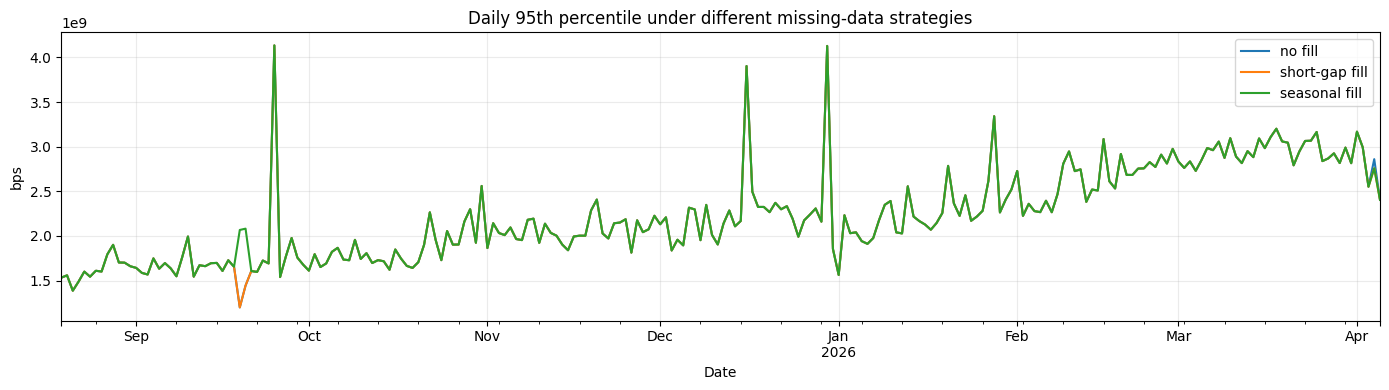

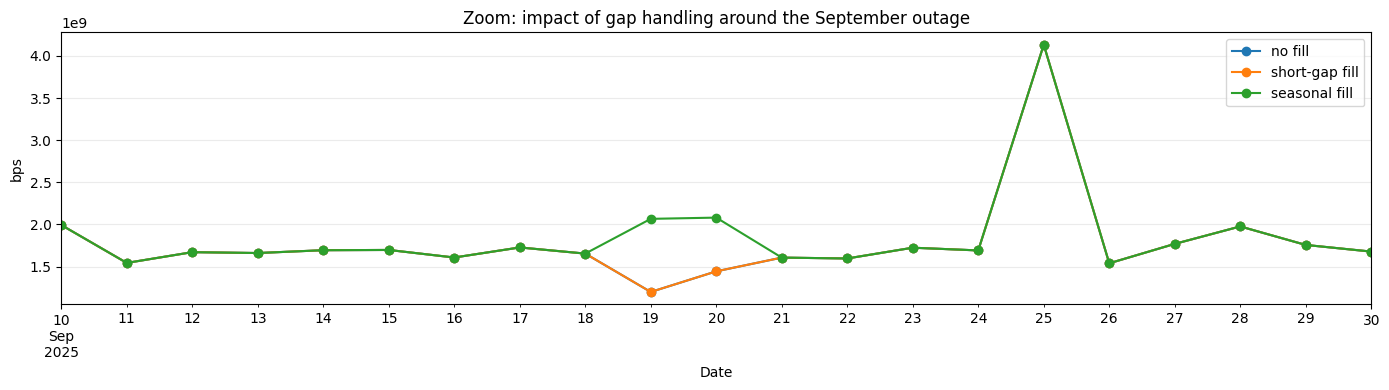

In [16]:
s = hourly_target["target_max_io_bps"].copy()

# helper full index
s = s.asfreq("h")


# 1) Identify gap runs
missing_mask = s.isna()
gap_groups = (missing_mask != missing_mask.shift()).cumsum()[missing_mask]

gap_info = []
for gid, group in s[missing_mask].groupby(gap_groups):
    gap_info.append({
        "gid": gid,
        "start": group.index[0],
        "end": group.index[-1],
        "length_h": len(group)
    })

gap_df = pd.DataFrame(gap_info)
print(gap_df)


# 2) Scenario A: no fill
s_no_fill = s.copy()


# 3) Scenario B: interpolate only very short gaps (<= 5h)
s_short_fill = s.copy()

for row in gap_info:
    if row["length_h"] <= 5:
        # fill only this short gap using time interpolation locally
        gap_idx = pd.date_range(row["start"], row["end"], freq="h", tz=s.index.tz)
        # we interpolate on the whole series but only accept values on short gaps
        interp_series = s_short_fill.interpolate(method="time")
        s_short_fill.loc[gap_idx] = interp_series.loc[gap_idx]


# 4) Scenario C: seasonal fill using same weekday + same hour median
s_seasonal_fill = s.copy()

tmp = pd.DataFrame({"y": s_seasonal_fill})
tmp["dow"] = tmp.index.dayofweek
tmp["hour"] = tmp.index.hour

seasonal_lookup = tmp.groupby(["dow", "hour"])["y"].median()

for ts in s_seasonal_fill[s_seasonal_fill.isna()].index:
    key = (ts.dayofweek, ts.hour)
    s_seasonal_fill.loc[ts] = seasonal_lookup.loc[key]


# 5) Build daily p95 under each scenario
def daily_p95(series: pd.Series) -> pd.DataFrame:
    out = pd.DataFrame({
        "daily_p95": series.resample("D").quantile(0.95),
        "hours_observed": series.resample("D").count()
    })
    return out

daily_no_fill = daily_p95(s_no_fill).rename(columns={"daily_p95": "p95_no_fill"})
daily_short = daily_p95(s_short_fill).rename(columns={"daily_p95": "p95_short_fill"})
daily_seasonal = daily_p95(s_seasonal_fill).rename(columns={"daily_p95": "p95_seasonal_fill"})

daily_compare = daily_no_fill.join(
    daily_short[["p95_short_fill"]], how="outer"
).join(
    daily_seasonal[["p95_seasonal_fill"]], how="outer"
)

# keep hours_observed from no-fill baseline
daily_compare["hours_observed"] = daily_no_fill["hours_observed"]


# 6) Inspect affected days
affected_days = pd.to_datetime([
    "2025-09-19", "2025-09-20",
    "2025-12-10",
    "2026-04-04"
], utc=True)

print("\nAffected-day comparison:")
print(daily_compare.loc[affected_days])


# 7) Summary of differences
daily_compare["diff_short_vs_no"] = daily_compare["p95_short_fill"] - daily_compare["p95_no_fill"]
daily_compare["diff_seasonal_vs_no"] = daily_compare["p95_seasonal_fill"] - daily_compare["p95_no_fill"]

print("\nOverall summary:")
# Reference level sp delta make sence
median_p95 = daily_compare["p95_no_fill"].median()
print(f"Reference median daily p95: {median_p95/1e9:.3f} Gbps")
print(f"Max delta (seasonal):  {867e6/median_p95*100:.1f}% of median p95")
print(f"Max delta (short fill): {102e6/median_p95*100:.1f}% of median p95")
print(daily_compare[["diff_short_vs_no", "diff_seasonal_vs_no"]].describe())


# 8) Plot comparison around affected period
fig, ax = plt.subplots(figsize=(14, 4))
daily_compare["p95_no_fill"].plot(ax=ax, label="no fill")
daily_compare["p95_short_fill"].plot(ax=ax, label="short-gap fill")
daily_compare["p95_seasonal_fill"].plot(ax=ax, label="seasonal fill")
ax.set_title("Daily 95th percentile under different missing-data strategies")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


# 9) Zoom near the long gap
zoom = daily_compare.loc["2025-09-10":"2025-09-30"]

fig, ax = plt.subplots(figsize=(14, 4))
zoom["p95_no_fill"].plot(ax=ax, marker="o", label="no fill")
zoom["p95_short_fill"].plot(ax=ax, marker="o", label="short-gap fill")
zoom["p95_seasonal_fill"].plot(ax=ax, marker="o", label="seasonal fill")
ax.set_title("Zoom: impact of gap handling around the September outage")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### Missing-data sensitivity check: conclusion

The sensitivity check shows that missing-data handling does **not** affect all gaps equally.

For the short gaps (<=d 5 hours), interpolation changes the downstream daily 95th percentile only minimally. In this dataset, the resulting differences are either negligible or small relative to the overall scale of the daily series.

By contrast, applying a seasonality-aware fill to the 33-hour outage block produces a much larger change in the affected daily targets. For the two impacted days, the resulting daily 95th percentile shifts by a substantial amount, with the maximum change reaching about **40% of the median daily p95 level**.

This indicates that the long outage period is too influential to repair mechanically without making the final daily target strongly dependent on the chosen fill rule. Therefore, I adopt a selective missing-data policy:

- **short gaps may be interpolated conservatively**,  
- but the **33-hour outage will not be imputed**,  
- and days materially affected by that outage will be excluded from the final daily modeling series.

This keeps the final forecasting target more transparent and less sensitive to arbitrary reconstruction of missing upper-tail behavior.

After, hourly series will be resampled into the final daily modeling target.  
This creates a second and separate missing-data problem: the outage still leaves a small number of missing **daily** observations in the resampled series.

That daily-level issue is handled separately. At that stage, the target is already a smoother daily aggregate series, so restoring continuity for classical daily forecasting models is a different and less risky decision than reconstructing the missing hourly block itself.

### Construct the daily modeling target

Based on the hourly sensitivity check, I adopt a selective missing-data policy.

- **Short hourly gaps** are interpolated conservatively, since their impact on the downstream daily 95th percentile is negligible or small.
- The **33-hour outage block** is **not** filled at the hourly level, because doing so materially changes the resulting daily upper-tail target and makes it too dependent on the chosen fill rule.

After applying this hourly-level policy, I resample the cleaned hourly signal into the final modeling target:

**Daily 95th percentile of hourly `target_max_io_bps`**

This creates a new daily time series that will be used for the later forecasting workflow.  
At that point, any remaining missing daily observations are treated as a separate issue at the **daily** level rather than the **hourly** level.

In [17]:
# start from hourly target
hourly_target = df[["target_max_io_bps"]].copy().sort_index()
hourly_target = hourly_target.asfreq("h")

s = hourly_target["target_max_io_bps"].copy()

# identify missing runs
missing_mask = s.isna()
gap_groups = (missing_mask != missing_mask.shift()).cumsum()[missing_mask]

gap_info = []
for gid, group in s[missing_mask].groupby(gap_groups):
    gap_info.append({
        "gid": gid,
        "start": group.index[0],
        "end": group.index[-1],
        "length_h": len(group)
    })

gap_df = pd.DataFrame(gap_info)
print("Gap runs:")
print(gap_df)


# fill only short gaps <= 5h, leave the 33h outage untouched
s_clean = s.copy()

# time interpolation candidate
interp_series = s_clean.interpolate(method="time")

for row in gap_info:
    if row["length_h"] <= 5:
        gap_idx = pd.date_range(row["start"], row["end"], freq="h", tz=s.index.tz)
        s_clean.loc[gap_idx] = interp_series.loc[gap_idx]

# check what remains missing after short-gap fill
print("\nRemaining missing hourly values after short-gap fill:", s_clean.isna().sum())

remaining_missing_mask = s_clean.isna()
remaining_gap_groups = (remaining_missing_mask != remaining_missing_mask.shift()).cumsum()[remaining_missing_mask]

remaining_gap_info = []
for gid, group in s_clean[remaining_missing_mask].groupby(remaining_gap_groups):
    remaining_gap_info.append({
        "gid": gid,
        "start": group.index[0],
        "end": group.index[-1],
        "length_h": len(group)
    })

print("\nRemaining gap runs:")
print(pd.DataFrame(remaining_gap_info))

Gap runs:
   gid                     start                       end  length_h
0    2 2025-09-19 11:00:00+00:00 2025-09-20 19:00:00+00:00        33
1    4 2025-12-10 04:00:00+00:00 2025-12-10 05:00:00+00:00         2
2    6 2026-04-04 02:00:00+00:00 2026-04-04 06:00:00+00:00         5

Remaining missing hourly values after short-gap fill: 33

Remaining gap runs:
   gid                     start                       end  length_h
0    2 2025-09-19 11:00:00+00:00 2025-09-20 19:00:00+00:00        33


### EDA Stage 2:

I resample the cleaned hourly signal into the final target:

**Daily 95th percentile of hourly `target_max_io_bps`**

At this stage, I also remove the **first and last calendar days** from the series, because they are only partially observed due to the boundaries of the original hourly dataset. These are not substantive internal gaps in the monitoring process, but simple edge effects from the start and end of the observation window.

This leaves a daily time series with:
- a clearly defined target,
- a regular daily cadence,
- and two remaining internal missing dates caused by the known 33-hour outage period.

The purpose of this second-stage EDA is to understand the structure of the **daily** series itself:
- trend,
- seasonality,
- volatility changes,
- level shifts,
- and the general smoothness or stability of the resampled target.

Only after examining this daily series will I decide how to handle the remaining two internal daily gaps for classical forecasting models such as ARIMA or SARIMA.  
This is a separate and less risky problem than reconstructing the original missing hourly block, because at this stage I am working with a smoother aggregated daily series rather than raw hourly traffic values.

For STL, ACF, and PACF, I use `y_stl = y_daily.interpolate(method="time")` but only for visualization and diagnostics, because many of these procedures don't like internal NaNs so its not desidion but technical step to understand the structure of the daily series.

In [18]:
# build the daily modeling target

daily_target = pd.DataFrame({
    "y_raw": s_clean.resample("D").quantile(0.95),
    "hours_observed": s_clean.resample("D").count()
})

daily_target["is_complete_day"] = daily_target["hours_observed"].eq(24)
daily_target["y"] = daily_target["y_raw"].where(daily_target["is_complete_day"])

# removing the edges of the timeline as it's not fully days
daily_target = daily_target.iloc[1:-1].copy()

print("\nDaily target head:")
print(daily_target.head())

print("\nDaily target tail:")
print(daily_target.tail())

print("\nDays with incomplete daily coverage:")
print(daily_target[daily_target["hours_observed"] < 24])


Daily target head:
                                  y_raw  hours_observed  is_complete_day  \
timestamp_utc                                                              
2025-08-20 00:00:00+00:00  1.558720e+09              24             True   
2025-08-21 00:00:00+00:00  1.386662e+09              24             True   
2025-08-22 00:00:00+00:00  1.488215e+09              24             True   
2025-08-23 00:00:00+00:00  1.600419e+09              24             True   
2025-08-24 00:00:00+00:00  1.543510e+09              24             True   

                                      y  
timestamp_utc                            
2025-08-20 00:00:00+00:00  1.558720e+09  
2025-08-21 00:00:00+00:00  1.386662e+09  
2025-08-22 00:00:00+00:00  1.488215e+09  
2025-08-23 00:00:00+00:00  1.600419e+09  
2025-08-24 00:00:00+00:00  1.543510e+09  

Daily target tail:
                                  y_raw  hours_observed  is_complete_day  \
timestamp_utc                                            

Daily target length: 228
Missing daily values: 2
Date range: 2025-08-20 00:00:00+00:00 -> 2026-04-04 00:00:00+00:00


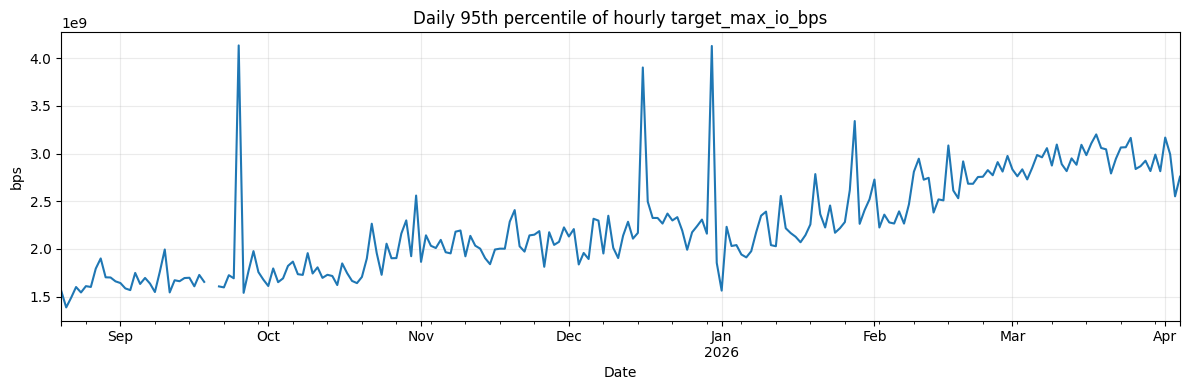

In [19]:
# daily modeling series for EDA

y_daily = daily_target["y"].copy()

print("Daily target length:", len(y_daily))
print("Missing daily values:", y_daily.isna().sum())
print("Date range:", y_daily.index.min(), "->", y_daily.index.max())

# level plot

fig, ax = plt.subplots(figsize=(12, 4))
y_daily.plot(ax=ax)
ax.set_title("Daily 95th percentile of hourly target_max_io_bps")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The daily target shows a **clear upward trend** over the observation window: the typical level in March is noticeably higher than in late August and September. This suggests that network pressure increased over time rather than fluctuating around a stable constant mean.

The series contains several **large isolated spikes**, especially around late September, mid-December, and late December / early January. These spikes are much larger than the surrounding daily values and likely reflect short-lived high-load events rather than the baseline behavior of the system.

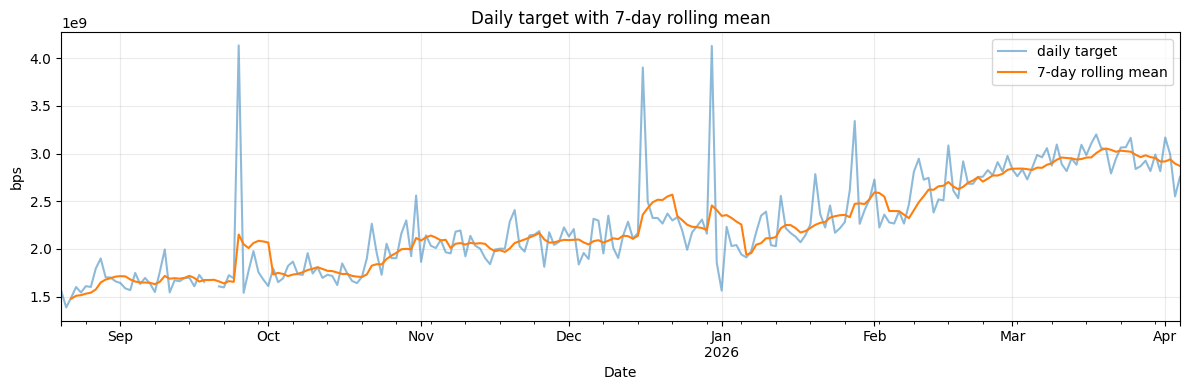

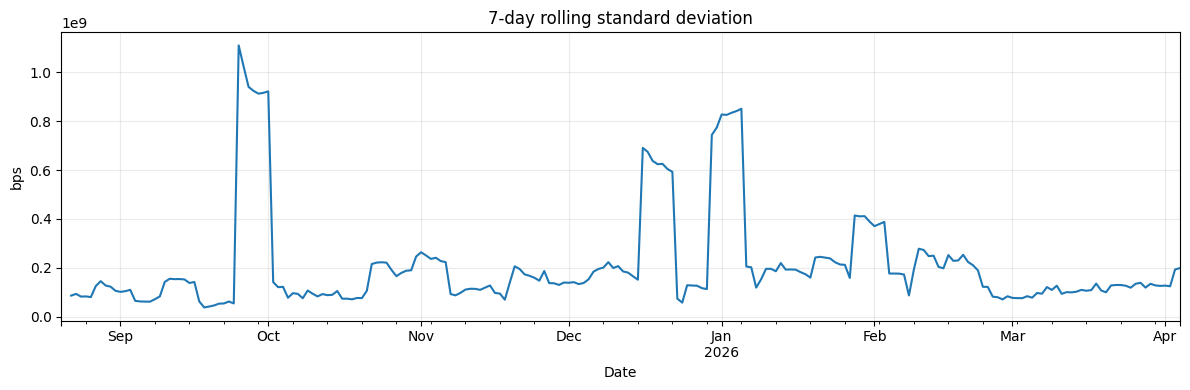

In [20]:
# rolling mean and rolling std

rolling_7_mean = y_daily.rolling(7, min_periods=3).mean()
rolling_7_std = y_daily.rolling(7, min_periods=3).std()

fig, ax = plt.subplots(figsize=(12, 4))
y_daily.plot(ax=ax, alpha=0.5, label="daily target")
rolling_7_mean.plot(ax=ax, label="7-day rolling mean")
ax.set_title("Daily target with 7-day rolling mean")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
rolling_7_std.plot(ax=ax)
ax.set_title("7-day rolling standard deviation")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The **7-day rolling mean** rises gradually over time, confirming that the increase is not driven only by rare outliers. The underlying baseline level also moves upward, especially from February onward.

The **7-day rolling standard deviation** is not constant. Volatility becomes much larger around spike periods and appears somewhat higher in later months, which suggests that the series is not perfectly homoskedastic.


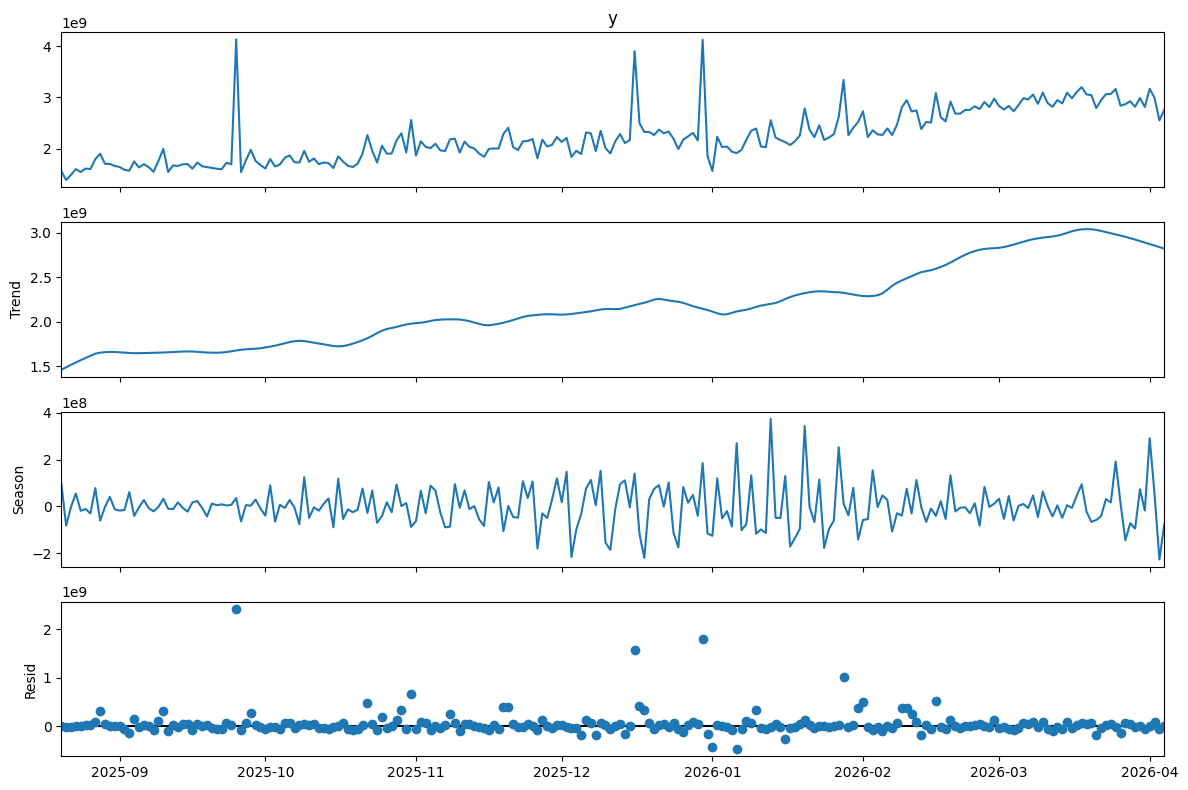

In [21]:
# STL decomposition
# for STL we need a temporary filled series, fill only for visualization purposes

y_stl = y_daily.interpolate(method="time")

stl = STL(y_stl, period=7, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

The STL decomposition suggests that the dominant feature of the series is the **trend**, while the seasonal component appears weaker and less stable than the trend. The residual component still contains several large shocks, so not all variation is explained by smooth trend and seasonality.

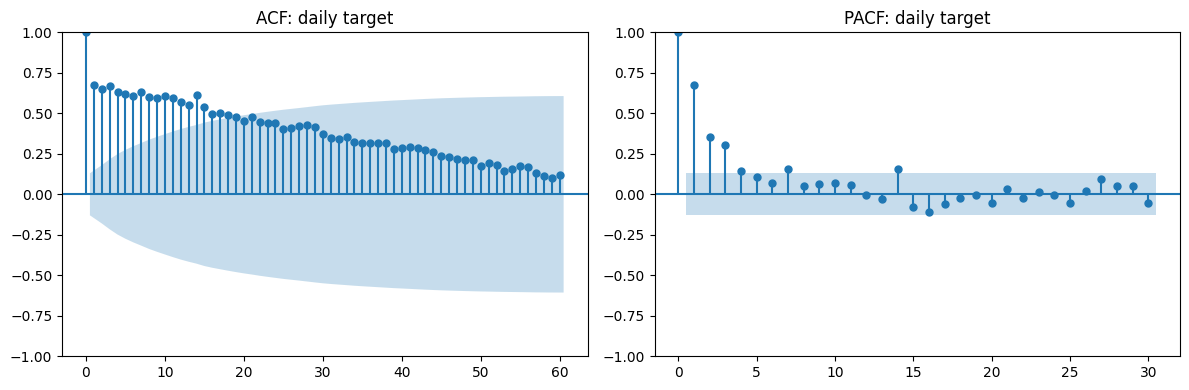

In [22]:
# ACF / PACF - use the temporarily filled daily series for diagnostics

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y_stl, lags=60, ax=axes[0])
axes[0].set_title("ACF: daily target")

plot_pacf(y_stl, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF: daily target")

plt.tight_layout()
plt.show()

The ACF decays slowly and remains positive across many lags, indicating strong persistence and suggesting that the daily series is not stationary in its current form.
The ACF does not show pronounced spikes at lags 7, 14, or 21, so weekly seasonality in the daily p95 series appears weaker and less explicit than in the raw hourly data. This is plausible because daily p95 aggregation compresses within-day variation, while the upward trend and several large shock-like days dominate the autocorrelation structure. Nevertheless, a weekly seasonal period (m = 7) is retained as a candidate in SARIMA based on domain knowledge and the weekly structure observed earlier in the hourly EDA.
  
The PACF shows strong short-lag dependence, especially at the first few lags, which is consistent with autoregressive structure in the daily series.

**Interpretation:**
- Is there a long-run trend? Up/down/flat?

the daily target shows a clear upward long-run trend over the observation window. The typical level in February-March is materially higher than in late August-September, and the 7-day rolling mean also rises over time. The increase appears gradual rather than abrupt, with stronger growth in the later part of the sample.
- Seasonality presents? Annual? Weekly? Other periodicity?
  
There is no evidence of annual seasonality, since the sample does not cover a full year.
At the daily level, weekly seasonality is not strongly expressed visually: the ACF does not show sharp peaks at multiples of 7, and STL suggests that trend is more dominant than seasonality. However, a weekly pattern remains plausible based on domain knowledge and the hourly EDA, so a weekly seasonal period (m = 7) is still considered in SARIMA as a modeling candidate rather than a confirmed feature.
- Any structural breaks or anomalies to explain?
  
The series contains several large isolated anomalies, especially around late September, mid-December, and late December/early January, where daily p95 rises far above the local baseline. These are more consistent with short-lived high-load events than with ordinary day-to-day variation.
There is also a gradual upward level shift over time, especially into February-March, but from visual inspection this looks more like a trend acceleration than a clear discrete structural break. A formal break test would be needed before claiming a true regime change.
- Does variance grow with the level (log transform useful)?
  
There is some indication that variability increases with the level: later parts of the series have a higher baseline and somewhat larger absolute fluctuations, and rolling volatility rises around high-level periods and spike episodes. However, the pattern is also influenced by a few extreme days, so the evidence is not purely multiplicative. A log transform may still be useful because it can stabilize scale differences and reduce the influence of large spikes, but this should be checked empirically in model diagnostics.

### Choosing a daily-gap imputation rule

I need a continuous daily series to fit forecasting models so I need to fill 33 hours gap.
I compare several simple imputation candidates on the daily series itself:

- **linear / time interpolation**
- **local interpolation from neighboring values**
- **weekly seasonal benchmark using nearby values at lag 7**

The goal is to see which rule best reconstructs artificially removed daily observations in parts of the series where the true values are known.

The objective is to identify which rule best reconstructs short missing daily blocks in this series before fitting ARIMA/SARIMA models. This comparison is important because the daily series shows strong persistence and trend, while weekly seasonality appears weaker and less explicit than in the original hourly data. Therefore, both trend-based and seasonality-based imputations are plausible candidates, and the final choice should be made empirically.

In [23]:
s_daily = daily_target["y"].copy()   # daily target with two internal NaNs

print("Length:", len(s_daily))
print("Missing:", s_daily.isna().sum())
print("Range:", s_daily.index.min(), "->", s_daily.index.max())

Length: 228
Missing: 2
Range: 2025-08-20 00:00:00+00:00 -> 2026-04-04 00:00:00+00:00


In [24]:
# helper functions for the 3 imputation methods

def fill_time_interpolation(series: pd.Series) -> pd.Series:
    
    """Fill internal gaps using time interpolation."""
    
    return series.interpolate(method="time")


def fill_local_linear(series: pd.Series, start_idx: int, block_len: int = 2) -> pd.Series:
    
    """Fill a missing block using a local linear trend fitted on
    two points before and two points after the block."""
    
    filled = series.copy()

    # missing block: [start_idx, start_idx+1]
    x_obs = np.array([start_idx - 2, start_idx - 1, start_idx + 2, start_idx + 3], dtype=float)
    y_obs = series.iloc[x_obs.astype(int)].values.astype(float)

    # linear fit
    slope, intercept = np.polyfit(x_obs, y_obs, deg=1)

    x_pred = np.array([start_idx, start_idx + 1], dtype=float)
    y_pred = slope * x_pred + intercept

    filled.iloc[start_idx:start_idx + block_len] = y_pred
    return filled


def fill_seasonal_t7(series: pd.Series, start_idx: int, block_len: int = 2) -> pd.Series:
    
    """Fill each missing date using the same weekday from the previous
    and next week: average of t-7 and t+7."""
    
    filled = series.copy()

    # first missing point at i -> use i-7 and i+7
    i = start_idx
    filled.iloc[i] = np.mean([series.iloc[i - 7], series.iloc[i + 7]])

    # second missing point at i+1 -> use (i+1)-7 and (i+1)+7
    j = start_idx + 1
    filled.iloc[j] = np.mean([series.iloc[j - 7], series.iloc[j + 7]])

    return filled

In [25]:
# find candidate two-day blocks for backtesting
# need enough surrounding observations for all 3 methods

candidate_starts = []

for i in range(7, len(s_daily) - 8):
    required_idx = [
        i, i + 1, # true block
        i - 2, i - 1, # local left support
        i + 2, i + 3, # local right support
        i - 7, i + 7, # seasonal support for first point
        i - 6, i + 8  # seasonal support for second point
    ]

    vals = s_daily.iloc[required_idx]

    # skip blocks touching the real missing dates or any other NaNs
    if vals.notna().all():
        candidate_starts.append(i)

print("Number of candidate 2-day blocks:", len(candidate_starts))

Number of candidate 2-day blocks: 200


In [26]:
# test each candidate block

rows = []

for i in candidate_starts:
    true_block = s_daily.iloc[i:i+2].copy()

    masked = s_daily.copy()
    masked.iloc[i:i+2] = np.nan

    # Method 1: time interpolation
    filled_time = fill_time_interpolation(masked)
    pred_time = filled_time.iloc[i:i+2]

    # Method 2: local linear
    filled_local = fill_local_linear(masked, start_idx=i, block_len=2)
    pred_local = filled_local.iloc[i:i+2]

    # Method 3: seasonal t-7 / t+7
    filled_seasonal = fill_seasonal_t7(masked, start_idx=i, block_len=2)
    pred_seasonal = filled_seasonal.iloc[i:i+2]

    # point-level errors
    mae_time = mean_absolute_error(true_block, pred_time)
    mae_local = mean_absolute_error(true_block, pred_local)
    mae_seasonal = mean_absolute_error(true_block, pred_seasonal)

    rmse_time = np.sqrt(mean_squared_error(true_block, pred_time))
    rmse_local = np.sqrt(mean_squared_error(true_block, pred_local))
    rmse_seasonal = np.sqrt(mean_squared_error(true_block, pred_seasonal))

    # block-level mean preservation
    block_mean_true = true_block.mean()
    block_mean_time = pred_time.mean()
    block_mean_local = pred_local.mean()
    block_mean_seasonal = pred_seasonal.mean()

    rows.append({
        "start_date": s_daily.index[i],
        "end_date": s_daily.index[i + 1],

        "mae_time": mae_time,
        "mae_local": mae_local,
        "mae_seasonal": mae_seasonal,

        "rmse_time": rmse_time,
        "rmse_local": rmse_local,
        "rmse_seasonal": rmse_seasonal,

        "block_mean_abs_err_time": abs(block_mean_time - block_mean_true),
        "block_mean_abs_err_local": abs(block_mean_local - block_mean_true),
        "block_mean_abs_err_seasonal": abs(block_mean_seasonal - block_mean_true),
    })

backtest_df = pd.DataFrame(rows)

print("\nBacktest results (head):")
print(backtest_df.head())


Backtest results (head):
                 start_date                  end_date      mae_time  \
0 2025-08-27 00:00:00+00:00 2025-08-28 00:00:00+00:00  1.951678e+08   
1 2025-08-28 00:00:00+00:00 2025-08-29 00:00:00+00:00  8.334781e+07   
2 2025-08-29 00:00:00+00:00 2025-08-30 00:00:00+00:00  7.871025e+07   
3 2025-08-30 00:00:00+00:00 2025-08-31 00:00:00+00:00  1.014622e+07   
4 2025-08-31 00:00:00+00:00 2025-09-01 00:00:00+00:00  1.010582e+07   

     mae_local  mae_seasonal     rmse_time    rmse_local  rmse_seasonal  \
0  193506928.1   281590915.2  1.985222e+08  1.980262e+08   2.861906e+08   
1  112372680.9   237338585.5  9.939023e+07  1.498346e+08   2.557781e+08   
2   47618121.9    97221065.3  8.787052e+07  5.196034e+07   1.070304e+08   
3   27355157.7    61206483.6  1.294579e+07  2.791799e+07   6.182829e+07   
4   11958567.8    66580532.5  1.283905e+07  1.336003e+07   6.666590e+07   

   block_mean_abs_err_time  block_mean_abs_err_local  \
0              195167841.8              


Average backtest performance:
                       MAE          RMSE  Block mean abs error
local_linear  1.811800e+08  2.038129e+08          1.537613e+08
seasonal_t7   1.891182e+08  2.221824e+08          1.589713e+08
time_interp   1.925813e+08  2.175906e+08          1.694387e+08


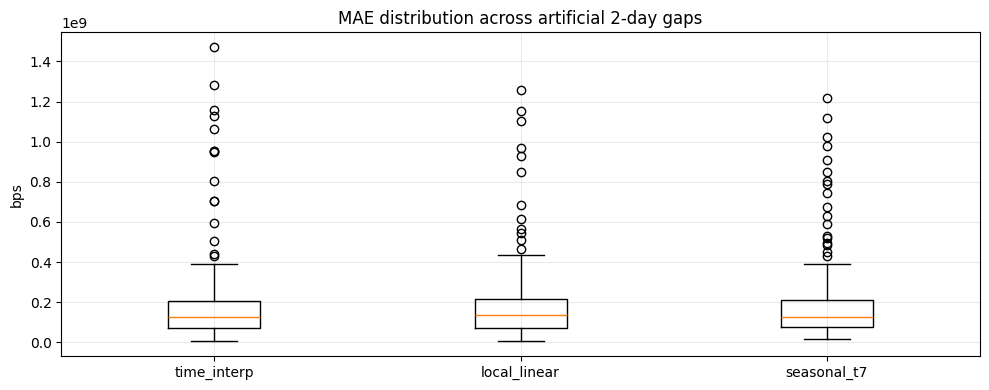

In [27]:
# summary table

summary = pd.DataFrame({
    "MAE": [
        backtest_df["mae_time"].mean(),
        backtest_df["mae_local"].mean(),
        backtest_df["mae_seasonal"].mean(),
    ],
    "RMSE": [
        backtest_df["rmse_time"].mean(),
        backtest_df["rmse_local"].mean(),
        backtest_df["rmse_seasonal"].mean(),
    ],
    "Block mean abs error": [
        backtest_df["block_mean_abs_err_time"].mean(),
        backtest_df["block_mean_abs_err_local"].mean(),
        backtest_df["block_mean_abs_err_seasonal"].mean(),
    ]
}, index=["time_interp", "local_linear", "seasonal_t7"])

print("\nAverage backtest performance:")
print(summary.sort_values("MAE"))

# visualizating distributions of MAE
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(
    [
        backtest_df["mae_time"],
        backtest_df["mae_local"],
        backtest_df["mae_seasonal"]
    ],
    tick_labels=["time_interp", "local_linear", "seasonal_t7"]
)
ax.set_title("MAE distribution across artificial 2-day gaps")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [28]:
# inspect a few hardest cases
backtest_df["best_method"] = backtest_df[["mae_time", "mae_local", "mae_seasonal"]].idxmin(axis=1)
print("\nBest method counts:")
print(backtest_df["best_method"].value_counts())

print("\nWorst cases for time interpolation:")
print(backtest_df.sort_values("mae_time", ascending=False).head(5)[["start_date", "end_date", "mae_time"]])

print("\nWorst cases for local linear:")
print(backtest_df.sort_values("mae_local", ascending=False).head(5)[["start_date", "end_date", "mae_local"]])

print("\nWorst cases for seasonal_t7:")
print(backtest_df.sort_values("mae_seasonal", ascending=False).head(5)[["start_date", "end_date", "mae_seasonal"]])


Best method counts:
best_method
mae_seasonal    81
mae_time        60
mae_local       59
Name: count, dtype: int64

Worst cases for time interpolation:
                   start_date                  end_date      mae_time
113 2025-12-31 00:00:00+00:00 2026-01-01 00:00:00+00:00  1.471436e+09
18  2025-09-24 00:00:00+00:00 2025-09-25 00:00:00+00:00  1.280909e+09
17  2025-09-23 00:00:00+00:00 2025-09-24 00:00:00+00:00  1.156966e+09
112 2025-12-30 00:00:00+00:00 2025-12-31 00:00:00+00:00  1.129749e+09
111 2025-12-29 00:00:00+00:00 2025-12-30 00:00:00+00:00  1.063044e+09

Worst cases for local linear:
                   start_date                  end_date     mae_local
18  2025-09-24 00:00:00+00:00 2025-09-25 00:00:00+00:00  1.255308e+09
111 2025-12-29 00:00:00+00:00 2025-12-30 00:00:00+00:00  1.153115e+09
112 2025-12-30 00:00:00+00:00 2025-12-31 00:00:00+00:00  1.105091e+09
98  2025-12-16 00:00:00+00:00 2025-12-17 00:00:00+00:00  9.680490e+08
113 2025-12-31 00:00:00+00:00 2026-01-01 00:00

### Choosing the daily-gap imputation rule

I compared several plausible daily-level imputation rules on 200 artificial 2-day gaps. Local linear interpolation achieved the lowest average error, while the weekly seasonal rule was more often the best on individual blocks. Because the performance gap between the two methods is modest, the final daily series does not appear highly sensitive to this choice. I therefore use local linear interpolation as the default rule, while noting that a seasonal alternative gives broadly similar results.

In [29]:
# fill the internal 2-day gap using local linear interpolatio

y_daily = daily_target["y"].copy()
y_final = y_daily.copy()

nan_idx = np.where(y_final.isna())[0]
assert len(nan_idx) == 2 and nan_idx[1] == nan_idx[0] + 1, "Expected one 2-day internal gap"

i = nan_idx[0]

# use two points before and two points after the missing block

x_obs = np.array([i - 2, i - 1, i + 2, i + 3], dtype=float)
y_obs = y_final.iloc[x_obs.astype(int)].values.astype(float)

slope, intercept = np.polyfit(x_obs, y_obs, deg=1)

x_pred = np.array([i, i + 1], dtype=float)
y_pred = slope * x_pred + intercept

y_final.iloc[i:i+2] = y_pred

print("\nMissing after fill:", y_final.isna().sum())


# save back into daily_target for traceability

daily_target["y_final"] = y_final


Missing after fill: 0


## <a id="4-stationarity-differencing-diagnostics"></a>4) Stationarity & differencing diagnostics


Before fitting ARIMA/SARIMA models, I need to decide whether the daily series requires:

- **non-seasonal differencing** (`d`),
- **seasonal differencing** (`D`),
- or both.

The daily target in levels already looks non-stationary from the earlier EDA: it has a visible upward trend, strong persistence, and several large shock-like days. In such cases, classical ARIMA-type models usually require differencing to stabilize the mean structure before the autoregressive and moving-average terms can be interpreted more clearly.

I therefore inspect four versions of the series:

- **level** — the original daily target
- **diff(1)** — first non-seasonal difference (is the natural first choice because the daily EDA and the slowly decaying ACF suggest a trend / unit-root-like behavior.)
- **diff(7)** — seasonal difference with weekly period (tested because a weekly seasonal period (`m = 7`) remains a plausible candidate from domain knowledge and from the earlier hourly EDA, even though the daily ACF does not show very pronounced spikes at lags 7, 14, and 21.)
- **diff(1) + diff(7)** — combined non-seasonal and seasonal differencing (tested to see whether both sources of non-stationarity need to be removed simultaneously, or whether that would be unnecessarily strong)


To evaluate these transformations, I use both:

- **ADF** (Augmented Dickey–Fuller), where the null hypothesis is non-stationarity / unit root,
- **KPSS**, where the null hypothesis is stationarity.

This combination is useful because the two tests have opposite null hypotheses and therefore complement each other.

In [30]:
# build transformed series for diagnostics

series_dict = {
    "level": daily_target["y_final"].copy(),
    "diff_1": daily_target["y_final"].diff(1),
    "diff_7": daily_target["y_final"].diff(7),
    "diff_1_then_7": daily_target["y_final"].diff(1).diff(7),
}

In [31]:
# ADF + KPSS

def run_stationarity_tests(series: pd.Series, name: str):
    s = series.dropna()

    # ADF: H0 = non-stationary / unit root
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s, autolag="AIC")

    # KPSS: H0 = stationary
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression="c", nlags="auto")
    except Exception as e:
        kpss_stat, kpss_p, kpss_crit = np.nan, np.nan, {}
        print(f"KPSS failed for {name}: {e}")

    return {
        "series": name,
        "n_obs": len(s),
        "adf_stat": adf_stat,
        "adf_p": adf_p,
        "kpss_stat": kpss_stat,
        "kpss_p": kpss_p,
    }

results = []
for name, s in series_dict.items():
    results.append(run_stationarity_tests(s, name))

stationarity_table = pd.DataFrame(results).set_index("series")
stationarity_table

/var/folders/3l/l5m507c50qqf23wpqd6zxx080000gn/T/ipykernel_12603/275554000.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression="c", nlags="auto")
/var/folders/3l/l5m507c50qqf23wpqd6zxx080000gn/T/ipykernel_12603/275554000.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression="c", nlags="auto")
/var/folders/3l/l5m507c50qqf23wpqd6zxx080000gn/T/ipykernel_12603/275554000.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression="c", nlags="auto")
/var/folders/3l/l5m507c50qqf23w

,n_obs,adf_stat,adf_p,kpss_stat,kpss_p
series,,,,,
level,228,-0.505162,8.910051e-01,2.169344,0.01
diff_1,227,-7.691475,1.415478e-11,0.069091,0.10
diff_7,221,-5.002080,2.198371e-05,0.022550,0.10
diff_1_then_7,220,-6.643924,5.324214e-09,0.045153,0.10


The level series is clearly non-stationary: ADF fails to reject a unit root, while KPSS rejects stationarity.  
After first differencing, the series looks much more stable, and both ADF and KPSS support stationarity. Seasonal differencing at lag 7 also produces a stationary series, but the daily ACF does not show especially strong weekly seasonal spikes in levels.

Therefore, the most defensible starting choice is to use **non-seasonal differencing (`d = 1`)** as the baseline transformation, while treating **weekly seasonality (`m = 7`)** as a candidate for SARIMA rather than assuming that **seasonal differencing (`D = 1`)** is necessary by default.

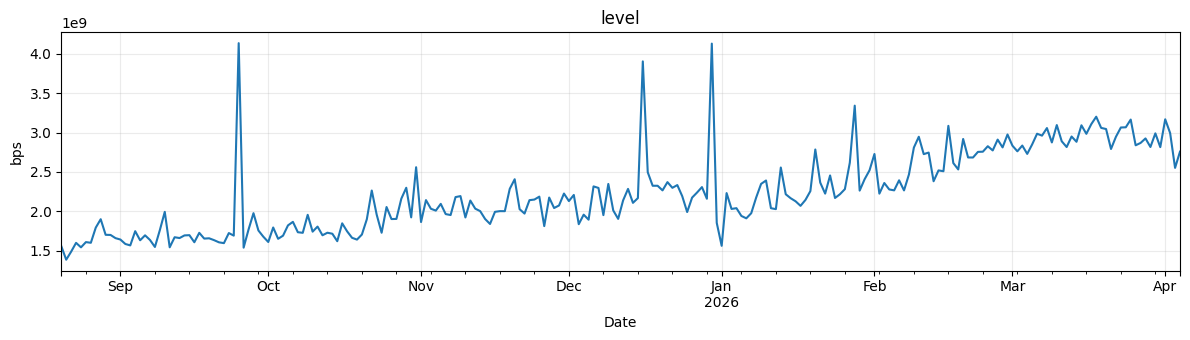

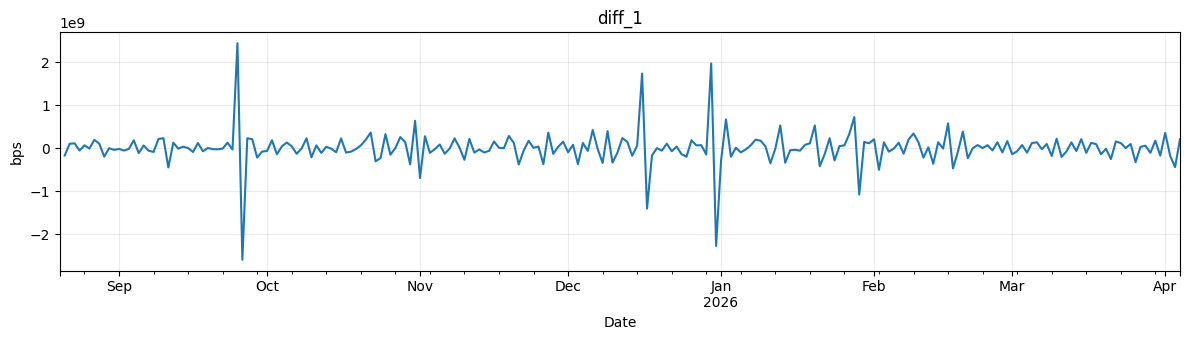

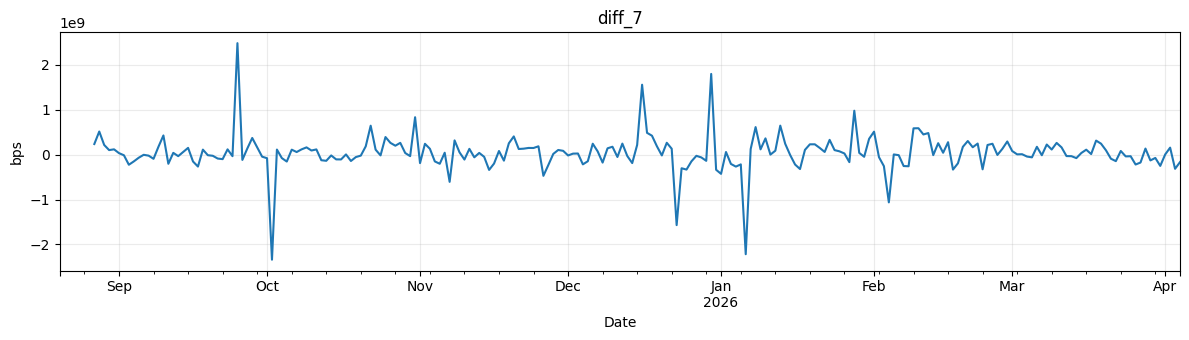

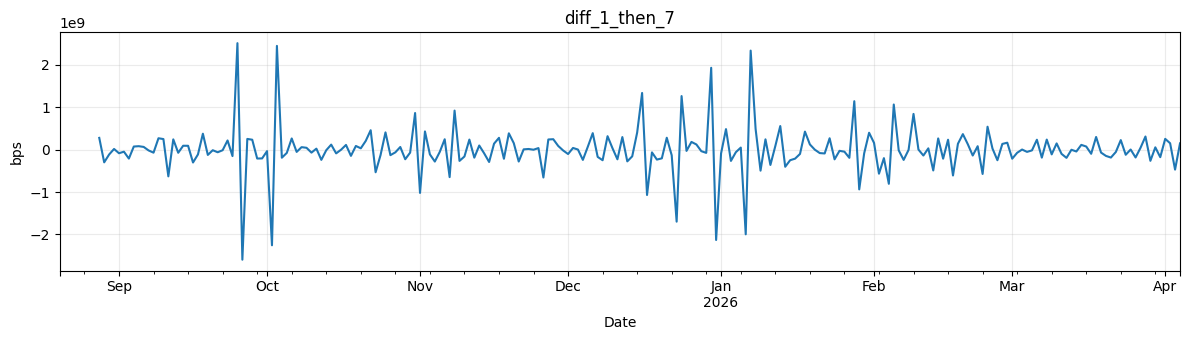

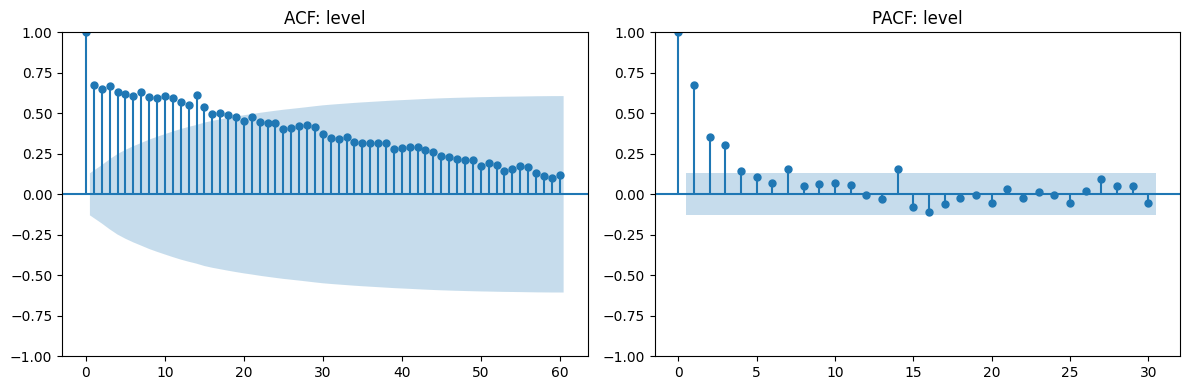

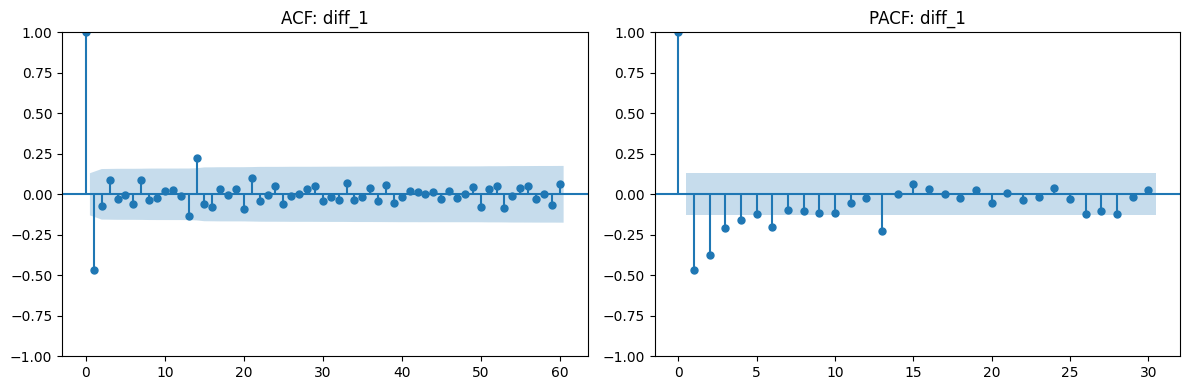

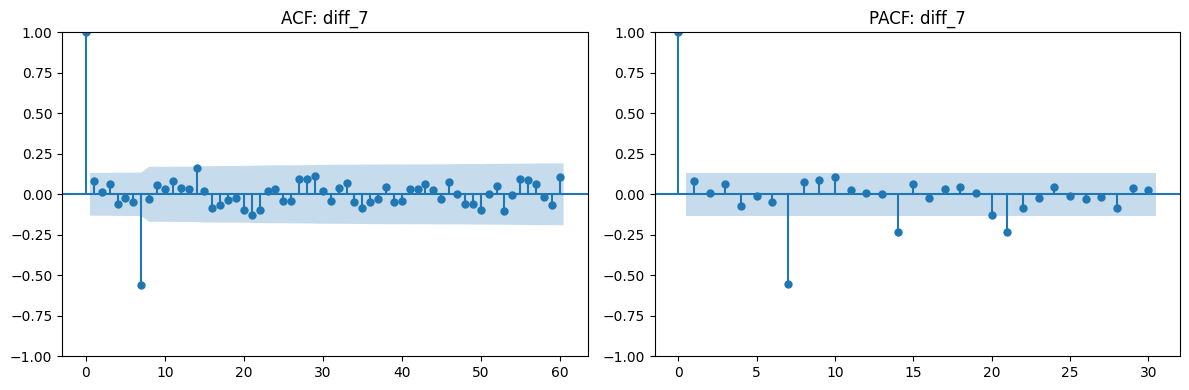

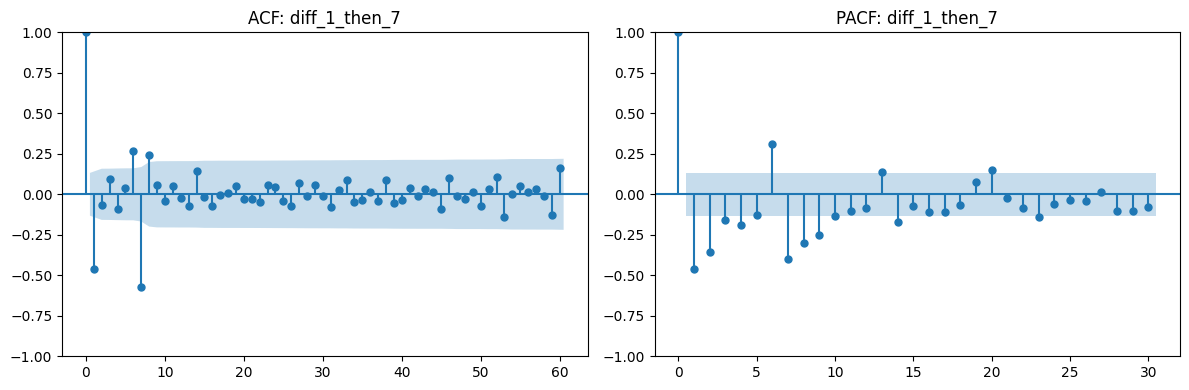

In [32]:
# Plot

for name, s in series_dict.items():
    fig, ax = plt.subplots(figsize=(12, 3.5))
    s.plot(ax=ax)
    ax.set_title(f"{name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("bps")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


# ACF+PACF for each series

for name, s in series_dict.items():
    s_clean = s.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(s_clean, lags=min(60, len(s_clean)//2 - 1), ax=axes[0])
    axes[0].set_title(f"ACF: {name}")

    plot_pacf(s_clean, lags=min(30, len(s_clean)//2 - 1), ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF: {name}")

    plt.tight_layout()
    plt.show()

**decision:**

- **Differencing:** `d = 1` is sufficient to achieve stationarity.  
After one regular difference, ADF rejects the unit root and KPSS fails to reject stationarity. Seasonal differencing (`D = 1`) is retained as a SARIMA candidate, but it is not required for stationarity alone.

- **Scale:** The original **bps scale** is retained for the baseline modeling workflow. Although rolling variance increases somewhat with the level, the pattern appears to be driven more by a few spike days than by a clearly multiplicative structure. A log transform might be considered later as an alternative specification in robustness checks.

- **Seasonal period:** `m = 7` (weekly) is retained as the natural seasonal candidate for daily modeling. Evidence comes from domain knowledge, the strong weekly structure in the earlier hourly EDA (including lag-168 behavior and the weekday–hour heatmap), and the fact that a daily network traffic series is naturally aligned with a weekly operating cycle. At the daily level, however, the seasonal signal is weaker and less explicit than the trend, so weekly seasonality is treated as a modeling candidate rather than as a dominant pattern already proven by the daily ACF alone.

These diagnostics motivate a baseline comparison between non-seasonal ARIMA models with `d = 1` and SARIMA models with seasonal period `m = 7`, while treating seasonal differencing (`D = 1`) as an additional candidate rather than a default requirement.

## <a id="5-forecast-horizon-and-baselines"></a>5) Forecast horizon and baselines

I set the forecasting horizon to **14 days**. This is long enough to cover **two full weekly cycles**, which is useful given the candidate seasonal period of `m = 7`, but still short enough to remain realistic for near-term capacity planning for business needs. To keep the evaluation simple and transparent, I use a **single train/test split**:

- **train:** all observations except the last 14 days
- **test:** the last 14 days

For baseline benchmarking, I use two simple reference forecasts:

- **Naïve:** predict each day using the most recent observed value (`t-1`)
- **Seasonal-Naïve:** predict each day using the value from the same weekday one week earlier (`t-7`)

These baselines provide a minimum standard that any ARIMA/SARIMA model should beat in order to justify its added complexity.

A more deployment-oriented evaluation could use rolling-origin backtesting over multiple 14-day forecast windows, for example over the last 28 days or longer, to assess stability across forecast origins.

In [33]:
y = daily_target["y_final"].copy()


# train-test split
H = 14

y_train = y.iloc[:-H].copy()
y_test = y.iloc[-H:].copy()

print("Train length:", len(y_train))
print("Test length:", len(y_test))
print("Train range:", y_train.index.min(), "->", y_train.index.max())
print("Test range :", y_test.index.min(), "->", y_test.index.max())

Train length: 214
Test length: 14
Train range: 2025-08-20 00:00:00+00:00 -> 2026-03-21 00:00:00+00:00
Test range : 2026-03-22 00:00:00+00:00 -> 2026-04-04 00:00:00+00:00


In [34]:
# naive forecast
# multi-step: repeat the last observed train value

naive_forecast = pd.Series(
    y_train.iloc[-1],
    index=y_test.index,
    name="naive_forecast"
)


# seasonal-nsive forecast (lag 7)
# for each test date, i use the value from 7 days earlier

seasonal_naive_forecast = y.shift(7).loc[y_test.index].copy()
seasonal_naive_forecast.name = "seasonal_naive_forecast"

# sanity
print("\nMissing values in seasonal naive forecast:", seasonal_naive_forecast.isna().sum())


# metrics
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 100

def evaluate_forecast(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "sMAPE": smape(y_true.values, y_pred.values),
    }

metrics = pd.DataFrame([
    evaluate_forecast(y_test, naive_forecast, "Naive"),
    evaluate_forecast(y_test, seasonal_naive_forecast, "Seasonal-Naive (t-7)")
]).set_index("model")

metrics


Missing values in seasonal naive forecast: 0


,MAE,RMSE,sMAPE
model,,,
Naive,1.737489e+08,2.106250e+08,6.008231
Seasonal-Naive (t-7),1.379894e+08,1.617793e+08,4.756114


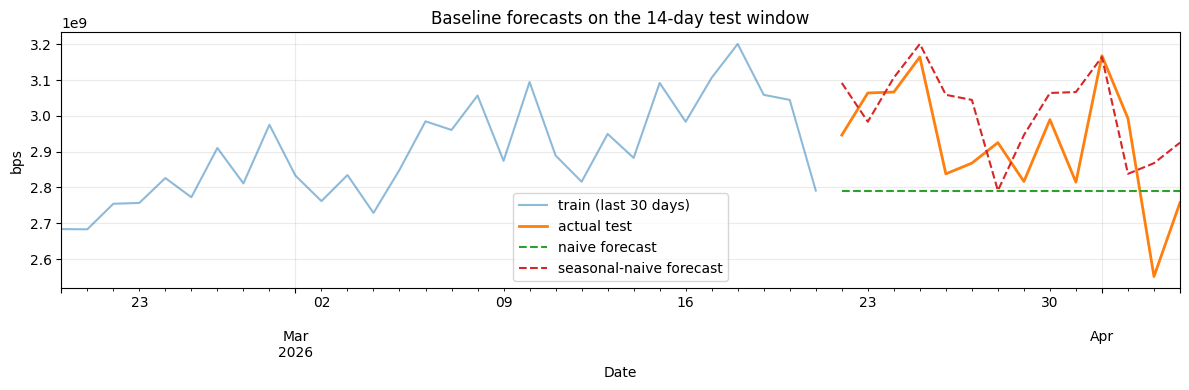

In [35]:
# visual
fig, ax = plt.subplots(figsize=(12, 4))

y_train.iloc[-30:].plot(ax=ax, label="train (last 30 days)", alpha=0.5)
y_test.plot(ax=ax, label="actual test", linewidth=2)
naive_forecast.plot(ax=ax, label="naive forecast", linestyle="--")
seasonal_naive_forecast.plot(ax=ax, label="seasonal-naive forecast", linestyle="--")

ax.set_title("Baseline forecasts on the 14-day test window")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Baseline interpretation

The **Seasonal-Naïve** baseline clearly outperforms the simple **Naïve** forecast on the 14-day test window across all three metrics. This suggests that, even though weekly seasonality was not very pronounced in the daily ACF, using the value from the **same weekday one week earlier (`t-7`)** is still a meaningfully stronger benchmark than simply copying the last observed day.

In practical terms, the daily traffic series contains enough short-run weekly structure that a weekday-matched forecast is more informative than a flat persistence forecast.

At the same time, the Seasonal-Naïve forecast is not perfect: it captures the general level reasonably well, but still misses sharper movements and the late drop in the test window.

Therefore, **Seasonal-Naïve becomes the main benchmark to beat**. Any ARIMA/SARIMA model should improve on this baseline!

## <a id="6-arima-sarima-modeling"></a> 6) ARIMA / SARIMA modeling

### Candidate model strategy

The stationarity diagnostics suggest that **first differencing (`d = 1`)** is required, while **seasonal differencing (`D = 1`)** is not clearly required by default.

Therefore, I follow a staged modeling strategy:

1. **ARIMA(p,1,q)** as the simplest differenced baseline  
2. **SARIMA(p,1,q)(P,0,Q,7)** to test whether weekly seasonal structure improves performance without adding seasonal differencing  
3. **SARIMA(p,1,q)(P,1,Q,7)** only as a later competitor if the non-seasonal and seasonally structured models with `D = 0` remain unconvincing

This keeps the workflow conservative: start with the simplest transformation that already appears sufficient, and only add seasonal differencing if the evidence justifies the extra complexity.

### ARIMA

I start with a **small ARIMA grid** guided by the ACF/PACF of the first-differenced series rather than by a large brute-force search.

The main signal in the differenced series is a **strong negative lag-1 spike in the ACF**, which is a classic hint that an **MA component** may be important after differencing. This makes **ARIMA(0,1,1)** the natural first candidate.

I then add a few nearby competitors:

- **ARIMA(1,1,1)** to allow for a small autoregressive component in addition to MA(1)
- **ARIMA(0,1,2)** to test whether a slightly richer MA structure improves fit
- **ARIMA(1,1,0)** as a pure AR comparison model
- **ARIMA(2,1,1)** as a somewhat richer specification, since the PACF still shows some short-lag structure beyond lag 1

This keeps the search interpretable and compact: the goal is to test a few plausible models supported by diagnostics, not to overfit with a large parameter grid.

**Model selection strategy:** 

Candidate ARIMA specifications are first ranked by AIC and BIC on the training set — this identifies the most parsimonious structure that fits the data well. The top candidates are then evaluated on the 14-day test window using MAE, RMSE, and sMAPE. AIC/BIC and test metrics may disagree: a model with slightly worse AIC can outperform on the test window if the in-sample fit was partly driven by overfitting.

The final model is selected primarily by test-window RMSE, since large forecast errors on a billing target carry disproportionate operational cost. I still report **MAE** and **sMAPE** for completeness, and I also track **AIC/BIC** as in-sample information criteria. However, AIC/BIC are not used as the primary selection rule here, because the main goal of the project is forecasting performance on unseen data rather than in-sample fit alone.

In [36]:
# modeling series and train/test split

y = daily_target["y_final"].copy()

H = 14
y_train = y.iloc[:-H].copy()
y_test  = y.iloc[-H:].copy()


# ARIMA candids
arima_orders = [
    (0, 1, 1),  
    (1, 1, 1),  
    (0, 1, 2),
    (1, 1, 0),
    (2, 1, 1),
]


# helper
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 100

rows = []
fits = {}


# fit on train, forecast 14-day test
for order in arima_orders:
    try:
        fit = ARIMA(y_train, order=order).fit()
        fc = fit.get_forecast(steps=H)
        pred = fc.predicted_mean

        rows.append({
            "order": order,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "sMAPE": smape(y_test, pred),
        })
        fits[order] = fit

    except Exception as e:
        rows.append({
            "order": order,
            "AIC": np.nan,
            "BIC": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "sMAPE": np.nan,
            "error": str(e),
        })

arima_results = pd.DataFrame(rows).sort_values(["MAE", "AIC"], na_position="last")
arima_results

,order,AIC,BIC,MAE,RMSE,sMAPE
2,"(0, 1, 2)",8958.481659,8968.565535,1.338398e+08,1.695095e+08,4.596161
1,"(1, 1, 1)",8958.922593,8969.006469,1.339233e+08,1.695902e+08,4.598965
4,"(2, 1, 1)",8960.456830,8973.901998,1.340642e+08,1.709163e+08,4.603663
0,"(0, 1, 1)",8957.062327,8963.784911,1.347417e+08,1.706045e+08,4.626407
3,"(1, 1, 0)",9011.861784,9018.584368,1.362713e+08,1.717408e+08,4.683446


In [37]:
# best by test RMSE among successful fits
best_order = arima_results.dropna(subset=["RMSE"]).iloc[0]["order"]
best_fit = fits[best_order]

print("Best ARIMA order by test RMSE:", best_order)
print(best_fit.summary())

Best ARIMA order by test RMSE: (0, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                y_final   No. Observations:                  214
Model:                 ARIMA(0, 1, 2)   Log Likelihood               -4476.241
Date:                Mon, 13 Apr 2026   AIC                           8958.482
Time:                        21:23:35   BIC                           8968.566
Sample:                    08-20-2025   HQIC                          8962.557
                         - 03-21-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8245      0.052    -15.873      0.000      -0.926      -0.723
ma.L2         -0.0270      0.063     -0.431      0.666      -0.150       0.096
sigma2     

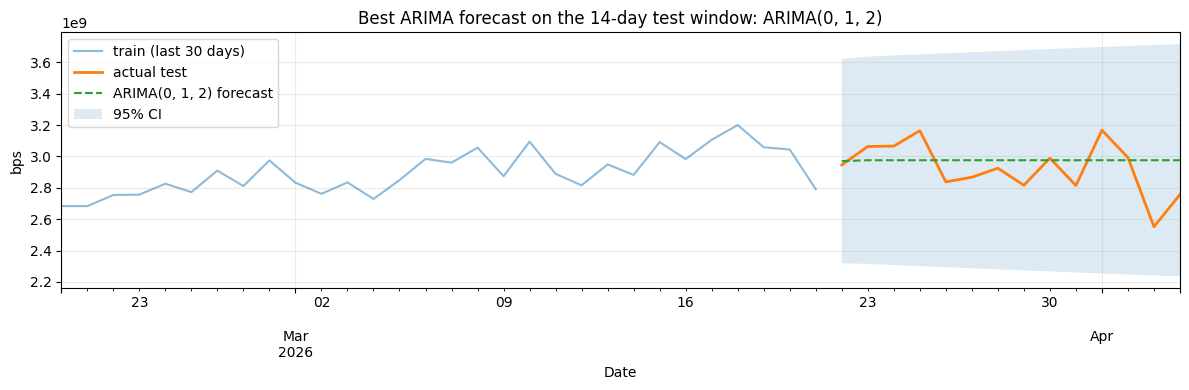

In [38]:
# forecast plot for the best ARIMA model

best_fc = best_fit.get_forecast(steps=H)
best_pred = best_fc.predicted_mean
best_ci = best_fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 4))
y_train.iloc[-30:].plot(ax=ax, label="train (last 30 days)", alpha=0.5)
y_test.plot(ax=ax, label="actual test", linewidth=2)
best_pred.plot(ax=ax, label=f"ARIMA{best_order} forecast", linestyle="--")
ax.fill_between(best_ci.index, best_ci.iloc[:, 0], best_ci.iloc[:, 1], alpha=0.15, label="95% CI")

ax.set_title(f"Best ARIMA forecast on the 14-day test window: ARIMA{best_order}")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### Residual diagnostics for 1–2 best ARIMA

Since difference between (0,1,2) and (0,1,1) is so tiny (difference on MAE is ~9Mbps frim 134 Mbps) it worth to take a look on both residuals

If residuals are indistinguishable between the two, (0,1,1) is preferred 
by parsimony — this will inform the base specification for SARIMA.

In [39]:
# take top 2 successful models by test RMSE
top_orders = [best_order, (0, 1, 1)]
top_orders

[(0, 1, 2), (0, 1, 1)]


=== Residual diagnostics for ARIMA(0, 1, 2) ===
                               SARIMAX Results                                
Dep. Variable:                y_final   No. Observations:                  214
Model:                 ARIMA(0, 1, 2)   Log Likelihood               -4476.241
Date:                Mon, 13 Apr 2026   AIC                           8958.482
Time:                        21:23:35   BIC                           8968.566
Sample:                    08-20-2025   HQIC                          8962.557
                         - 03-21-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8245      0.052    -15.873      0.000      -0.926      -0.723
ma.L2         -0.0270      0.063     -0.431      0.666      -0.150       0.096
sig

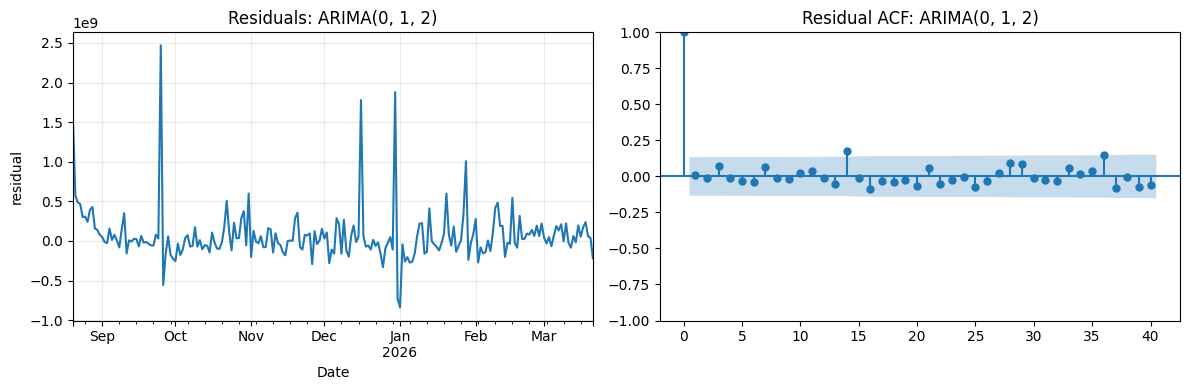


=== Residual diagnostics for ARIMA(0, 1, 1) ===
                               SARIMAX Results                                
Dep. Variable:                y_final   No. Observations:                  214
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -4476.531
Date:                Mon, 13 Apr 2026   AIC                           8957.062
Time:                        21:23:35   BIC                           8963.785
Sample:                    08-20-2025   HQIC                          8959.779
                         - 03-21-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8484      0.048    -17.658      0.000      -0.943      -0.754
sigma2       1.14e+17   8.15e-21    1.4e+37      0.000    1.14e+17    1.14e+17
Lju

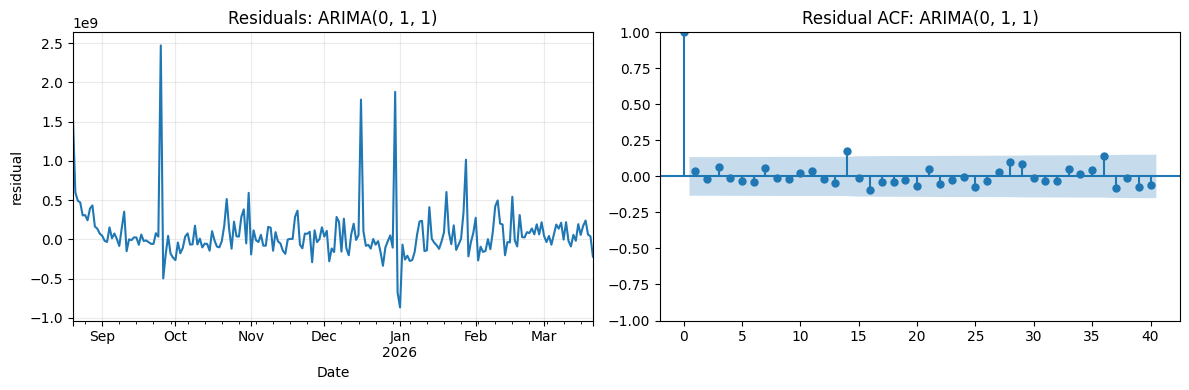

In [40]:
for order in top_orders:
    fit = fits[order]
    resid = fit.resid.dropna()

    print(f"\n=== Residual diagnostics for ARIMA{order} ===")
    print(fit.summary())

    # Ljung-Box on residuals
    lb = acorr_ljungbox(resid, lags=[7, 14], return_df=True)
    print("\nLjung-Box:")
    print(lb)

    # Residual plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    resid.plot(ax=axes[0])
    axes[0].set_title(f"Residuals: ARIMA{order}")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("residual")
    axes[0].grid(alpha=0.25)

    plot_acf(resid, lags=min(40, len(resid)//2 - 1), ax=axes[1])
    axes[1].set_title(f"Residual ACF: ARIMA{order}")

    plt.tight_layout()
    plt.show()

Both models pass the **Ljung–Box test** at lags 7 and 14 indicating no remaining residual autocorrelation at those horizons.

In **ARIMA(0,1,2)**, the second MA term is not significant (`p = 0.67`), while **AIC** also favors the simpler **ARIMA(0,1,1)** (`8957` vs `8958`). The two models show essentially the same residual pattern: strong non-normality, high kurtosis, and strong positive skew, which likely reflect shock-like spike days and heavy-tailed behavior in the data rather than residual linear dependence left unexplained by the model.

**Decision:** although **ARIMA(0,1,2)** is the best performer on the holdout window by the chosen forecast metric, **ARIMA(0,1,1)** is selected as the **base non-seasonal specification** for the next SARIMA step. It is more parsimonious, has lower AIC, all estimated parameters are significant, and its residual diagnostics are effectively indistinguishable from those of ARIMA(0,1,2).

### SARIMA candidate grid

I start with a small weekly SARIMA grid using seasonal period `m = 7` and keeping `D = 0` in the first wave.

This choice follows directly from the diagnostics:
- first differencing (`d = 1`) already appears sufficient for stationarity,
- weekly seasonality remains a plausible modeling candidate,
- but the daily ACF does not make seasonal differencing (`D = 1`) a default requirement.

Therefore, I first test whether adding **seasonal AR and/or MA terms** improves performance over the non-seasonal ARIMA baseline:

- SARIMA(0,1,1)(1,0,0,7)
- SARIMA(0,1,1)(0,0,1,7)
- SARIMA(0,1,1)(1,0,1,7)
- SARIMA(0,1,2)(1,0,0,7)
- SARIMA(0,1,2)(0,0,1,7)

Only if these models remain unconvincing will I test a second wave with seasonal differencing (`D = 1`).

In [41]:
y = daily_target["y_final"].copy()

H = 14
y_train = y.iloc[:-H].copy()
y_test  = y.iloc[-H:].copy()

In [42]:
# SARIMA first-wave grid

sarima_specs = [
    {"order": (0, 1, 1), "seasonal_order": (1, 0, 0, 7)},
    {"order": (0, 1, 1), "seasonal_order": (0, 0, 1, 7)},
    {"order": (0, 1, 1), "seasonal_order": (1, 0, 1, 7)},
    {"order": (0, 1, 2), "seasonal_order": (1, 0, 0, 7)},
    {"order": (0, 1, 2), "seasonal_order": (0, 0, 1, 7)},
]


rows = []
sarima_fits = {}


# fit
for spec in sarima_specs:
    order = spec["order"]
    seasonal_order = spec["seasonal_order"]

    try:
        fit = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        fc = fit.get_forecast(steps=H)
        pred = fc.predicted_mean

        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "sMAPE": smape(y_test, pred),
        })

        sarima_fits[(order, seasonal_order)] = fit

    except Exception as e:
        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": np.nan,
            "BIC": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "sMAPE": np.nan,
            "error": str(e),
        })

sarima_results = pd.DataFrame(rows).sort_values(["RMSE", "AIC"], na_position="last")
sarima_results

,order,seasonal_order,AIC,BIC,MAE,RMSE,sMAPE
3,"(0, 1, 2)","(1, 0, 0, 7)",8660.145261,8673.456765,1.319853e+08,1.670979e+08,4.533908
4,"(0, 1, 2)","(0, 0, 1, 7)",8536.391077,8549.643901,1.327815e+08,1.676765e+08,4.560664
0,"(0, 1, 1)","(1, 0, 0, 7)",8658.778896,8668.762524,1.325833e+08,1.678514e+08,4.554001
1,"(0, 1, 1)","(0, 0, 1, 7)",8576.062923,8586.017283,1.330416e+08,1.680111e+08,4.569400
2,"(0, 1, 1)","(1, 0, 1, 7)",8577.281743,8590.554223,1.325982e+08,1.684900e+08,4.554471


In [43]:
# Baseline results
baseline_cmp = metrics.reset_index().rename(columns={"model": "spec"})
baseline_cmp["family"] = "Baseline"

# Best ARIMA result(s)
arima_cmp = arima_results.copy()
arima_cmp["spec"] = arima_cmp["order"].apply(lambda x: f"ARIMA{x}")
arima_cmp["family"] = "ARIMA"

# SARIMA results
sarima_cmp = sarima_results.copy()
sarima_cmp["spec"] = sarima_cmp.apply(
    lambda r: f"SARIMA{r['order']}{r['seasonal_order']}",
    axis=1
)
sarima_cmp["family"] = "SARIMA"

# Harmonize columns
baseline_cmp = baseline_cmp[["spec", "family", "MAE", "RMSE", "sMAPE"]]
arima_cmp = arima_cmp[["spec", "family", "MAE", "RMSE", "sMAPE", "AIC", "BIC"]]
sarima_cmp = sarima_cmp[["spec", "family", "MAE", "RMSE", "sMAPE", "AIC", "BIC"]]

comparison = pd.concat([baseline_cmp, arima_cmp, sarima_cmp], ignore_index=True, sort=False)
comparison.sort_values(["RMSE", "MAE"], na_position="last")

,spec,family,MAE,RMSE,sMAPE,AIC,BIC
1,Seasonal-Naive (t-7),Baseline,1.379894e+08,1.617793e+08,4.756114,NaN,NaN
7,"SARIMA(0, 1, 2)(1, 0, 0, 7)",SARIMA,1.319853e+08,1.670979e+08,4.533908,8660.145261,8673.456765
8,"SARIMA(0, 1, 2)(0, 0, 1, 7)",SARIMA,1.327815e+08,1.676765e+08,4.560664,8536.391077,8549.643901
9,"SARIMA(0, 1, 1)(1, 0, 0, 7)",SARIMA,1.325833e+08,1.678514e+08,4.554001,8658.778896,8668.762524
10,"SARIMA(0, 1, 1)(0, 0, 1, 7)",SARIMA,1.330416e+08,1.680111e+08,4.569400,8576.062923,8586.017283
11,"SARIMA(0, 1, 1)(1, 0, 1, 7)",SARIMA,1.325982e+08,1.684900e+08,4.554471,8577.281743,8590.554223
2,"ARIMA(0, 1, 2)",ARIMA,1.338398e+08,1.695095e+08,4.596161,8958.481659,8968.565535
3,"ARIMA(1, 1, 1)",ARIMA,1.339233e+08,1.695902e+08,4.598965,8958.922593,8969.006469
5,"ARIMA(0, 1, 1)",ARIMA,1.347417e+08,1.706045e+08,4.626407,8957.062327,8963.784911
4,"ARIMA(2, 1, 1)",ARIMA,1.340642e+08,1.709163e+08,4.603663,8960.456830,8973.901998


In [44]:
# best sarima 
best_sarima_row = sarima_results.dropna(subset=["RMSE"]).iloc[0]
best_order = best_sarima_row["order"]
best_seasonal_order = best_sarima_row["seasonal_order"]

best_sarima_fit = sarima_fits[(best_order, best_seasonal_order)]

print("Best SARIMA by test RMSE:")
print("order =", best_order)
print("seasonal_order =", best_seasonal_order)

print(best_sarima_fit.summary())

Best SARIMA by test RMSE:
order = (0, 1, 2)
seasonal_order = (1, 0, 0, 7)
                                     SARIMAX Results                                      
Dep. Variable:                            y_final   No. Observations:                  214
Model:             SARIMAX(0, 1, 2)x(1, 0, [], 7)   Log Likelihood               -4326.073
Date:                            Mon, 13 Apr 2026   AIC                           8660.145
Time:                                    21:23:35   BIC                           8673.457
Sample:                                08-20-2025   HQIC                          8665.529
                                     - 03-21-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8621      0.059    -14.

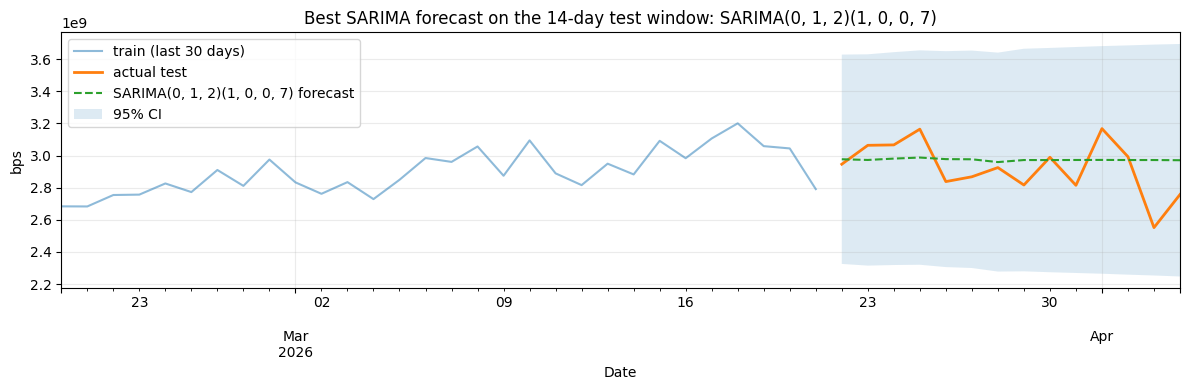

In [45]:
best_fc = best_sarima_fit.get_forecast(steps=H)
best_pred = best_fc.predicted_mean
best_ci = best_fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 4))
y_train.iloc[-30:].plot(ax=ax, label="train (last 30 days)", alpha=0.5)
y_test.plot(ax=ax, label="actual test", linewidth=2)
best_pred.plot(ax=ax, label=f"SARIMA{best_order}{best_seasonal_order} forecast", linestyle="--")
ax.fill_between(best_ci.index, best_ci.iloc[:, 0], best_ci.iloc[:, 1], alpha=0.15, label="95% CI")

ax.set_title(f"Best SARIMA forecast on the 14-day test window: SARIMA{best_order}{best_seasonal_order}")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### SARIMA residuals

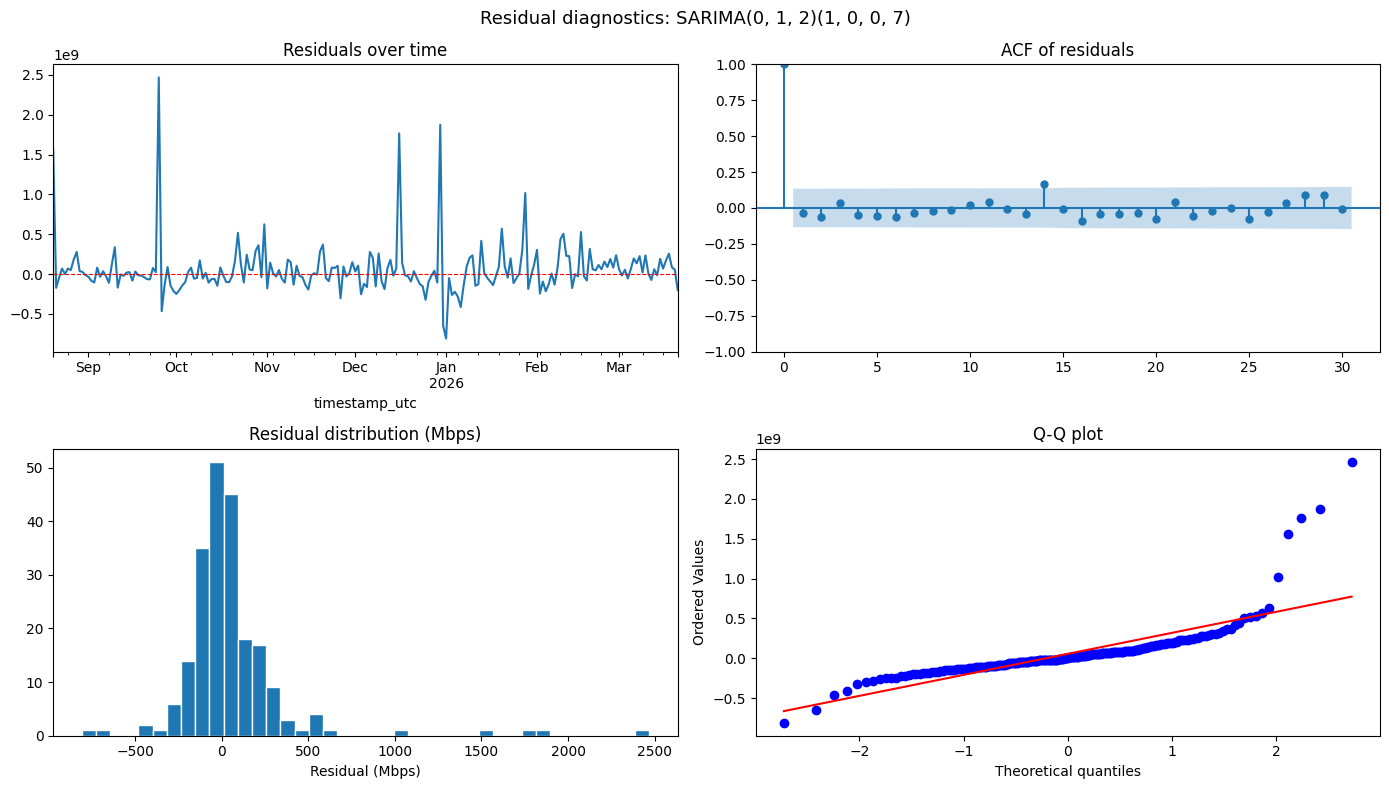

In [46]:
resid = best_sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Residual diagnostics: SARIMA{best_order}{best_seasonal_order}", fontsize=13)

# resid over time
resid.plot(ax=axes[0, 0], title="Residuals over time")
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=0.8)

# ACF of residuals
plot_acf(resid, lags=30, ax=axes[0, 1], title="ACF of residuals")

# hist
axes[1, 0].hist(resid / 1e6, bins=40, edgecolor="white")
axes[1, 0].set_title("Residual distribution (Mbps)")
axes[1, 0].set_xlabel("Residual (Mbps)")

# QQ plot

stats.probplot(resid, plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot")

plt.tight_layout()
plt.show()

### SARIMA interpretation

The first-wave SARIMA models improve in-sample fit substantially relative to the non-seasonal ARIMA candidates, but they do not clearly outperform the **Seasonal-Naive** baseline on the 14-day holdout window.

The strongest SARIMA candidate, **SARIMA(0,1,2)(1,0,0,7)**, achieves slightly lower MAE and sMAPE than the baseline, but its **RMSE remains worse than Seasonal-Naive**, which is the primary selection metric in this project. This means the seasonal model may reduce average day-to-day error slightly, but it does not improve performance on larger forecast misses.

Residual autocorrelation is not a major problem, but the seasonal AR term is not statistically significant, and the resulting multi-step forecast is still close to flat. This suggests that, in the current specification, the seasonal block adds limited practical predictive value. Residuals exhibit heavy tails (kurtosis = 27.89) consistent with rare traffic burst events, but show no systematic autocorrelation (Ljung-Box p = 0.69) and good central fit on the Q-Q plot — indicating the SARIMA captures the regular traffic pattern well.

### Additional targeted SARIMA checks

At this point, **Seasonal-Naive (t-7)** remains the strongest model on the 14-day holdout window by the primary metric (**RMSE**).  
This does not automatically mean that further SARIMA work is unjustified, but it does mean that any additional complexity must be motivated carefully.

The goal of this extra step is **not** to keep expanding the SARIMA grid indefinitely.  
Instead, I test only two targeted ideas suggested by the earlier results:

1. **Trend-aware SARIMA**
   - The first-wave ARIMA/SARIMA forecasts were very flat over the holdout window.
   - Since the recent part of the series still shows an elevated level, I test whether adding a deterministic trend term improves multi-step forecasts.

2. **Seasonal differencing (`D = 1`)**
   - Weekly seasonality was not very explicit in the daily ACF, so `D = 1` was not used by default.
   - However, the strong performance of the **Seasonal-Naive** baseline suggests that weekly repetition may still matter enough to justify one small second-wave check with seasonal differencing.

These extra models are evaluated using the **same primary selection rule as before**:
- **RMSE on the 14-day holdout window** is primary,
- **MAE** and **sMAPE** are secondary,
- and residual diagnostics are used only as supporting evidence, not as the main selection criterion.

This keeps the workflow disciplined: targeted additional checks are allowed, but the benchmark to beat remains the same.

In [47]:
seasonal_naive_rmse = metrics.loc["Seasonal-Naive (t-7)", "RMSE"]
seasonal_naive_mae = metrics.loc["Seasonal-Naive (t-7)", "MAE"]
seasonal_naive_smape = metrics.loc["Seasonal-Naive (t-7)", "sMAPE"]

extra_sarima_specs = [
    {
        "name": "SARIMA(0,1,1)(1,0,0,7)+trend_t",
        "order": (0, 1, 1),
        "seasonal_order": (1, 0, 0, 7),
        "trend": "t",
        "idea": "trend-aware + seasonal AR"
    },
    {
        "name": "SARIMA(0,1,1)(0,0,1,7)+trend_t",
        "order": (0, 1, 1),
        "seasonal_order": (0, 0, 1, 7),
        "trend": "t",
        "idea": "trend-aware + seasonal MA"
    },
    {
        "name": "SARIMA(0,1,1)(1,1,0,7)",
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 0, 7),
        "trend": "n",
        "idea": "seasonal differencing + seasonal AR"
    },
    {
        "name": "SARIMA(0,1,1)(0,1,1,7)",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 7),
        "trend": "n",
        "idea": "seasonal differencing + seasonal MA"
    },
]

extra_rows = []
extra_fits = {}

for spec in extra_sarima_specs:
    try:
        fit = SARIMAX(
            y_train,
            order=spec["order"],
            seasonal_order=spec["seasonal_order"],
            trend=spec["trend"],
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        fc = fit.get_forecast(steps=H)
        pred = fc.predicted_mean

        extra_rows.append({
            "name": spec["name"],
            "idea": spec["idea"],
            "order": spec["order"],
            "seasonal_order": spec["seasonal_order"],
            "trend": spec["trend"],
            "AIC": fit.aic,
            "BIC": fit.bic,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "sMAPE": smape(y_test, pred),
            "beats_seasonal_naive_RMSE": np.sqrt(mean_squared_error(y_test, pred)) < seasonal_naive_rmse,
            "beats_seasonal_naive_MAE": mean_absolute_error(y_test, pred) < seasonal_naive_mae,
            "beats_seasonal_naive_sMAPE": smape(y_test, pred) < seasonal_naive_smape,
        })

        extra_fits[spec["name"]] = fit

    except Exception as e:
        extra_rows.append({
            "name": spec["name"],
            "idea": spec["idea"],
            "order": spec["order"],
            "seasonal_order": spec["seasonal_order"],
            "trend": spec["trend"],
            "AIC": np.nan,
            "BIC": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "sMAPE": np.nan,
            "beats_seasonal_naive_RMSE": False,
            "beats_seasonal_naive_MAE": False,
            "beats_seasonal_naive_sMAPE": False,
            "error": str(e),
        })

extra_sarima_results = pd.DataFrame(extra_rows).sort_values(["RMSE", "MAE"], na_position="last")
extra_sarima_results

,name,idea,order,seasonal_order,trend,AIC,BIC,MAE,RMSE,sMAPE,beats_seasonal_naive_RMSE,beats_seasonal_naive_MAE,beats_seasonal_naive_sMAPE
3,"SARIMA(0,1,1)(0,1,1,7)",seasonal differencing + seasonal MA,"(0, 1, 1)","(0, 1, 1, 7)",n,8349.366820,8359.216431,1.973937e+08,2.542577e+08,6.659606,False,False,False
2,"SARIMA(0,1,1)(1,1,0,7)",seasonal differencing + seasonal AR,"(0, 1, 1)","(1, 1, 0, 7)",n,8443.806629,8453.686544,2.054679e+08,2.630052e+08,6.885812,False,False,False
1,"SARIMA(0,1,1)(0,0,1,7)+trend_t",trend-aware + seasonal MA,"(0, 1, 1)","(0, 0, 1, 7)",t,8580.807387,8594.079866,4.191302e+08,4.821128e+08,13.441143,False,False,False
0,"SARIMA(0,1,1)(1,0,0,7)+trend_t",trend-aware + seasonal AR,"(0, 1, 1)","(1, 0, 0, 7)",t,8664.359598,8677.671103,4.216602e+08,4.852234e+08,13.514120,False,False,False


In [48]:
summary_compare = extra_sarima_results.copy()

summary_compare["RMSE_vs_seasonal_naive"] = summary_compare["RMSE"] - seasonal_naive_rmse
summary_compare["MAE_vs_seasonal_naive"] = summary_compare["MAE"] - seasonal_naive_mae
summary_compare["sMAPE_vs_seasonal_naive"] = summary_compare["sMAPE"] - seasonal_naive_smape

summary_compare[[
    "name", "idea", "RMSE", "MAE", "sMAPE",
    "RMSE_vs_seasonal_naive", "MAE_vs_seasonal_naive", "sMAPE_vs_seasonal_naive",
    "AIC", "BIC"
]].sort_values("RMSE")

,name,idea,RMSE,MAE,sMAPE,RMSE_vs_seasonal_naive,MAE_vs_seasonal_naive,sMAPE_vs_seasonal_naive,AIC,BIC
3,"SARIMA(0,1,1)(0,1,1,7)",seasonal differencing + seasonal MA,2.542577e+08,1.973937e+08,6.659606,9.247841e+07,5.940429e+07,1.903492,8349.366820,8359.216431
2,"SARIMA(0,1,1)(1,1,0,7)",seasonal differencing + seasonal AR,2.630052e+08,2.054679e+08,6.885812,1.012259e+08,6.747846e+07,2.129697,8443.806629,8453.686544
1,"SARIMA(0,1,1)(0,0,1,7)+trend_t",trend-aware + seasonal MA,4.821128e+08,4.191302e+08,13.441143,3.203335e+08,2.811407e+08,8.685028,8580.807387,8594.079866
0,"SARIMA(0,1,1)(1,0,0,7)+trend_t",trend-aware + seasonal AR,4.852234e+08,4.216602e+08,13.514120,3.234441e+08,2.836708e+08,8.758005,8664.359598,8677.671103


In [49]:
best_extra_name = extra_sarima_results.dropna(subset=["RMSE"]).iloc[0]["name"]
best_extra_fit = extra_fits[best_extra_name]

print("Best extra SARIMA by holdout RMSE:", best_extra_name)
print(best_extra_fit.summary())

Best extra SARIMA by holdout RMSE: SARIMA(0,1,1)(0,1,1,7)
                                     SARIMAX Results                                     
Dep. Variable:                           y_final   No. Observations:                  214
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -4171.683
Date:                           Mon, 13 Apr 2026   AIC                           8349.367
Time:                                   21:23:36   BIC                           8359.216
Sample:                               08-20-2025   HQIC                          8353.354
                                    - 03-21-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7203      0.069    -10.464      0.000      -0.8

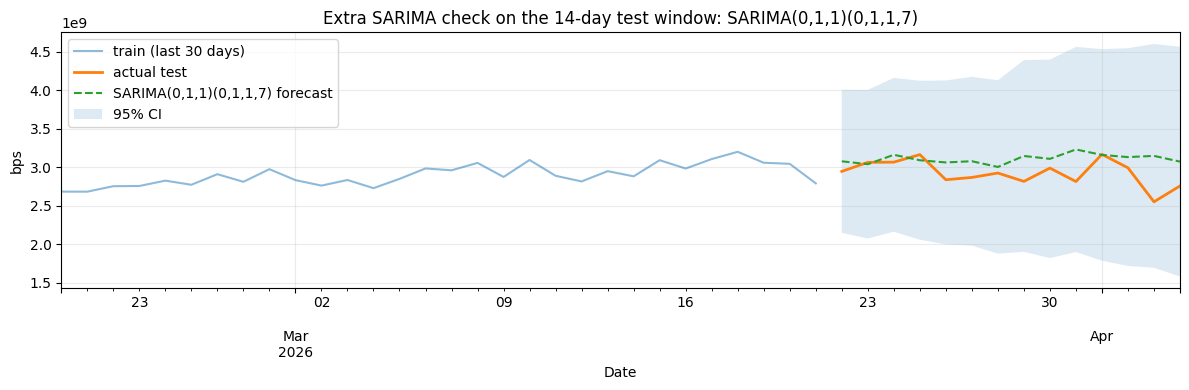

In [50]:
best_fc = best_extra_fit.get_forecast(steps=H)
best_pred = best_fc.predicted_mean
best_ci = best_fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 4))
y_train.iloc[-30:].plot(ax=ax, label="train (last 30 days)", alpha=0.5)
y_test.plot(ax=ax, label="actual test", linewidth=2)
best_pred.plot(ax=ax, label=f"{best_extra_name} forecast", linestyle="--")
ax.fill_between(best_ci.index, best_ci.iloc[:, 0], best_ci.iloc[:, 1], alpha=0.15, label="95% CI")

ax.set_title(f"Extra SARIMA check on the 14-day test window: {best_extra_name}")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


=== Residual diagnostics for SARIMA(0,1,1)(0,1,1,7) ===
                                     SARIMAX Results                                     
Dep. Variable:                           y_final   No. Observations:                  214
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -4171.683
Date:                           Mon, 13 Apr 2026   AIC                           8349.367
Time:                                   21:23:36   BIC                           8359.216
Sample:                               08-20-2025   HQIC                          8353.354
                                    - 03-21-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7203      0.069    -10.464      0.000      -0.85

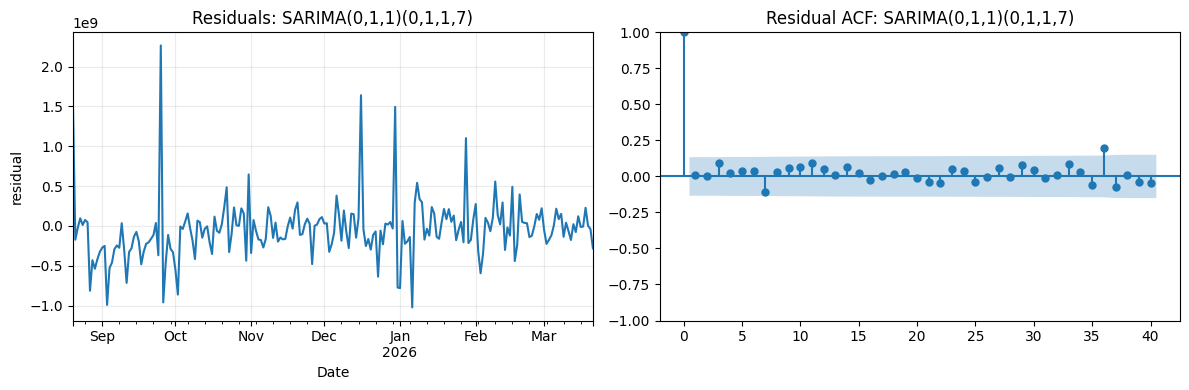


=== Residual diagnostics for SARIMA(0,1,1)(1,1,0,7) ===
                                     SARIMAX Results                                      
Dep. Variable:                            y_final   No. Observations:                  214
Model:             SARIMAX(0, 1, 1)x(1, 1, [], 7)   Log Likelihood               -4218.903
Date:                            Mon, 13 Apr 2026   AIC                           8443.807
Time:                                    21:23:36   BIC                           8453.687
Sample:                                08-20-2025   HQIC                          8447.805
                                     - 03-21-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7899      0.072    -10.922      0.000   

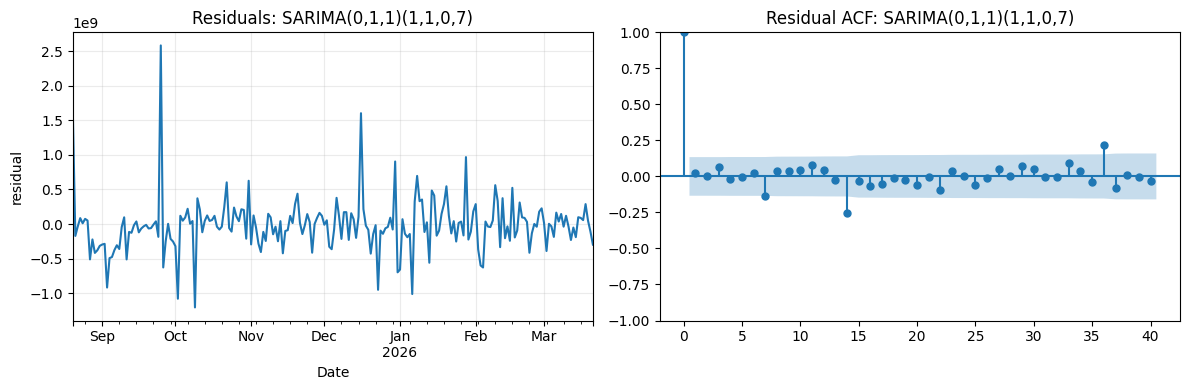

In [51]:
top_extra_names = extra_sarima_results.dropna(subset=["RMSE"]).head(2)["name"].tolist()

for name in top_extra_names:
    fit = extra_fits[name]
    resid = fit.resid.dropna()

    print(f"\n=== Residual diagnostics for {name} ===")
    print(fit.summary())

    lb = acorr_ljungbox(resid, lags=[7, 14], return_df=True)
    print("\nLjung-Box:")
    print(lb)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    resid.plot(ax=axes[0])
    axes[0].set_title(f"Residuals: {name}")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("residual")
    axes[0].grid(alpha=0.25)

    plot_acf(resid, lags=min(40, len(resid)//2 - 1), ax=axes[1])
    axes[1].set_title(f"Residual ACF: {name}")

    plt.tight_layout()
    plt.show()

Double differencing (d=1, D=1) removes both the normal trend and the seasonal trend, leaving only the pure MA structure for the model to fit.
This improves the point forecast: **RMSE = 254M bps** — the best result
among all tested SARIMA configurations.

However, the model exhibits two serious caveats:

- **Singular covariance matrix**:
the standard errors of the coefficients are numerically unstable and cannot
be used for confidence intervals for the parameters. This is a consequence of
overdifferentiation—the series after d=1, D=1 becomes
"too stationary" for reliable estimation of the MA components.

- **Explosive 95% CI**: forecast uncertainty doubles with each step
forward. By day 14, the interval covers a range of ~3.0 Gbps—almost the entire observed traffic range. This CI is useless for operational
planning.

**Conclusion:** The model improves the point RMSE due to its stability and
interpretability. This is a typical trade-off overdifferenced SARIMA:
more accurate on average, but less reliable as a decision-making tool.

### Final model decision

Using **RMSE on the 14-day holdout window** as the primary selection criterion, the overall champion in this project is **Seasonal-Naive (t-7)**.

Although several ARIMA and SARIMA models improved in-sample fit and some of them slightly reduced MAE or sMAPE, none of the tested statistical models beat Seasonal-Naive on the chosen primary metric. In particular, the strongest seasonal statistical model, **SARIMA(0,1,2)(1,0,0,7)**, remained slightly worse in RMSE, while the additional SARIMA models with seasonal differencing produced
wider uncertainty bands — and although one of them (SARIMA(0,1,1)(0,1,1,7))
achieved the best point RMSE among all statistical models, its numerical
instability and explosive confidence intervals make it unsuitable as an
operational forecast.

This suggests that, for this target and this short forecast horizon, the weekly persistence captured by a simple same-weekday baseline is stronger than the extra structure learned by the tested ARIMA/SARIMA specifications.

Therefore:

- **Operational champion:** Seasonal-Naive (t-7)
- **Strongest statistical competitor:** SARIMA(0,1,2)(1,0,0,7)

The final conclusion is not that SARIMA is bad in general, but that in this specific setup it does not justify replacing the simpler weekly benchmark.

Further work with ML-based approaches (e.g., Prophet or gradient boosting
with calendar features) may better capture the spike behaviour that drives
the non-normality observed in residuals.

## <a id="7-prophet-forecast"></a> 7) Prophet forecast

Prophet is included as an exploratory extension rather than a primary
competitor. Motivation is to observe how a decomposition-based model behaves on data where parametric ARIMA/SARIMA already struggled to beat a simple baseline.

Although Prophet is more naturally suited to sub-daily data with multiple
seasonality levels (e.g., the original hourly uplink series), this capstone
evaluates all models on a single common target. Therefore, Prophet is tested
on the **same daily p95 series, train/test split, and evaluation metrics** as ARIMA, SARIMA, and the baseline models.

In [52]:
# modeling series and split
y = daily_target["y_final"].copy()

H = 14
y_train = y.iloc[:-H].copy()
y_test  = y.iloc[-H:].copy()

# Prophet expects columns ds and y
train_df = y_train.rename("y").reset_index()
train_df = train_df.rename(columns={train_df.columns[0]: "ds"})

# Prophet usually works best with tz-naive datetimes
train_df["ds"] = pd.to_datetime(train_df["ds"]).dt.tz_localize(None)

# еest index for later alignment
test_index = pd.to_datetime(y_test.index).tz_localize(None)

In [53]:
# baseline Prophet specification
prophet_model = Prophet(
    growth="linear",
    weekly_seasonality=True,
    yearly_seasonality=False, #dont have more than a year
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.03, #also tested without it or 0.001, 0.01 which affects trends flexibility
    interval_width=0.95 # prophet default is 0.80 bt i wanna be consistent with what we did in SARIMA
)

prophet_model.add_country_holidays(country_name='RU') # knowing most of the clients on these uplinks are from Russia

prophet_model.fit(train_df)


# rorecast next 14 days
future = prophet_model.make_future_dataframe(periods=H, freq="D", include_history=False)
forecast = prophet_model.predict(future)

prophet_pred = forecast.set_index("ds")["yhat"].copy()
prophet_pred = prophet_pred.loc[test_index]


# metrics
prophet_metrics = pd.DataFrame([{
    "model": "Prophet",
    "MAE": mean_absolute_error(y_test.values, prophet_pred.values),
    "RMSE": np.sqrt(mean_squared_error(y_test.values, prophet_pred.values)),
    "sMAPE": smape(y_test.values, prophet_pred.values),
}]).set_index("model")

prophet_metrics

21:23:36 - cmdstanpy - INFO - Chain [1] start processing
21:23:37 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE,sMAPE
model,,,
Prophet,1.400431e+08,1.771940e+08,4.812509


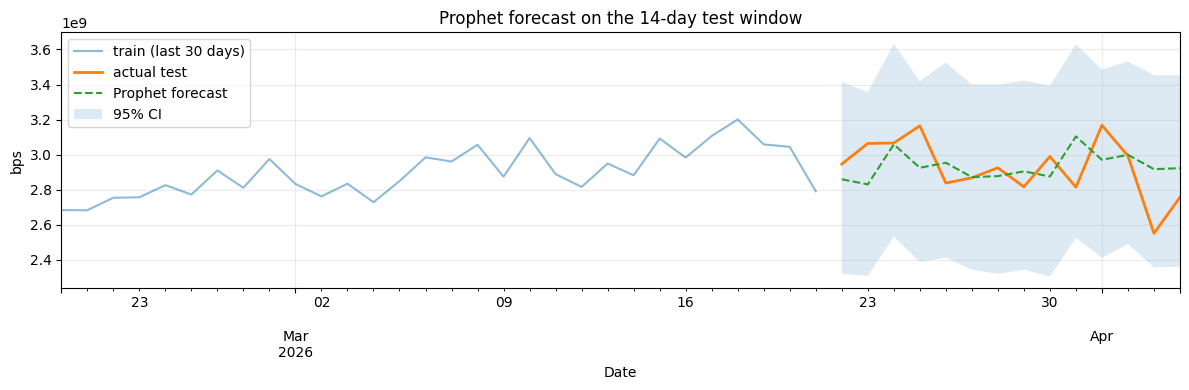

In [54]:
# build history+future for plotting components
future_all = prophet_model.make_future_dataframe(periods=H, freq="D", include_history=True)
forecast_all = prophet_model.predict(future_all)

# visual
fig, ax = plt.subplots(figsize=(12, 4))
y_train.iloc[-30:].rename_axis("ds").plot(ax=ax, label="train (last 30 days)", alpha=0.5)
y_test.rename_axis("ds").plot(ax=ax, label="actual test", linewidth=2)

prophet_pred_series = pd.Series(prophet_pred.values, index=y_test.index, name="Prophet forecast")
prophet_pred_series.plot(ax=ax, label="Prophet forecast", linestyle="--")

# confidence interval
forecast_test = forecast.set_index("ds").loc[test_index]
ax.fill_between(
    y_test.index,
    forecast_test["yhat_lower"].values,
    forecast_test["yhat_upper"].values,
    alpha=0.15,
    label="95% CI"
)

ax.set_title("Prophet forecast on the 14-day test window")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

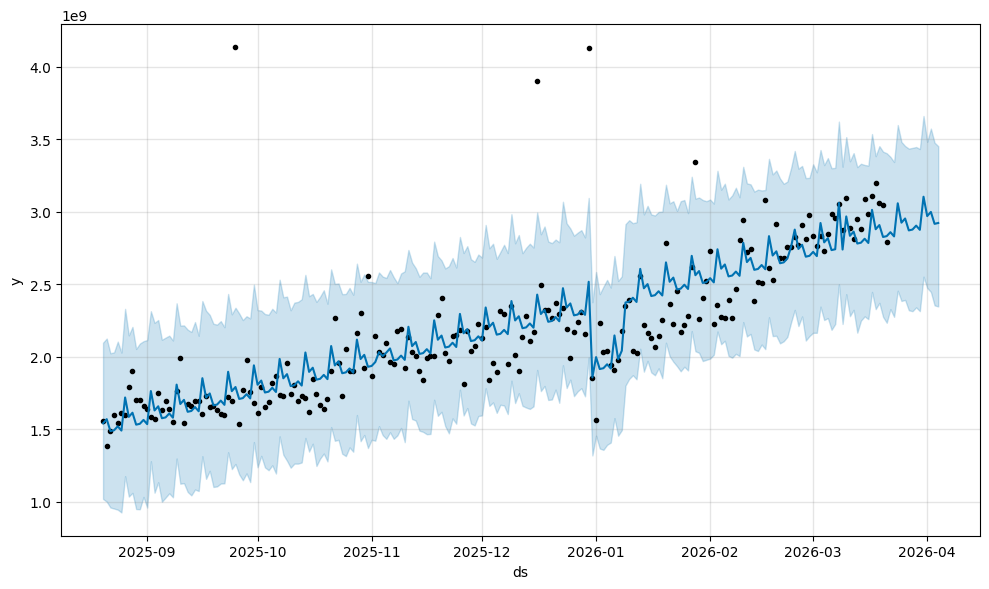

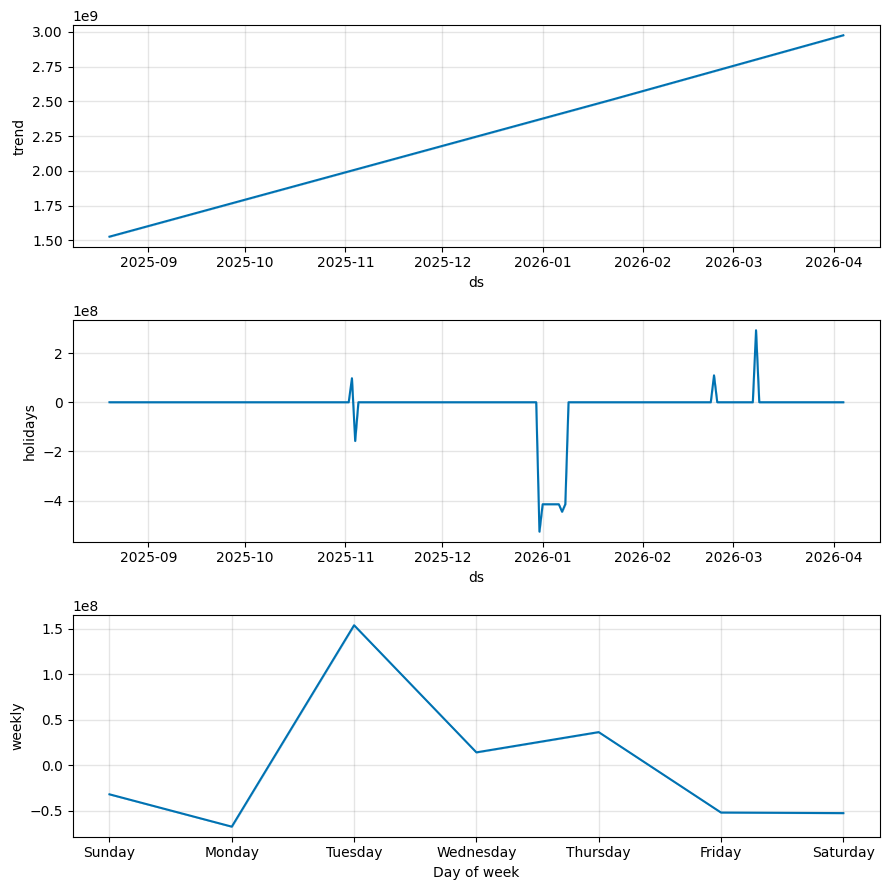

In [55]:
# Prophet built-in plots
fig1 = prophet_model.plot(forecast_all)
plt.tight_layout()
plt.show()

fig2 = prophet_model.plot_components(forecast_all)
plt.tight_layout()
plt.show()

In [56]:
# compatison with other models
prophet_cmp = prophet_metrics.reset_index().rename(columns={"model": "spec"})
prophet_cmp["family"] = "Prophet"

comparison_with_prophet = pd.concat(
    [
        comparison,
        prophet_cmp[["spec", "family", "MAE", "RMSE", "sMAPE"]],
    ],
    ignore_index=True,
    sort=False,
)

comparison_with_prophet.sort_values(["RMSE", "MAE"], na_position="last")

,spec,family,MAE,RMSE,sMAPE,AIC,BIC
1,Seasonal-Naive (t-7),Baseline,1.379894e+08,1.617793e+08,4.756114,NaN,NaN
7,"SARIMA(0, 1, 2)(1, 0, 0, 7)",SARIMA,1.319853e+08,1.670979e+08,4.533908,8660.145261,8673.456765
8,"SARIMA(0, 1, 2)(0, 0, 1, 7)",SARIMA,1.327815e+08,1.676765e+08,4.560664,8536.391077,8549.643901
9,"SARIMA(0, 1, 1)(1, 0, 0, 7)",SARIMA,1.325833e+08,1.678514e+08,4.554001,8658.778896,8668.762524
10,"SARIMA(0, 1, 1)(0, 0, 1, 7)",SARIMA,1.330416e+08,1.680111e+08,4.569400,8576.062923,8586.017283
11,"SARIMA(0, 1, 1)(1, 0, 1, 7)",SARIMA,1.325982e+08,1.684900e+08,4.554471,8577.281743,8590.554223
2,"ARIMA(0, 1, 2)",ARIMA,1.338398e+08,1.695095e+08,4.596161,8958.481659,8968.565535
3,"ARIMA(1, 1, 1)",ARIMA,1.339233e+08,1.695902e+08,4.598965,8958.922593,8969.006469
5,"ARIMA(0, 1, 1)",ARIMA,1.347417e+08,1.706045e+08,4.626407,8957.062327,8963.784911
4,"ARIMA(2, 1, 1)",ARIMA,1.340642e+08,1.709163e+08,4.603663,8960.456830,8973.901998


### interpretation

The model learned a reasonable smooth upward trend and a mild weekly seasonal pattern, but its holdout forecast remained too smooth relative to the observed test window. In particular, it failed to capture the sharper local deviations and the late drop in the series.

As a result, Prophet underperformed across all reported error metrics.

This suggests that, for the **daily 95th-percentile target**, the series is driven not only by smooth trend and weekly structure, but also by shock-like upper-tail variation that Prophet does not model well in this simple specification.

The result suggests that Prophet may be more naturally tested on the original hourly traffic series, where intraday and weekly seasonal structure are more directly visible.

Interesting that Prophet's weekly component actually produced a meaningful weekday pattern which looks close to observed on EDA. But problem is that the final forecast for this target is determined not only by the weekly structure, but also by upper-tail instability, shock-like days, local level shifts which models currently fails to catch.

I think that adding some exogenous regressors wwould probably change the Prophet performance to much better but exploting this is not a goal of a current capstone and requires a separate project. 

## <a id="8-machine-learning-pipeline-ridge-random-forest"></a> 8) Machine Learning pipeline - Ridge / Random Forest

### Goal and approach

The ML pipeline tests whether supervised regression models with
hand-crafted time-series features can improve over the statistical
baselines on the same task: forecasting the daily p95 uplink traffic
for the next **14 days** on the same train/test split.

Two model families are compared:
- **Ridge regression** — linear model with L2 regularisation; expected
  to perform well if the dominant signal is the weekly lag (t-7), which
  acts as a direct numerical proxy for Seasonal Naïve
- **Random Forest** — non-parametric tree ensemble; can capture
  non-linear interactions between calendar and lag features, but risks
  overfitting on 230 training points

Both models produce **recursive multi-step forecasts**: at each step
the predicted value is fed back as a lag feature for the next step.
This is the only leakage-safe strategy for a 14-day horizon without
future covariates.

### Features

I use three groups of predictors:

- **Lag features:** `lag_1`, `lag_7` 
  These capture short-term persistence, same-weekday repetition.

- **Rolling features:** `rolling_mean_7`, `rolling_std_7` 
  These summarize the recent local level and variability of the series. Lag features alone describe specific past points, while rolling features provide context about the recent regime.

- **Calendar features:** weekday one-hot encoding and `is_weekend`  
  These capture weekly operating structure without imposing a false numeric ordering on weekdays.

I do not use a large exogenous feature set in this optional section. The purpose here is to test whether simple ML models can improve on the same single-series forecasting task using only information derived from the target history and the calendar.

All lagged and rolling features are constructed in a **leakage-safe** way, using only information available up to time `t-1`.

In [57]:
# final daily modeling series

y = daily_target["y_final"].copy()
y.name = "y"


# build leakage-safe features
ml_df = pd.DataFrame(index=y.index)
ml_df["y"] = y

# lag features
ml_df["lag_1"] = y.shift(1)
ml_df["lag_7"] = y.shift(7)


# rolling features
ml_df["rolling_mean_7"] = y.shift(1).rolling(window=7).mean()
ml_df["rolling_std_7"] = y.shift(1).rolling(window=7).std()


# calendar features
ml_df["day_of_week"] = ml_df.index.dayofweek
ml_df["is_weekend"] = ml_df["day_of_week"].isin([5, 6]).astype(int)

# weekday one-hot
dow_dummies = pd.get_dummies(
    ml_df["day_of_week"],
    prefix="dow",
    drop_first=True, # avoid dummy trap, Monday becomes the implicit reference
    dtype=int
)

ml_df = pd.concat([ml_df.drop(columns=["day_of_week"]), dow_dummies], axis=1)

print("Feature table shape before dropna:", ml_df.shape)
print("\nMissing values by column:")
print(ml_df.isna().sum())

ml_df.head(10)

Feature table shape before dropna: (228, 12)

Missing values by column:
y                 0
lag_1             1
lag_7             7
rolling_mean_7    7
rolling_std_7     7
is_weekend        0
dow_1             0
dow_2             0
dow_3             0
dow_4             0
dow_5             0
dow_6             0
dtype: int64


,y,lag_1,lag_7,rolling_mean_7,rolling_std_7,is_weekend,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6
timestamp_utc,,,,,,,,,,,,
2025-08-20 00:00:00+00:00,1.558720e+09,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0
2025-08-21 00:00:00+00:00,1.386662e+09,1.558720e+09,NaN,NaN,NaN,0,0,0,1,0,0,0
2025-08-22 00:00:00+00:00,1.488215e+09,1.386662e+09,NaN,NaN,NaN,0,0,0,0,1,0,0
2025-08-23 00:00:00+00:00,1.600419e+09,1.488215e+09,NaN,NaN,NaN,1,0,0,0,0,1,0
2025-08-24 00:00:00+00:00,1.543510e+09,1.600419e+09,NaN,NaN,NaN,1,0,0,0,0,0,1
2025-08-25 00:00:00+00:00,1.609824e+09,1.543510e+09,NaN,NaN,NaN,0,0,0,0,0,0,0
2025-08-26 00:00:00+00:00,1.601295e+09,1.609824e+09,NaN,NaN,NaN,0,1,0,0,0,0,0
2025-08-27 00:00:00+00:00,1.793845e+09,1.601295e+09,1.558720e+09,1.541235e+09,8.044590e+07,0,0,1,0,0,0,0
2025-08-28 00:00:00+00:00,1.900246e+09,1.793845e+09,1.386662e+09,1.574824e+09,1.254575e+08,0,0,0,1,0,0,0


In [58]:
ml_model_df = ml_df.dropna().copy()

print("Feature table shape after dropna:", ml_model_df.shape)
print("Date range:", ml_model_df.index.min(), "->", ml_model_df.index.max())

Feature table shape after dropna: (221, 12)
Date range: 2025-08-27 00:00:00+00:00 -> 2026-04-04 00:00:00+00:00


### Train/Test split

keep the same as for time series models

In [59]:
H = 14

train_ml = ml_model_df.iloc[:-H].copy()
test_ml  = ml_model_df.iloc[-H:].copy()

print("\nTrain shape:", train_ml.shape)
print("Test shape :", test_ml.shape)
print("Train range:", train_ml.index.min(), "->", train_ml.index.max())
print("Test range :", test_ml.index.min(), "->", test_ml.index.max())

X_train = train_ml.drop(columns=["y"])
y_train_ml = train_ml["y"]

X_test = test_ml.drop(columns=["y"])
y_test_ml = test_ml["y"]

X_train.head()


Train shape: (207, 12)
Test shape : (14, 12)
Train range: 2025-08-27 00:00:00+00:00 -> 2026-03-21 00:00:00+00:00
Test range : 2026-03-22 00:00:00+00:00 -> 2026-04-04 00:00:00+00:00


,lag_1,lag_7,rolling_mean_7,rolling_std_7,is_weekend,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6
timestamp_utc,,,,,,,,,,,
2025-08-27 00:00:00+00:00,1.601295e+09,1.558720e+09,1.541235e+09,8.044590e+07,0,0,1,0,0,0,0
2025-08-28 00:00:00+00:00,1.793845e+09,1.386662e+09,1.574824e+09,1.254575e+08,0,0,0,1,0,0,0
2025-08-29 00:00:00+00:00,1.900246e+09,1.488215e+09,1.648193e+09,1.456313e+08,0,0,0,0,1,0,0
2025-08-30 00:00:00+00:00,1.702461e+09,1.600419e+09,1.678800e+09,1.278314e+08,1,0,0,0,0,1,0
2025-08-31 00:00:00+00:00,1.700574e+09,1.543510e+09,1.693108e+09,1.231143e+08,1,0,0,0,0,0,1


### Feature EDA for ML models

In [60]:
print("Columns:")
print(list(ml_model_df.columns))

print("\nTarget summary:")
print(ml_model_df["y"].describe())

print("\nNumeric feature summary:")
print(ml_model_df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]])

Columns:
['y', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'is_weekend', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']

Target summary:
count    2.210000e+02
mean     2.254713e+09
std      5.036783e+08
min      1.539587e+09
25%      1.864658e+09
50%      2.169620e+09
75%      2.616712e+09
max      4.133837e+09
Name: y, dtype: float64

Numeric feature summary:
                        mean           std           min           25%  \
y               2.254713e+09  5.036783e+08  1.539587e+09  1.864658e+09   
lag_1           2.249481e+09  5.044359e+08  1.539587e+09  1.854115e+09   
lag_7           2.212623e+09  5.051285e+08  1.386662e+09  1.806826e+09   
rolling_mean_7  2.231635e+09  4.246147e+08  1.541235e+09  1.939015e+09   
rolling_std_7   2.122895e+08  2.045503e+08  3.819662e+07  1.046987e+08   
is_weekend      2.850679e-01  4.524716e-01  0.000000e+00  0.000000e+00   
dow_1           1.402715e-01  3.480568e-01  0.000000e+00  0.000000e+00   
dow_2           1.447964e-01 

### Correlations with the target and between features

In [61]:
# corr with target on train only

corr_with_y = train_ml.corr(numeric_only=True)["y"].sort_values(key=np.abs, ascending=False)

print("Correlation with target (train only):")
print(corr_with_y)

Correlation with target (train only):
y                 1.000000
rolling_mean_7    0.743936
lag_1             0.622237
lag_7             0.617110
dow_1             0.135028
rolling_std_7    -0.119622
is_weekend       -0.045656
dow_4            -0.038704
dow_5            -0.036828
dow_3             0.024555
dow_6            -0.022029
dow_2            -0.009481
Name: y, dtype: float64


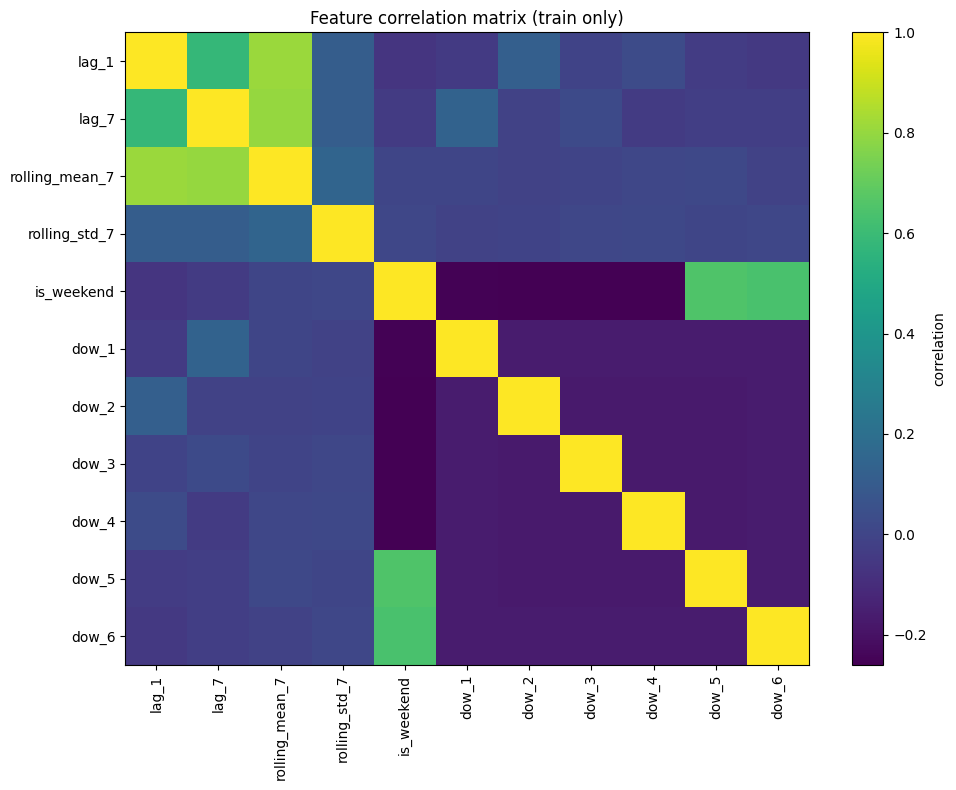

In [62]:
# аeature-feature correlation matrix on train only

feature_corr = X_train.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(feature_corr, aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(feature_corr.columns)), feature_corr.columns, rotation=90)
plt.yticks(range(len(feature_corr.index)), feature_corr.index)
plt.title("Feature correlation matrix (train only)")
plt.tight_layout()
plt.show()

In [63]:
# top feature-feature correlations (absolute)

corr_abs = feature_corr.abs().copy()
np.fill_diagonal(corr_abs.values, np.nan)

pairs = (
    corr_abs.stack()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
)

# remove duplicate mirrored pairs
pairs["pair_key"] = pairs.apply(lambda r: tuple(sorted([r["feature_1"], r["feature_2"]])), axis=1)
pairs = pairs.drop_duplicates(subset="pair_key").drop(columns="pair_key")

print("Top correlated feature pairs:")
print(pairs.head(15))

Top correlated feature pairs:
         feature_1       feature_2  abs_corr
0            lag_1  rolling_mean_7  0.811680
2   rolling_mean_7           lag_7  0.801310
4       is_weekend           dow_5  0.652047
6            dow_6      is_weekend  0.639284
8            lag_1           lag_7  0.578481
10           dow_4      is_weekend  0.259938
12           dow_2      is_weekend  0.259938
14           dow_3      is_weekend  0.259938
16           dow_1      is_weekend  0.254850
18           dow_2           dow_5  0.169492
19           dow_4           dow_2  0.169492
22           dow_5           dow_4  0.169492
23           dow_5           dow_3  0.169492
26           dow_4           dow_3  0.169492
27           dow_3           dow_2  0.169492


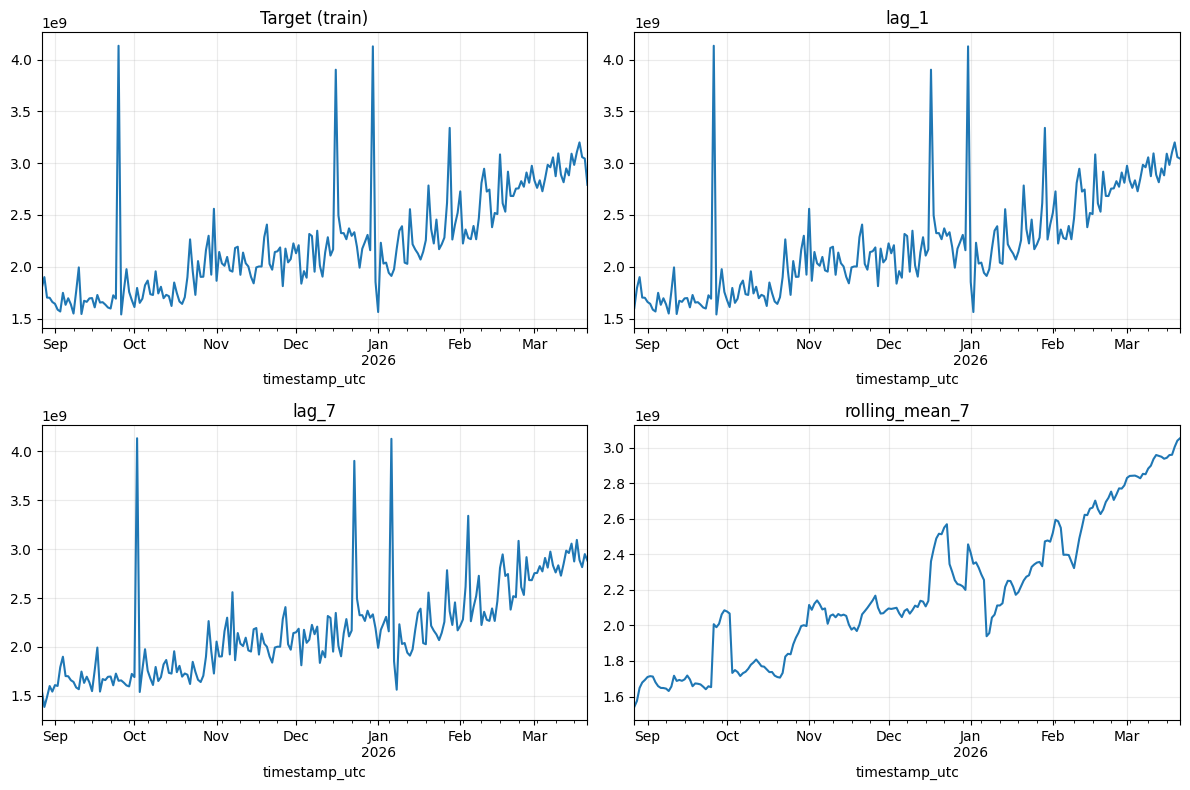

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

train_ml["y"].plot(ax=axes[0, 0], title="Target (train)")
train_ml["lag_1"].plot(ax=axes[0, 1], title="lag_1")
train_ml["lag_7"].plot(ax=axes[1, 0], title="lag_7")
train_ml["rolling_mean_7"].plot(ax=axes[1, 1], title="rolling_mean_7")

for ax in axes.ravel():
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

The feature EDA is evaluated on the training split only. This is intentional: once the problem has been framed as supervised forecasting, correlations with the target are used to guide feature selection, so they should be estimated without looking at the final holdout window.

The strongest predictors are `rolling_mean_7`, `lag_1`, and `lag_7`, which is consistent with the earlier time-series analysis: the daily series shows both short-run persistence and weekly repetition. Some redundancy is expected, since lag and rolling features describe the same recent weekly regime from different angles.

The weekday one-hot variables have weaker marginal correlations with the target, but they may still help by capturing categorical calendar effects. However, `is_weekend` is redundant when weekday dummies are already included, so it is removed from the final ML feature set.

### Ridge model

I start the optional ML section with **Ridge regression** as a simple linear benchmark for the tabular forecasting setup.

This model is appropriate here because:
- the feature set is small and interpretable,
- several lag and rolling predictors are correlated, and Ridge is more stable than ordinary linear regression under such collinearity,
- it provides a transparent contrast to the statistical models and to the non-parametric Random Forest model that may be tested later.

The model is trained on a leakage-safe feature table derived from the same daily target series.  
To evaluate it fairly on the 14-day forecasting task, I use a **recursive multi-step forecast**: each predicted value is fed back into the feature construction for the next forecast step.

In [65]:
train_ml = train_ml.drop('is_weekend', axis=1)

In [66]:
X_train = X_train.drop('is_weekend', axis=1)

In [67]:
train_ml.shape

(207, 11)

In [68]:
# ridge pipeline

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

tscv = TimeSeriesSplit(n_splits=4)

ridge_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train_ml)

print("best alpha:", ridge_search.best_params_)
print("best CV RMSE:", -ridge_search.best_score_)

best_ridge = ridge_search.best_estimator_

best alpha: {'model__alpha': 0.01}
best CV RMSE: 318835181.3389143


### Recursive 14-step forecast

In [69]:
X_train.columns

Index(['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'dow_1', 'dow_2',
       'dow_3', 'dow_4', 'dow_5', 'dow_6'],
      dtype='object')

In [70]:
# feature column order must match training
feature_cols = list(X_train.columns)

# history starts from the whole training target series
history = y_train.copy()

ridge_preds = []

for forecast_date in y_test.index:
    row = {}

    # lag features from available history only
    row["lag_1"] = history.iloc[-1]
    row["lag_7"] = history.iloc[-7]

    # rolling features from available history only
    row["rolling_mean_7"] = history.iloc[-7:].mean()
    row["rolling_std_7"] = history.iloc[-7:].std()

    # weekday one-hot for the forecast date
    dow = forecast_date.dayofweek  # Monday=0 ... Sunday=6
    for k in range(1, 7):          # because drop_first=True, dow_0 is reference
        row[f"dow_{k}"] = int(dow == k)

    X_next = pd.DataFrame([row], index=[forecast_date])[feature_cols]

    y_hat = best_ridge.predict(X_next)[0]
    ridge_preds.append(y_hat)

    # append prediction to history for the next recursive step
    history.loc[forecast_date] = y_hat

ridge_pred = pd.Series(ridge_preds, index=y_test.index, name="ridge_recursive_forecast")
ridge_pred.head()

timestamp_utc
2026-03-22 00:00:00+00:00    3.059380e+09
2026-03-23 00:00:00+00:00    3.023493e+09
2026-03-24 00:00:00+00:00    3.246944e+09
2026-03-25 00:00:00+00:00    3.098374e+09
2026-03-26 00:00:00+00:00    3.126201e+09
Freq: D, Name: ridge_recursive_forecast, dtype: float64

In [71]:
# metrics 

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_smape = smape(y_test, ridge_pred)

print(f"Ridge recursive MAE  = {ridge_mae:,.0f}")
print(f"Ridge recursive RMSE = {ridge_rmse:,.0f}")
print(f"Ridge recursive sMAPE = {ridge_smape:.3f}")

Ridge recursive MAE  = 237,380,194
Ridge recursive RMSE = 297,366,702
Ridge recursive sMAPE = 7.913


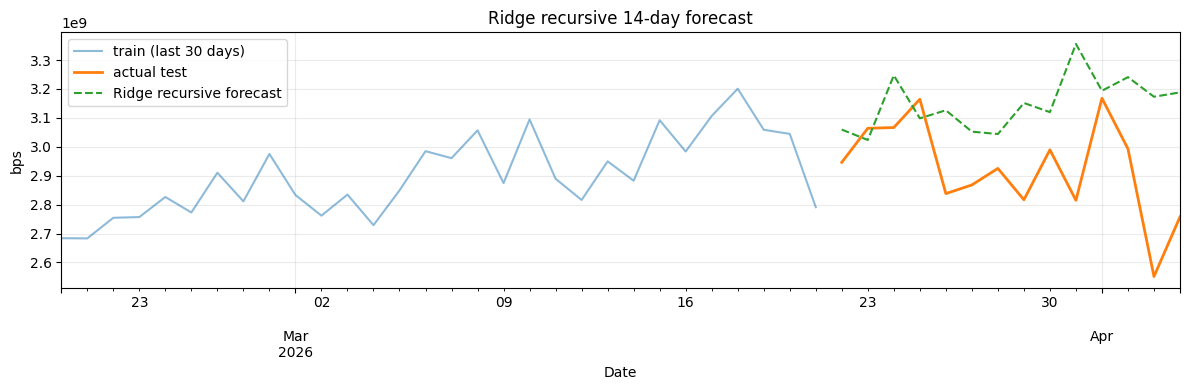

In [72]:
# visual

fig, ax = plt.subplots(figsize=(12, 4))

y_train.iloc[-30:].plot(ax=ax, label="train (last 30 days)", alpha=0.5)
y_test.plot(ax=ax, label="actual test", linewidth=2)
ridge_pred.plot(ax=ax, label="Ridge recursive forecast", linestyle="--")

ax.set_title("Ridge recursive 14-day forecast")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [73]:
ridge_result_row = pd.DataFrame([{
    "spec": "Ridge (recursive)",
    "family": "ML",
    "MAE": ridge_mae,
    "RMSE": ridge_rmse,
    "sMAPE": ridge_smape,
    "AIC": np.nan,
    "BIC": np.nan
}])

comparison_with_ridge = pd.concat(
    [comparison, ridge_result_row],
    ignore_index=True,
    sort=False
).sort_values(["RMSE", "MAE"], na_position="last")

comparison_with_ridge

,spec,family,MAE,RMSE,sMAPE,AIC,BIC
1,Seasonal-Naive (t-7),Baseline,1.379894e+08,1.617793e+08,4.756114,NaN,NaN
7,"SARIMA(0, 1, 2)(1, 0, 0, 7)",SARIMA,1.319853e+08,1.670979e+08,4.533908,8660.145261,8673.456765
8,"SARIMA(0, 1, 2)(0, 0, 1, 7)",SARIMA,1.327815e+08,1.676765e+08,4.560664,8536.391077,8549.643901
9,"SARIMA(0, 1, 1)(1, 0, 0, 7)",SARIMA,1.325833e+08,1.678514e+08,4.554001,8658.778896,8668.762524
10,"SARIMA(0, 1, 1)(0, 0, 1, 7)",SARIMA,1.330416e+08,1.680111e+08,4.569400,8576.062923,8586.017283
11,"SARIMA(0, 1, 1)(1, 0, 1, 7)",SARIMA,1.325982e+08,1.684900e+08,4.554471,8577.281743,8590.554223
2,"ARIMA(0, 1, 2)",ARIMA,1.338398e+08,1.695095e+08,4.596161,8958.481659,8968.565535
3,"ARIMA(1, 1, 1)",ARIMA,1.339233e+08,1.695902e+08,4.598965,8958.922593,8969.006469
5,"ARIMA(0, 1, 1)",ARIMA,1.347417e+08,1.706045e+08,4.626407,8957.062327,8963.784911
4,"ARIMA(2, 1, 1)",ARIMA,1.340642e+08,1.709163e+08,4.603663,8960.456830,8973.901998


In [74]:
ridge_model = best_ridge.named_steps["model"]

coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coef": ridge_model.coef_
}).sort_values("coef", key=np.abs, ascending=False)

coef_table

,feature,coef
2,rolling_mean_7,3.470868e+08
3,rolling_std_7,-1.123417e+08
4,dow_1,7.589180e+07
6,dow_3,3.304617e+07
0,lag_1,3.274961e+07
9,dow_6,1.724959e+07
5,dow_2,1.685779e+07
1,lag_7,4.482089e+06
7,dow_4,4.047896e+06
8,dow_5,3.345157e+06


Ridge regression was tested as a simple linear ML benchmark on a leakage-safe tabular representation of the daily series.  
However, its recursive 14-step forecast performed worse than all previously tested baselines and statistical models.

This suggests that the chosen feature set mainly helps the model recover a smoothed local level, but not the sharper deviations present in the holdout window. In particular, the coefficient pattern is dominated by `rolling_mean_7`, while the recursive setup likely amplifies forecast smoothing and error accumulation across the 14-day horizon.

The recursive setup amplifies this effect: as predicted values replace 
true lags at each step, the rolling_mean_7 feature increasingly reflects 
smoothed predictions rather than real observations, collapsing the 
forecast toward a flat level by day 7+.

Therefore, in this task, a simple linear tabular model does not provide an advantage over the much stronger weekly benchmark.

### Random Forest model

This model is useful here because:
- it can capture **nonlinear relationships** between lag, rolling, and calendar features,
- it does not require feature scaling,
- and it provides a natural contrast to the linear Ridge model.

The evaluation setup remains the same: the model is trained on the training split only, and the 14-day forecast is produced **recursively**, so each predicted value is fed back into the feature construction for the next step.

In [75]:
train_ml = train_ml.drop(columns=["is_weekend"], errors="ignore")
test_ml = test_ml.drop(columns=["is_weekend"], errors="ignore")

In [76]:
X_train = train_ml.drop(columns="y")
y_train = train_ml["y"]

X_test = test_ml.drop(columns="y")
y_test = test_ml["y"]

feature_cols = list(X_train.columns)
feature_cols

['lag_1',
 'lag_7',
 'rolling_mean_7',
 'rolling_std_7',
 'dow_1',
 'dow_2',
 'dow_3',
 'dow_4',
 'dow_5',
 'dow_6']

In [77]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 3, 5]
}

tscv = TimeSeriesSplit(n_splits=4)

rf_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)

best_rf = rf_search.best_estimator_

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV RMSE: 317620121.76976126


### Recusrive 14-days forecast

In [78]:
history = y_train.copy()
rf_preds = []

for forecast_date in y_test.index:
    row = {}

    row["lag_1"] = history.iloc[-1]
    row["lag_7"] = history.iloc[-7]
    row["rolling_mean_7"] = history.iloc[-7:].mean()
    row["rolling_std_7"] = history.iloc[-7:].std()

    dow = forecast_date.dayofweek
    for k in range(1, 7):   # Monday=0 is the reference category
        row[f"dow_{k}"] = int(dow == k)

    X_next = pd.DataFrame([row], index=[forecast_date])[feature_cols]

    y_hat = best_rf.predict(X_next)[0]
    rf_preds.append(y_hat)

    history.loc[forecast_date] = y_hat

rf_pred = pd.Series(rf_preds, index=y_test.index, name="rf_recursive_forecast")
rf_pred

timestamp_utc
2026-03-22 00:00:00+00:00    3.016189e+09
2026-03-23 00:00:00+00:00    3.005502e+09
2026-03-24 00:00:00+00:00    3.037814e+09
2026-03-25 00:00:00+00:00    3.075511e+09
2026-03-26 00:00:00+00:00    2.955326e+09
2026-03-27 00:00:00+00:00    2.964829e+09
2026-03-28 00:00:00+00:00    2.876915e+09
2026-03-29 00:00:00+00:00    2.921608e+09
2026-03-30 00:00:00+00:00    2.890406e+09
2026-03-31 00:00:00+00:00    2.920080e+09
2026-04-01 00:00:00+00:00    2.917366e+09
2026-04-02 00:00:00+00:00    2.888928e+09
2026-04-03 00:00:00+00:00    2.908417e+09
2026-04-04 00:00:00+00:00    2.865651e+09
Freq: D, Name: rf_recursive_forecast, dtype: float64

In [79]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_smape = smape(y_test, rf_pred)

print(f"RF recursive MAE   = {rf_mae:,.0f}")
print(f"RF recursive RMSE  = {rf_rmse:,.0f}")
print(f"RF recursive sMAPE = {rf_smape:.3f}")

RF recursive MAE   = 116,949,889
RF recursive RMSE  = 143,219,278
RF recursive sMAPE = 4.035


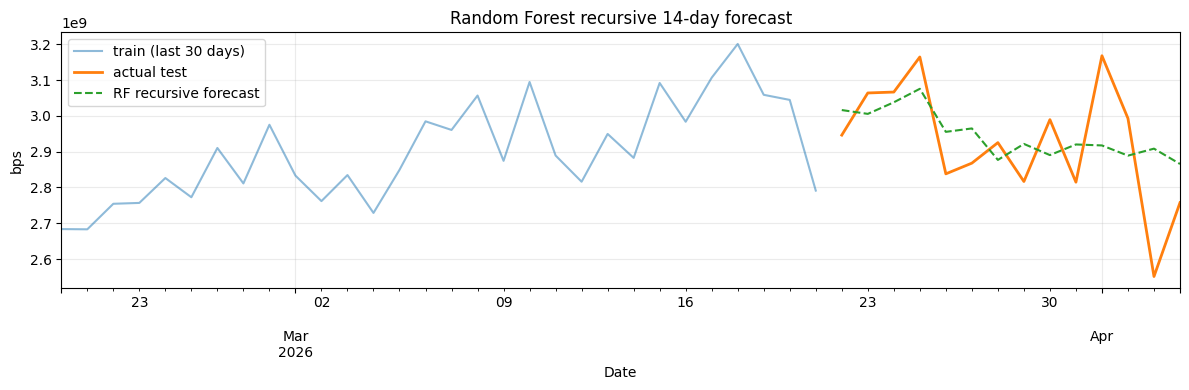

In [80]:
fig, ax = plt.subplots(figsize=(12, 4))

y_train.iloc[-30:].plot(ax=ax, label="train (last 30 days)", alpha=0.5)
y_test.plot(ax=ax, label="actual test", linewidth=2)
rf_pred.plot(ax=ax, label="RF recursive forecast", linestyle="--")

ax.set_title("Random Forest recursive 14-day forecast")
ax.set_xlabel("Date")
ax.set_ylabel("bps")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [81]:
# feature importance
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance

,feature,importance
1,lag_7,0.353467
2,rolling_mean_7,0.264151
0,lag_1,0.226315
3,rolling_std_7,0.118004
6,dow_3,0.017901
4,dow_1,0.009925
5,dow_2,0.004383
7,dow_4,0.002829
9,dow_6,0.001552
8,dow_5,0.001474


In [82]:
rf_result_row = pd.DataFrame([{
    "spec": "Random Forest (recursive)",
    "family": "ML",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "sMAPE": rf_smape,
    "AIC": np.nan,
    "BIC": np.nan
}])

comparison_with_ml = pd.concat(
    [comparison_with_ridge, rf_result_row],
    ignore_index=True,
    sort=False
).sort_values(["RMSE", "MAE"], na_position="last")

comparison_with_ml

,spec,family,MAE,RMSE,sMAPE,AIC,BIC
13,Random Forest (recursive),ML,1.169499e+08,1.432193e+08,4.034778,NaN,NaN
0,Seasonal-Naive (t-7),Baseline,1.379894e+08,1.617793e+08,4.756114,NaN,NaN
1,"SARIMA(0, 1, 2)(1, 0, 0, 7)",SARIMA,1.319853e+08,1.670979e+08,4.533908,8660.145261,8673.456765
2,"SARIMA(0, 1, 2)(0, 0, 1, 7)",SARIMA,1.327815e+08,1.676765e+08,4.560664,8536.391077,8549.643901
3,"SARIMA(0, 1, 1)(1, 0, 0, 7)",SARIMA,1.325833e+08,1.678514e+08,4.554001,8658.778896,8668.762524
4,"SARIMA(0, 1, 1)(0, 0, 1, 7)",SARIMA,1.330416e+08,1.680111e+08,4.569400,8576.062923,8586.017283
5,"SARIMA(0, 1, 1)(1, 0, 1, 7)",SARIMA,1.325982e+08,1.684900e+08,4.554471,8577.281743,8590.554223
6,"ARIMA(0, 1, 2)",ARIMA,1.338398e+08,1.695095e+08,4.596161,8958.481659,8968.565535
7,"ARIMA(1, 1, 1)",ARIMA,1.339233e+08,1.695902e+08,4.598965,8958.922593,8969.006469
8,"ARIMA(0, 1, 1)",ARIMA,1.347417e+08,1.706045e+08,4.626407,8957.062327,8963.784911


The recursive **Random Forest** model is the strongest performer among all tested models on the 14-day holdout window.

It outperforms the weekly **Seasonal-Naive** baseline as well as the tested ARIMA and SARIMA specifications on all reported forecast metrics:
- lower **MAE**
- lower **RMSE**
- lower **sMAPE**

The feature importance pattern is also interpretable: the model relies primarily on `lag_7`, `rolling_mean_7`, `lag_1`, and `rolling_std_7`. This is consistent with the earlier time-series analysis, which suggested that the series is driven by weekly repetition, recent local level, and short-run persistence.

Unlike Ridge regression, which mainly produced an overly smoothed recursive forecast, the Random Forest is able to capture more flexible nonlinear relationships among lag, rolling, and calendar features.

Therefore, within the current evaluation setup, **Random Forest (recursive)** is selected as the overall champion model.

## <a id="9-final-model-selection"></a>9) Final model selection


The final holdout window suggested that **Random Forest (recursive)** may outperform both the **Seasonal-Naive** baseline and the best statistical model, **SARIMA(0,1,2)(1,0,0,7)**.

However, one strong test window is not enough to justify a shipment decision.  
To choose the most credible final model for this target and forecast horizon, I run a **rolling-origin backtest**.

I compare three finalists:

- **Seasonal-Naive (t-7)** as the strongest simple baseline
- **SARIMA(0,1,2)(1,0,0,7)** as the strongest statistical model
- **Random Forest (recursive)** as the strongest ML model on the final holdout

The goal is not only to compare average performance, but also to evaluate:
- **stability across forecast origins**
- **how often each model wins**
- **worst-case behavior**

This gives a more defensible basis for answering the final capstone question:  
**Which model would I ship for this forecasting task?**

Note. The rolling-origin backtest is run on the same final target series and the same forecast windows for all models. The ML pipeline internally loses the first 7 observations because lag and rolling features require a short warm-up period, while the statistical models can use the full series up to each forecast origin.

This creates a small asymmetry in effective training length, but it does not affect the fairness of the forecast comparison itself: all models are evaluated on the same future dates, using only information available before each origin. Given the total sample size and the late forecast origins used in the backtest, this difference is considered acceptable.

In [83]:
# series

y = daily_target["y_final"].copy()

H = 14
N_WINDOWS = 4

In [84]:
# build RF training table from a single target series

def build_rf_table(y_series: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame(index=y_series.index)
    df["y"] = y_series

    df["lag_1"] = y_series.shift(1)
    df["lag_7"] = y_series.shift(7)
    df["rolling_mean_7"] = y_series.shift(1).rolling(7).mean()
    df["rolling_std_7"] = y_series.shift(1).rolling(7).std()

    dow = df.index.dayofweek
    dow_dummies = pd.get_dummies(dow, prefix="dow", drop_first=True, dtype=int)
    dow_dummies.index = df.index

    df = pd.concat([df, dow_dummies], axis=1)
    return df.dropna().copy()


# recursive RF forecast

def recursive_rf_forecast(train_series: pd.Series,
                          forecast_index: pd.Index,
                          fitted_rf,
                          feature_cols: list[str]) -> pd.Series:
    history = train_series.copy()
    preds = []

    for forecast_date in forecast_index:
        row = {
            "lag_1": history.iloc[-1],
            "lag_7": history.iloc[-7],
            "rolling_mean_7": history.iloc[-7:].mean(),
            "rolling_std_7": history.iloc[-7:].std(),
        }

        dow = forecast_date.dayofweek
        for k in range(1, 7):   # Monday=0 is the dropped reference
            row[f"dow_{k}"] = int(dow == k)

        X_next = pd.DataFrame([row], index=[forecast_date])[feature_cols]
        y_hat = fitted_rf.predict(X_next)[0]

        preds.append(y_hat)
        history.loc[forecast_date] = y_hat

    return pd.Series(preds, index=forecast_index, name="rf_pred")


# seasonal naive forecast (m = 7)
# honest multi-step version: repeat the last 7 observed values

def seasonal_naive_forecast(train_series: pd.Series,
                            forecast_index: pd.Index,
                            seasonal_lag: int = 7) -> pd.Series:
    last_season = train_series.iloc[-seasonal_lag:].to_numpy()
    reps = int(np.ceil(len(forecast_index) / seasonal_lag))
    forecast_values = np.tile(last_season, reps)[:len(forecast_index)]
    return pd.Series(forecast_values, index=forecast_index, name="seasonal_naive_pred")


# SARIMA forecast

def sarima_forecast(train_series: pd.Series,
                    forecast_index: pd.Index,
                    order=(0, 1, 2),
                    seasonal_order=(1, 0, 0, 7)) -> pd.Series:
    fit = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    fc = fit.get_forecast(steps=len(forecast_index))
    pred = fc.predicted_mean
    pred.index = forecast_index
    pred.name = "sarima_pred"
    return pred

In [87]:
# rolling-origin backtest loop

rows = []
all_preds = []

# window starts for the last N_WINDOWS non-overlapping 14-day windows
test_starts = [len(y) - H * i for i in range(N_WINDOWS, 0, -1)]
# Example for len=228, H=14, N_WINDOWS=4 -> [172, 186, 200, 214]

for w, test_start in enumerate(test_starts, start=1):
    test_end = test_start + H

    y_train_w = y.iloc[:test_start].copy()
    y_test_w  = y.iloc[test_start:test_end].copy()

    origin_label = f"window_{w}"
    origin_end = y_train_w.index[-1]
    test_start_date = y_test_w.index[0]
    test_end_date = y_test_w.index[-1]

    # ----- RF -----
    rf_train_df = build_rf_table(y_train_w)
    X_train_w = rf_train_df.drop(columns="y")
    y_train_rf_w = rf_train_df["y"]
    feature_cols = list(X_train_w.columns)

    rf_model_w = clone(best_rf)
    rf_model_w.fit(X_train_w, y_train_rf_w)

    rf_pred_w = recursive_rf_forecast(
        train_series=y_train_w,
        forecast_index=y_test_w.index,
        fitted_rf=rf_model_w,
        feature_cols=feature_cols
    )

    # ----- Seasonal-Naive -----
    sn_pred_w = seasonal_naive_forecast(
        train_series=y_train_w,
        forecast_index=y_test_w.index,
        seasonal_lag=7
    )

    # ----- SARIMA -----
    sarima_pred_w = sarima_forecast(
        train_series=y_train_w,
        forecast_index=y_test_w.index,
        order=(0, 1, 2),
        seasonal_order=(1, 0, 0, 7)
    )

    # ----- collect metrics -----
    model_preds = {
        "Random Forest (recursive)": rf_pred_w,
        "Seasonal-Naive (t-7)": sn_pred_w,
        "SARIMA(0,1,2)(1,0,0,7)": sarima_pred_w,
    }

    for model_name, pred in model_preds.items():
        rows.append({
            "window": origin_label,
            "train_end": origin_end,
            "test_start": test_start_date,
            "test_end": test_end_date,
            "model": model_name,
            "MAE": mean_absolute_error(y_test_w, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test_w, pred)),
            "sMAPE": smape(y_test_w, pred),
        })

        pred_df = pd.DataFrame({
            "window": origin_label,
            "date": y_test_w.index,
            "actual": y_test_w.values,
            "pred": pred.values,
            "model": model_name,
        })
        all_preds.append(pred_df)

rolling_results = pd.DataFrame(rows)
rolling_preds = pd.concat(all_preds, ignore_index=True)

rolling_results

,window,train_end,test_start,test_end,model,MAE,RMSE,sMAPE
0,window_1,2026-02-07 00:00:00+00:00,2026-02-08 00:00:00+00:00,2026-02-21 00:00:00+00:00,Random Forest (recursive),2.945422e+08,3.706977e+08,11.426553
1,window_1,2026-02-07 00:00:00+00:00,2026-02-08 00:00:00+00:00,2026-02-21 00:00:00+00:00,Seasonal-Naive (t-7),3.977377e+08,4.509712e+08,15.598066
2,window_1,2026-02-07 00:00:00+00:00,2026-02-08 00:00:00+00:00,2026-02-21 00:00:00+00:00,"SARIMA(0,1,2)(1,0,0,7)",3.240514e+08,3.794336e+08,12.559180
3,window_2,2026-02-21 00:00:00+00:00,2026-02-22 00:00:00+00:00,2026-03-07 00:00:00+00:00,Random Forest (recursive),1.258571e+08,1.506536e+08,4.353155
4,window_2,2026-02-21 00:00:00+00:00,2026-02-22 00:00:00+00:00,2026-03-07 00:00:00+00:00,Seasonal-Naive (t-7),2.263958e+08,2.453850e+08,8.172749
5,window_2,2026-02-21 00:00:00+00:00,2026-02-22 00:00:00+00:00,2026-03-07 00:00:00+00:00,"SARIMA(0,1,2)(1,0,0,7)",2.112216e+08,2.272023e+08,7.681080
6,window_3,2026-03-07 00:00:00+00:00,2026-03-08 00:00:00+00:00,2026-03-21 00:00:00+00:00,Random Forest (recursive),1.505012e+08,1.748949e+08,5.088289
7,window_3,2026-03-07 00:00:00+00:00,2026-03-08 00:00:00+00:00,2026-03-21 00:00:00+00:00,Seasonal-Naive (t-7),1.832625e+08,2.160128e+08,6.255309
8,window_3,2026-03-07 00:00:00+00:00,2026-03-08 00:00:00+00:00,2026-03-21 00:00:00+00:00,"SARIMA(0,1,2)(1,0,0,7)",1.709893e+08,2.039178e+08,5.809363
9,window_4,2026-03-21 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-04-04 00:00:00+00:00,Random Forest (recursive),1.169499e+08,1.432193e+08,4.034778


In [88]:
# avg / median / worst-case performance
summary_stats = (
    rolling_results
    .groupby("model")[["MAE", "RMSE", "sMAPE"]]
    .agg(["mean", "median", "max", "std"])
    .round(3)
)

print("Summary statistics across rolling windows:")
display(summary_stats)

# which model wins each window by RMSE?
wins_by_window = (
    rolling_results.loc[rolling_results.groupby("window")["RMSE"].idxmin(), ["window", "model", "RMSE"]]
    .sort_values("window")
)

print("\nRMSE winner in each window:")
display(wins_by_window)

win_counts = wins_by_window["model"].value_counts()
print("\nWin counts by RMSE:")
display(win_counts)

Summary statistics across rolling windows:


MAE                              \
                                   mean        median           max   
model                                                                 
Random Forest (recursive)  1.719626e+08  1.381791e+08  2.945422e+08   
SARIMA(0,1,2)(1,0,0,7)     2.095619e+08  1.911055e+08  3.240514e+08   
Seasonal-Naive (t-7)       2.381384e+08  2.048291e+08  3.977377e+08   

                                                 RMSE                \
                                    std          mean        median   
model                                                                 
Random Forest (recursive)  8.294271e+07  2.098664e+08  1.627743e+08   
SARIMA(0,1,2)(1,0,0,7)     8.289870e+07  2.444129e+08  2.155601e+08   
Seasonal-Naive (t-7)       1.114550e+08  2.771522e+08  2.306989e+08   

                                                       sMAPE                 \
                                    max           std   mean median     max   
model                                                                         
Random Forest (recursive)  3.706977e+08  1.080705e+08  6.226  4.721  11.427   
SARIMA(0,1,2)(1,0,0,7)     3.794336e+08  9.335284e+07  7.646  6.745  12.559   
Seasonal-Naive (t-7)       4.509712e+08  1.176252e+08  8.747  7.214  15.598   

                                  
                             std  
model                             
Random Forest (recursive)  3.495  
SARIMA(0,1,2)(1,0,0,7)     3.521  
Seasonal-Naive (t-7)       4.754


RMSE winner in each window:


,window,model,RMSE
0,window_1,Random Forest (recursive),3.706977e+08
3,window_2,Random Forest (recursive),1.506536e+08
6,window_3,Random Forest (recursive),1.748949e+08
9,window_4,Random Forest (recursive),1.432193e+08



Win counts by RMSE:


model
Random Forest (recursive)    4
Name: count, dtype: int64

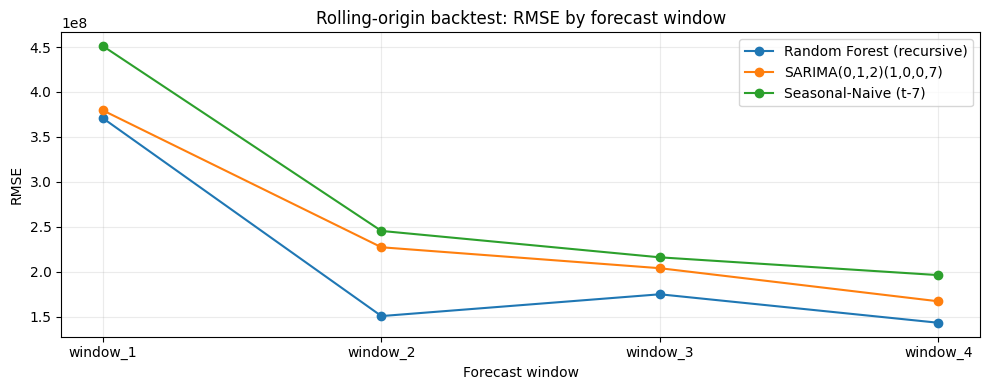

In [89]:
# rmse chart by window
fig, ax = plt.subplots(figsize=(10, 4))

for model_name, g in rolling_results.groupby("model"):
    g = g.sort_values("window")
    ax.plot(g["window"], g["RMSE"], marker="o", label=model_name)

ax.set_title("Rolling-origin backtest: RMSE by forecast window")
ax.set_xlabel("Forecast window")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

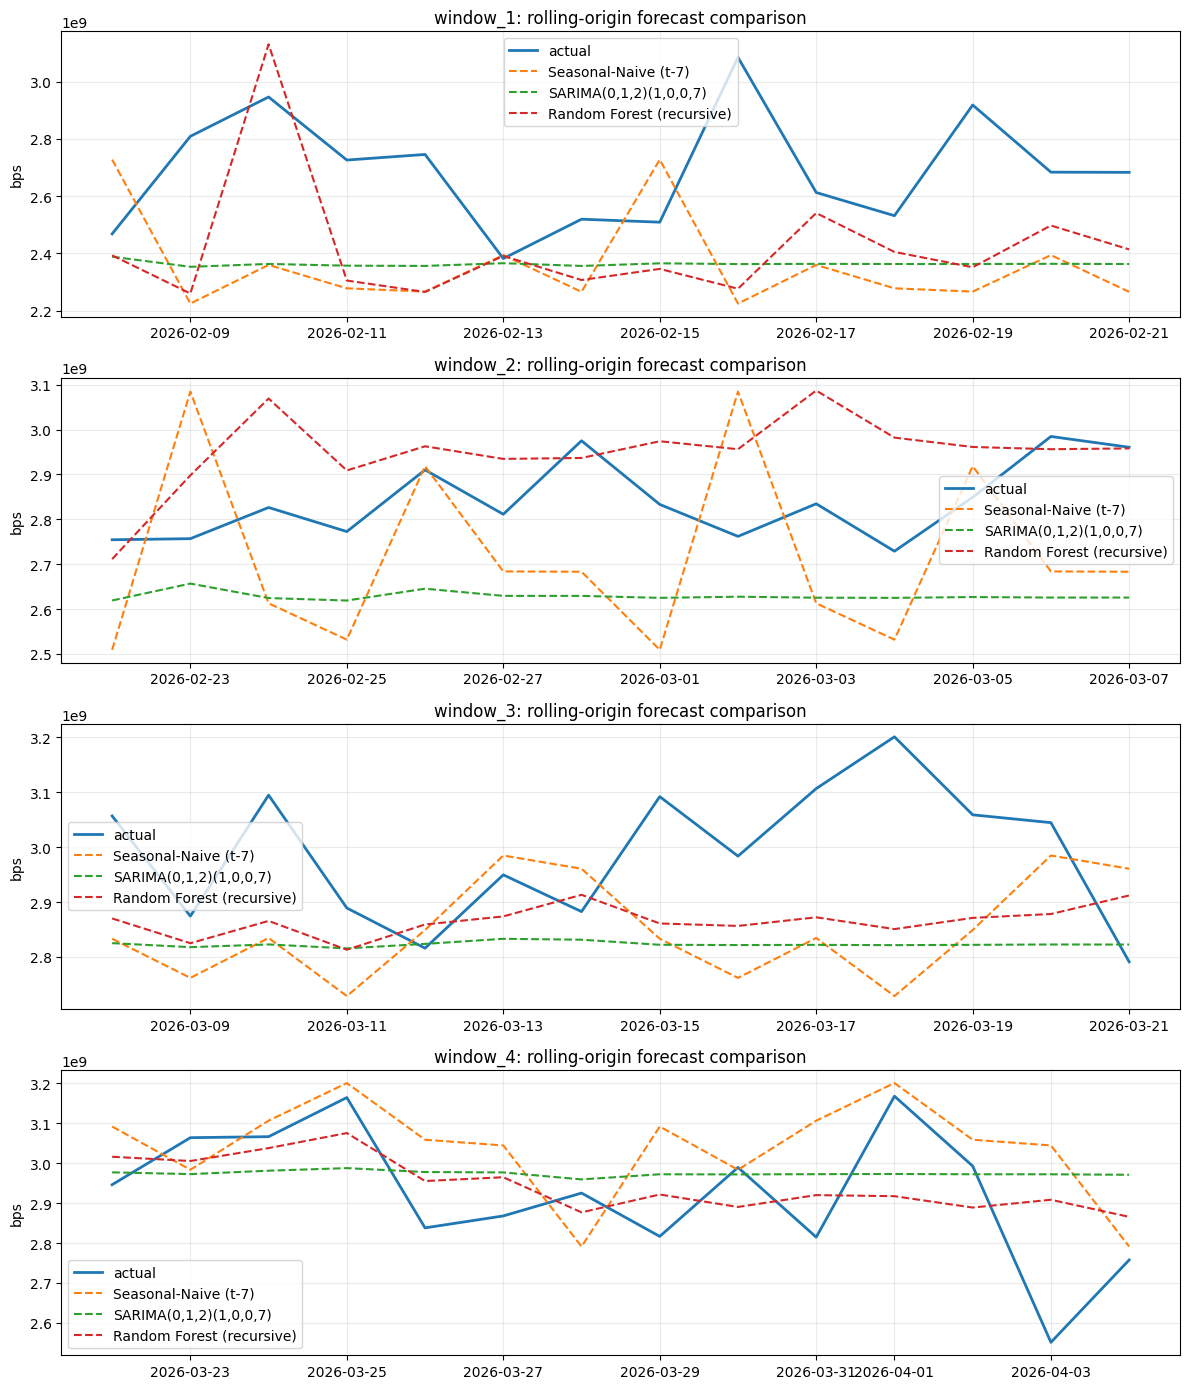

In [90]:
# forecast visual by window
windows = rolling_preds["window"].unique()

fig, axes = plt.subplots(len(windows), 1, figsize=(12, 3.5 * len(windows)), sharex=False)

if len(windows) == 1:
    axes = [axes]

for ax, w in zip(axes, windows):
    subset = rolling_preds[rolling_preds["window"] == w].copy()

    # actual
    actual = subset[subset["model"] == "Random Forest (recursive)"][["date", "actual"]]
    ax.plot(actual["date"], actual["actual"], label="actual", linewidth=2)

    # predictions
    for model_name in ["Seasonal-Naive (t-7)", "SARIMA(0,1,2)(1,0,0,7)", "Random Forest (recursive)"]:
        pred_sub = subset[subset["model"] == model_name]
        ax.plot(pred_sub["date"], pred_sub["pred"], linestyle="--", label=model_name)

    ax.set_title(f"{w}: rolling-origin forecast comparison")
    ax.set_ylabel("bps")
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

### Rolling-origin backtest summary

The rolling-origin backtest confirms that the final-holdout result was not a one-off accident.

Across **4 forecast windows** of **14 days** each, the **recursive Random Forest** is the strongest model on the primary metric (**RMSE**):
- it wins **4/4 windows** by RMSE,
- it has the best **mean RMSE**,
- the best **median RMSE**,
- and the best **worst-case RMSE** among the three finalists.

The ranking is consistent across all reported metrics:
1. **Random Forest (recursive)**
2. **SARIMA(0,1,2)(1,0,0,7)**
3. **Seasonal-Naive (t-7)**

This matters because the final comparison is no longer based on a single 14-day holdout alone.  
Instead, the rolling-origin backtest shows that the Random Forest advantage remains visible across multiple forecast origins, which increases confidence that its improvement is **systematic rather than accidental**.

At the same time, the comparison also reveals a useful pattern:
- **Seasonal-Naive** remains a strong and very competitive baseline,
- **SARIMA** is more stable than the baseline on average but does not match the Random Forest,
- and **Random Forest** combines the best average performance with the strongest window-by-window consistency.

Overall, this backtest strengthens the case that the Random Forest is not just the best model on the final holdout, but also the most robust candidate among the tested approaches for this target and this forecast horizon.

## <a id="10-interpretation-decision"></a> 10) Interpretation & decision


**Summarize your findings in 6–10 sentences:**
- Which model would you ship (and why)?  
- How does it compare to **seasonal-naïve**?  
- Where does it underperform (e.g., peaks/valleys, regime shifts)?  
- What risks/assumptions should stakeholders know?  
- What would you try next (data, features, modeling)?  

## Interpretation & decision

### Which model would I ship (and why)?
Within this capstone, I would ship the **recursive Random Forest** as the leading model for this forecasting task.

It is the strongest model tested on the final 14-day holdout window and remains the strongest candidate under the rolling-origin backtest. It outperforms both the strongest simple baseline (**Seasonal-Naive (t-7)**) and the strongest statistical model (**SARIMA(0,1,2)(1,0,0,7)**) consistently across multiple forecast origins. This makes its advantage more credible and less likely to be an artifact of one favorable split.

I would deploy it as a **directional planning tool**, not as a precision instrument for daily spike-by-spike forecasting.

### How does it compare to seasonal-naïve?
The **Seasonal-Naive (t-7)** baseline is strong and remains an important reference model. It captures the weekly repetition in the series and performs surprisingly well for such a simple benchmark.

However, the recursive Random Forest improves on Seasonal-Naive across all reported metrics on the final holdout:
- lower **MAE**
- lower **RMSE**
- lower **sMAPE**

The rolling-origin backtest confirms the same pattern: Random Forest wins all tested windows by RMSE and has the best average and worst-case performance among the finalist models. This suggests that the gain over Seasonal-Naive is not only statistical, but also operationally relevant within this task setup.

### Where does it underperform?
The model still struggles in the same places where all tested approaches struggle:
- abrupt peaks and valleys,
- short-lived traffic bursts,
- and sharp local regime changes.

Its recursive structure also means that forecast errors can propagate across the 14-day horizon. As a result, the model is more reliable for capturing the **general near-term level and direction** of network pressure than for predicting the exact magnitude of sudden daily extremes.

### What risks and assumptions should stakeholders know?
Stakeholders should be aware of several limitations:

- The dataset is relatively short, so the model has been validated only on a limited historical span.
- The target is a **daily 95th percentile** of hourly traffic, which is useful for summarizing upper-tail pressure, but still compresses the underlying hourly dynamics.
- No external regressors were used in the final ML pipeline, so the model cannot account for business events, maintenance actions, migrations, or other operational drivers.
- Forecast quality is strongest as a short-term planning signal; it should not be interpreted as exact daily truth.
- The model should be monitored and retrained regularly as traffic regimes evolve.

### What would I try next?
The next improvements would focus on three directions:

1. **Data**
   - extend the historical window,
   - include more seasonal regimes,
   - and, if possible, add operational context such as maintenance flags or workload changes.

2. **Features**
   - test a small number of additional leakage-safe features,
   - such as longer weekly-memory terms or deviation features,
   - while preserving interpretability.

3. **Modeling**
   - compare the Random Forest against additional robust tabular models,
   - test the same task on hourly data,
   - and evaluate whether the forecast can be reframed into threshold-based capacity-risk signals rather than only point forecasts.

### Final recommendation
For this capstone, the **recursive Random Forest** is the most defensible model to recommend.  
It is not perfect, but it is the strongest model tested for this target, this horizon, and this dataset, and it shows more stable evidence of usefulness than the baselines and statistical alternatives.

In [91]:
forecast_export = pd.DataFrame({
    "date": rf_pred.index,
    "forecast_bps": rf_pred.values
})

# CSV export
# forecast_export.to_csv("forecast_random_forest_next_14.csv", index=False)

## 10) Final deliverables checklist

- [✓] This notebook renamed to `time_series_name_surname.ipynb`.  
- [✓] One clear **forecast plot** for the test window (with intervals if using SARIMA).  
- [✓] A small **metrics table** (MAE, RMSE, sMAPE) comparing your champion vs baselines.  
- [✓] (Optional) A CSV export of the final forecast (commented-out code provided).  
- [✓] Short narrative explaining the result and next steps.
